In [2]:
import pandas as pd

# 1. 设置文件路径 (注意：Windows路径若包含中文，建议确保编码正确)
file_path = 'C:/Users/32052/Desktop/小组/台湾空气质量/air_quality.csv'

# 2. 读取数据
print("正在读取文件...")
try:
    # 尝试默认 utf-8 编码读取
    df = pd.read_csv(file_path)
except UnicodeDecodeError:
    print("UTF-8读取失败，尝试使用 big5 编码（台湾数据常用）...")
    # 如果报错，尝试 big5 编码
    df = pd.read_csv(file_path, encoding='big5')

# 3. 基础描述性分析
print("-" * 30)
print("【数据基础信息】")
print(f"总行数: {df.shape[0]}")
print(f"总列数: {df.shape[1]}")

# 4. 查看 county 列的分布情况
print("-" * 30)
print("【各城市 (county) 数据量统计】")
# value_counts() 会自动按数量从大到小排序
county_counts = df['county'].value_counts()
print(county_counts)

# 5. 检查是否有缺失值
missing_counties = df['county'].isnull().sum()
if missing_counties > 0:
    print("-" * 30)
    print(f"注意：county 列中有 {missing_counties} 个缺失值 (NaN)")
else:
    print("-" * 30)
    print("county 列无缺失值。")

# 6. 预览前几行数据
print("-" * 30)
print("【数据前5行预览】")
print(df.head())

正在读取文件...


C:\Users\32052\AppData\Local\Temp\ipykernel_31204\1296626189.py:10: DtypeWarning: Columns (6,7,8,9,10,11,12,13,14,15,16,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


------------------------------
【数据基础信息】
总行数: 5882208
总列数: 25
------------------------------
【各城市 (county) 数据量统计】
county
New Taipei City      898819
Kaohsiung City       888497
Taipei City          503766
Taoyuan City         448718
Taichung City        367033
Tainan City          366827
Pingtung County      305495
Changhua County      293423
Yunlin County        287491
Miaoli County        219683
Nantou County        216420
Yilan County         147071
Chiayi County        143986
Hsinchu County       143846
Taitung County       143809
Hsinchu City          75850
Lienchiang County     71914
Keelung City          71913
Kinmen County         71913
Chiayi City           71912
Hualien County        71912
Penghu County         71910
Name: count, dtype: int64
------------------------------
county 列无缺失值。
------------------------------
【数据前5行预览】
               date   sitename          county   aqi pollutant    status  so2  \
0  2024-08-31 23:00      Hukou  Hsinchu County  62.0     PM2.5  Moderat

In [3]:
import pandas as pd

# 1. 设置文件路径
input_file_path = 'C:/Users/32052/Desktop/小组/台湾空气质量/air_quality.csv'
# 建议修改输出文件名以区分内容
output_file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_2020_2024.csv'

# 2. 读取数据
print("正在读取数据 (可能需要几秒钟)...")
try:
    # low_memory=False 用于防止混合类型警告，提高大文件读取稳定性
    df = pd.read_csv(input_file_path, low_memory=False)
except UnicodeDecodeError:
    print("UTF-8 读取失败，尝试 Big5 编码...")
    df = pd.read_csv(input_file_path, encoding='big5', low_memory=False)

# 3. 第一步：筛选城市 (Kaohsiung City)
print("正在筛选高雄市数据...")
# 筛选 county 列为 Kaohsiung City 的行
df_city = df[df['county'] == 'Kaohsiung City'].copy()

# 4. 第二步：筛选时间 (2020-2024)
print("正在筛选年份 (2020-2024)...")
# 将 date 列转换为 datetime 格式以便提取年份
# errors='coerce' 表示如果遇到无法解析的日期格式，将其设为 NaT (不报错)
df_city['date'] = pd.to_datetime(df_city['date'], errors='coerce')

# 定义目标年份列表
target_years = [2020, 2021, 2022, 2023, 2024]

# 筛选符合年份的数据
filtered_df = df_city[df_city['date'].dt.year.isin(target_years)]

# 5. 检查筛选结果
print("-" * 30)
print("筛选完成！结果统计：")
print(f"城市: Kaohsiung City")
print(f"年份: {target_years}")
print(f"总数据量: {len(filtered_df)}")

# 简单查看一下每年的数据分布
print("\n各年份数据量分布:")
print(filtered_df['date'].dt.year.value_counts().sort_index())

# 6. 保存为新的 CSV 文件
print("-" * 30)
print("正在保存文件...")
filtered_df.to_csv(output_file_path, index=False, encoding='utf-8-sig')

print(f"文件已成功保存至: {output_file_path}")

正在读取数据 (可能需要几秒钟)...
正在筛选高雄市数据...
正在筛选年份 (2020-2024)...
------------------------------
筛选完成！结果统计：
城市: Kaohsiung City
年份: [2020, 2021, 2022, 2023, 2024]
总数据量: 562158

各年份数据量分布:
date
2020    104160
2021    155586
2022    113875
2023    112564
2024     75973
Name: count, dtype: int64
------------------------------
正在保存文件...
文件已成功保存至: C:/Users/32052/Desktop/小组/kaohsiung_2020_2024.csv


In [5]:
import pandas as pd

# 1. 设置文件路径
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_2020_2024.csv'

# 2. 读取数据
print(f"正在读取文件: {file_path} ...")
try:
    # 之前保存时使用了 utf-8-sig，这里通常可以直接读取
    df = pd.read_csv(file_path)
except UnicodeDecodeError:
    # 如果读取失败，尝试其他编码
    df = pd.read_csv(file_path, encoding='big5')

# 3. 统计各站点数量
print("-" * 30)
print("【各监测站点 (sitename) 数据量统计】")

if 'sitename' in df.columns:
    # value_counts() 会按数据量从多到少排序
    site_counts = df['sitename'].value_counts()
    print(site_counts)
    
    # 打印一些额外信息
    print("-" * 30)
    print(f"共有 {len(site_counts)} 个监测站点")
    print(f"当前文件总数据量: {len(df)}")
else:
    print("错误：列名中未找到 'sitename'，请检查数据文件的列名。")
    # 打印前几行帮助检查列名
    print(df.head())

正在读取文件: C:/Users/32052/Desktop/小组/kaohsiung_2020_2024.csv ...


C:\Users\32052\AppData\Local\Temp\ipykernel_31204\4011947603.py:10: DtypeWarning: Columns (6,7,8,9,10,11,12,13,14,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


------------------------------
【各监测站点 (sitename) 数据量统计】
sitename
Qiaotou                         44843
Meinong                         44838
Renwu                           44838
Xiaogang                        44834
Fuxing                          44830
Daliao                          44826
Linyuan                         44824
Qianzhen                        44823
Zuoying                         44815
Qianjin                         44660
Nanzi                           43765
Fengshan                        40189
Kaohsiung (Hunei)               25680
Kaohsiung (Nanzi)                2013
Kaohsiung (Zuoying)              1330
Kaohsiung (Alian)                 670
Hunei                             220
Nanzi Export Processing Zone      159
Kaohsiung (Linyuan)                 1
Name: count, dtype: int64
------------------------------
共有 19 个监测站点
当前文件总数据量: 562158


In [6]:
import pandas as pd

# 1. 设置路径
# 输入也就是您刚刚生成的那个大文件
input_file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_2020_2024.csv'
# 输出最终的精简文件
output_file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv'

# 2. 读取数据
print("正在读取文件...")
df = pd.read_csv(input_file_path)

# 3. 定义要保留的 5 个黄金站点
target_sites = [
    'Xiaogang',  # 小港 (工业)
    'Linyuan',   # 林园 (石化)
    'Qianjin',   # 前金 (市中心)
    'Zuoying',   # 左营 (都会)
    'Meinong'    # 美浓 (郊区/背景)
]

print(f"目标筛选站点: {target_sites}")

# 4. 执行筛选
df_final = df[df['sitename'].isin(target_sites)]

# 5. 检查结果
print("-" * 30)
print("【最终筛选结果】")
print(df_final['sitename'].value_counts())
total_rows = len(df_final)
print(f"\n最终数据总量: {total_rows}")

# 6. 保存
if total_rows > 0:
    df_final.to_csv(output_file_path, index=False, encoding='utf-8-sig')
    print(f"\n文件已保存至: {output_file_path}")
    print("这个文件现在包含了 2020-2024 年，5个典型站点的数据，非常适合研究！")
else:
    print("筛选结果为空，请检查站点名称是否拼写正确。")

正在读取文件...


C:\Users\32052\AppData\Local\Temp\ipykernel_31204\4142846224.py:11: DtypeWarning: Columns (6,7,8,9,10,11,12,13,14,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file_path)


目标筛选站点: ['Xiaogang', 'Linyuan', 'Qianjin', 'Zuoying', 'Meinong']
------------------------------
【最终筛选结果】
sitename
Meinong     44838
Xiaogang    44834
Linyuan     44824
Zuoying     44815
Qianjin     44660
Name: count, dtype: int64

最终数据总量: 223971

文件已保存至: C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv
这个文件现在包含了 2020-2024 年，5个典型站点的数据，非常适合研究！


***地图制作***

In [10]:
import pandas as pd
import folium

# 1. 读取数据
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv'
print("正在读取数据...")
df = pd.read_csv(file_path)

# 2. 提取站点坐标
# 原始数据有几十万行，我们只需要每个站点的一行数据来获取坐标
# 使用 drop_duplicates 去重，只保留每个站点的一条记录
site_info = df[['sitename', 'latitude', 'longitude']].drop_duplicates(subset=['sitename'])

print("提取到的站点坐标信息：")
print(site_info)

# 3. 创建地图
# 以高雄市的大致中心为地图中心 (纬度 22.6, 经度 120.3)
kaohsiung_map = folium.Map(location=[22.62, 120.30], zoom_start=11)

# 4. 在地图上添加站点标记
for index, row in site_info.iterrows():
    site_name = row['sitename']
    lat = row['latitude']
    lon = row['longitude']
    
    # 添加标记 (Marker)
    folium.Marker(
        location=[lat, lon],
        popup=f"<b>{site_name}</b><br>Lat: {lat}<br>Lon: {lon}", # 点击弹窗内容
        tooltip=site_name, # 鼠标悬停显示名字
        icon=folium.Icon(color='red', icon='info-sign') # 红色图标
    ).add_to(kaohsiung_map)

# 5. 保存地图
output_map_path = 'C:/Users/32052/Desktop/小组/kaohsiung_sites_map.html'
kaohsiung_map.save(output_map_path)

print("-" * 30)
print(f"地图已生成！请在浏览器中打开以下文件查看：")
print(output_map_path)

正在读取数据...
提取到的站点坐标信息：
   sitename   latitude   longitude
0   Zuoying  22.674861  120.292917
1   Meinong  22.883583  120.530542
2   Linyuan  22.479500  120.411750
3   Qianjin  22.633903  120.286761
4  Xiaogang  22.565833  120.337736
------------------------------
地图已生成！请在浏览器中打开以下文件查看：
C:/Users/32052/Desktop/小组/kaohsiung_sites_map.html


C:\Users\32052\AppData\Local\Temp\ipykernel_31204\745263963.py:7: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


PNG 已保存至: C:/Users/32052/Desktop/小组/kaohsiung_map_SCI.png
PDF 已保存至: C:/Users/32052/Desktop/小组/kaohsiung_map_SCI.pdf


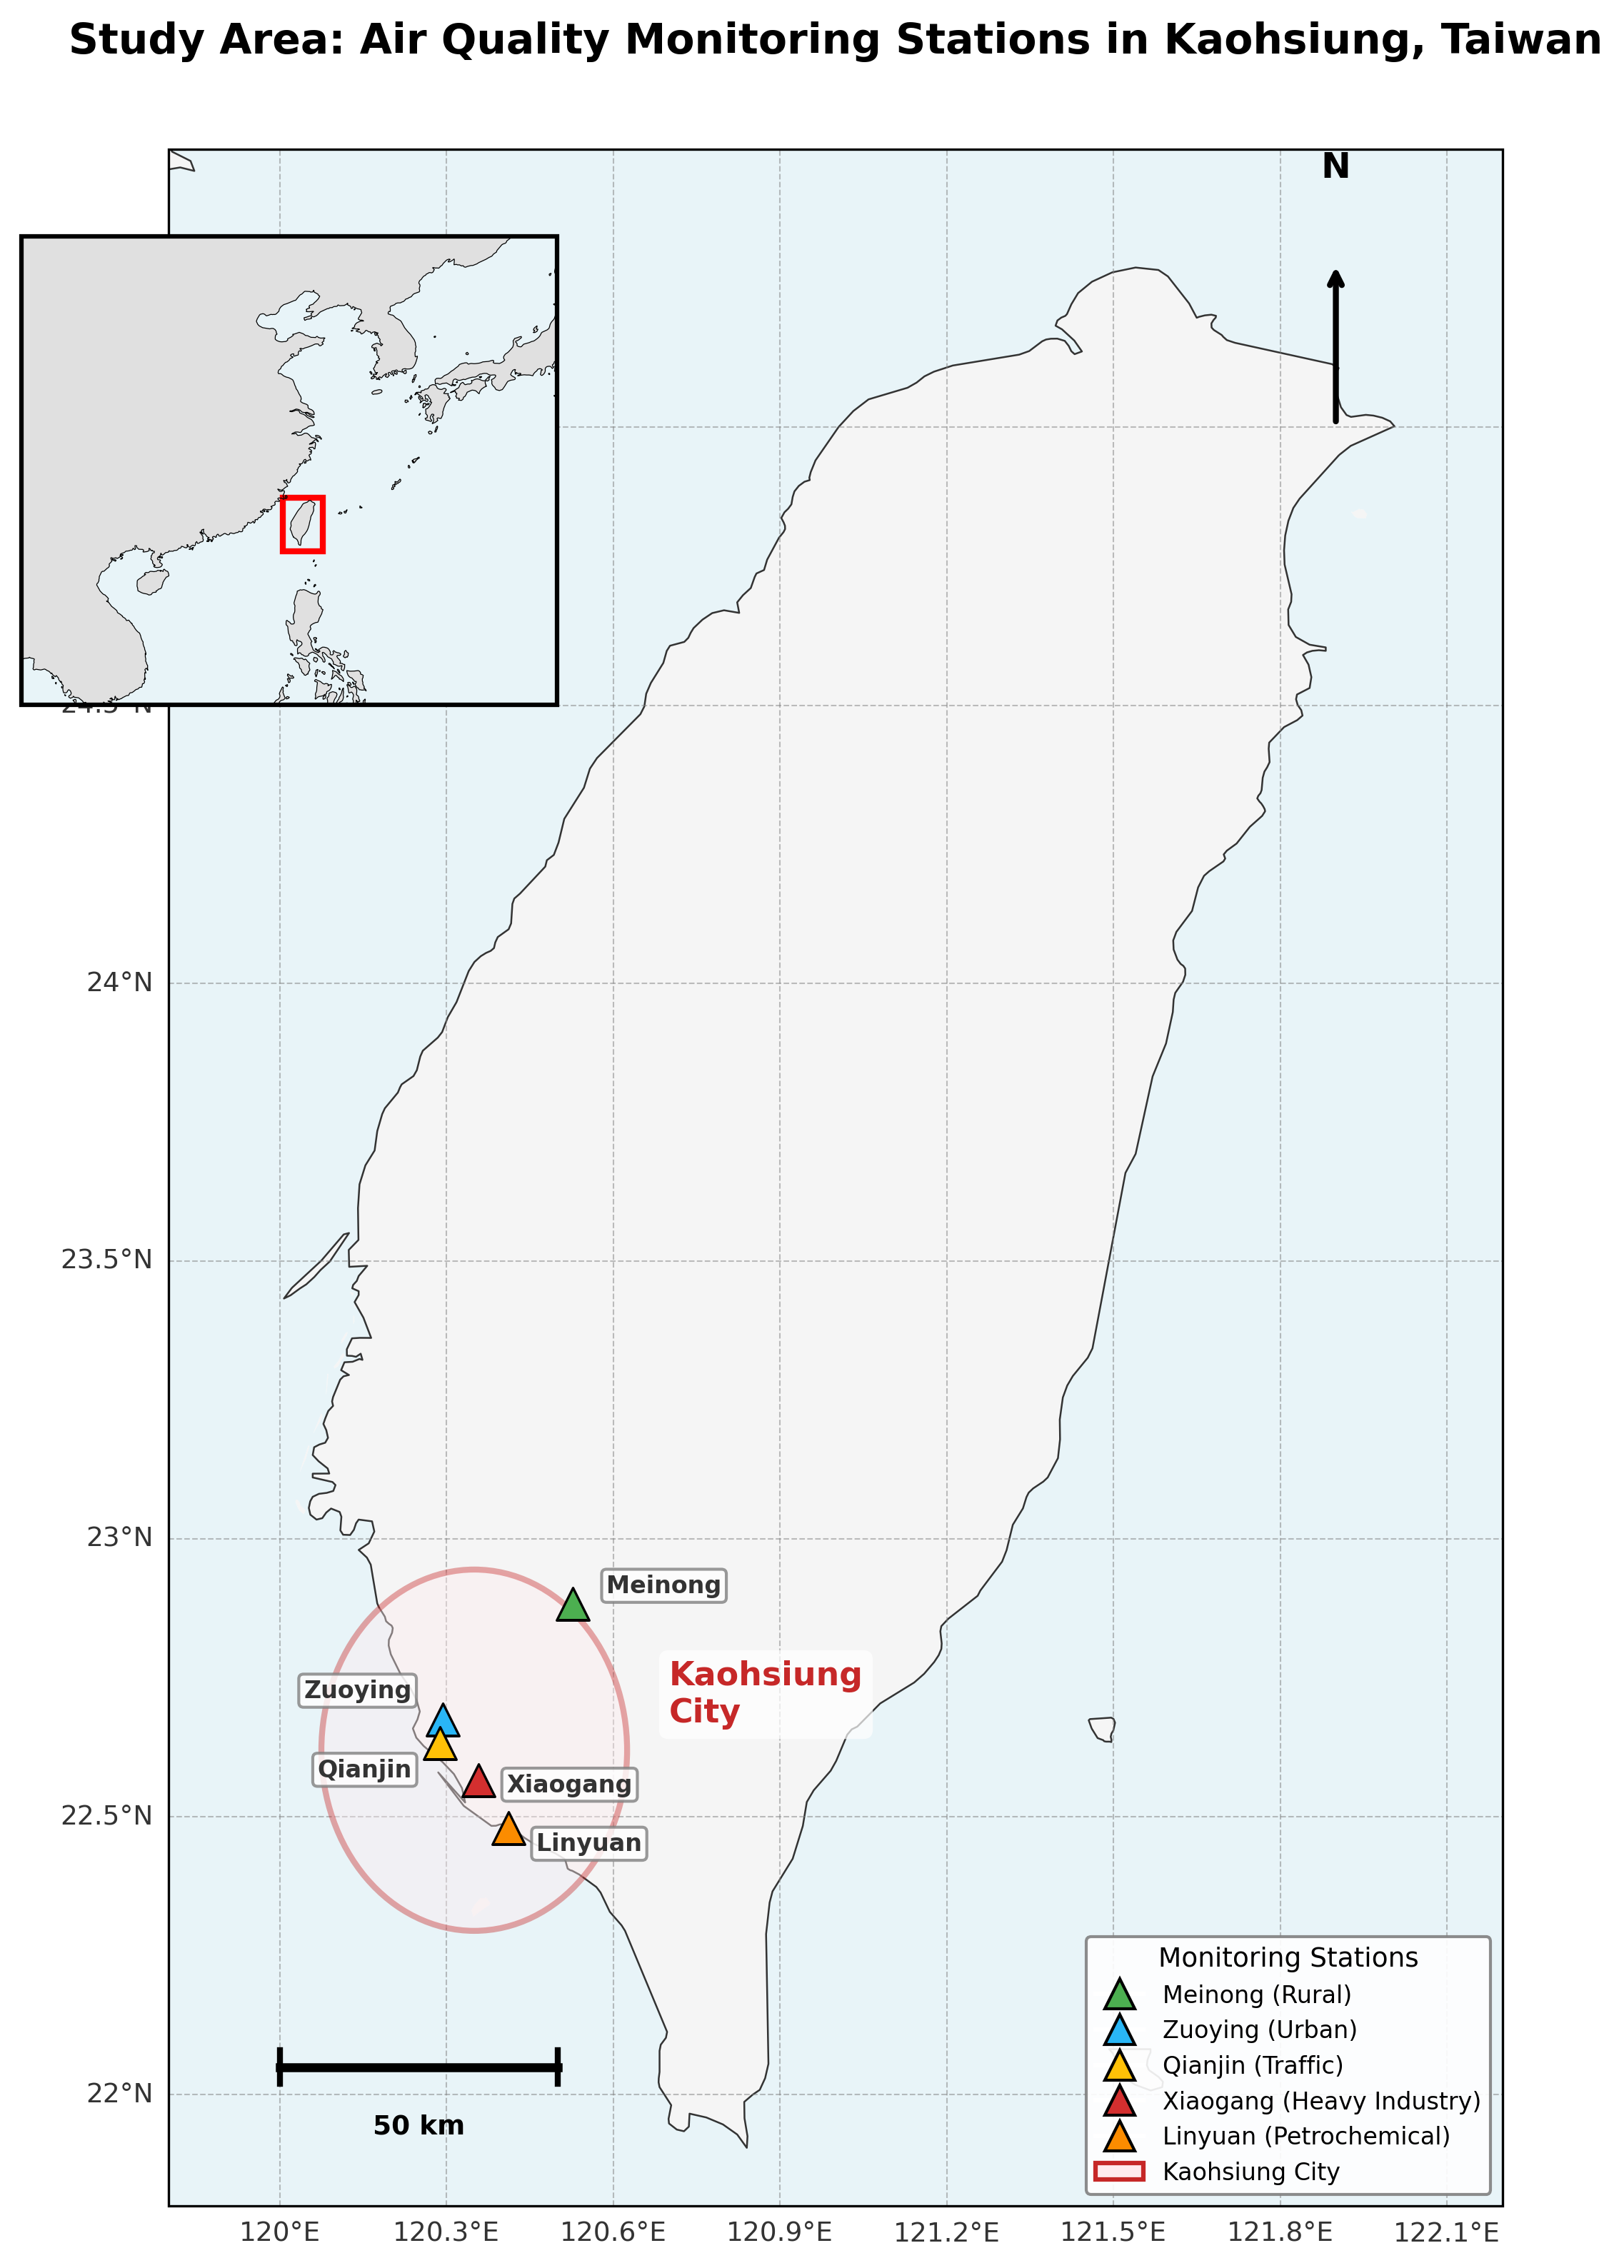

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import pandas as pd

# ==========================================
# 1. 准备站点数据
# ==========================================
site_data = {
    'Site': ['Meinong', 'Zuoying', 'Qianjin', 'Xiaogang', 'Linyuan'],
    'Lat': [22.883583, 22.674860, 22.632566, 22.565725, 22.479500],
    'Lon': [120.527782, 120.292917, 120.288086, 120.358250, 120.411750]
}
df_sites = pd.DataFrame(site_data)

# ==========================================
# 2. 创建主图
# ==========================================
fig = plt.figure(figsize=(10, 12), dpi=300)

# 主地图 (台湾)
ax_main = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection=ccrs.PlateCarree())

# ==========================================
# 3. 添加地图特征
# ==========================================
res = '10m'  # 高分辨率

# 陆地
ax_main.add_feature(cfeature.LAND.with_scale(res), facecolor='#F5F5F5', edgecolor='none')
# 海洋
ax_main.add_feature(cfeature.OCEAN.with_scale(res), facecolor='#E8F4F8')
# 海岸线
ax_main.add_feature(cfeature.COASTLINE.with_scale(res), edgecolor='#333333', linewidth=0.6)

# ==========================================
# 4. 添加经纬度网格 (Gridlines) - SCI 必备
# ==========================================
gl = ax_main.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='--'
)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 9, 'color': '#333333'}
gl.ylabel_style = {'size': 9, 'color': '#333333'}

# ==========================================
# 5. 圈出高雄市
# ==========================================
kao_center_lon = 120.35
kao_center_lat = 22.62

circle = mpatches.Ellipse(
    xy=(kao_center_lon, kao_center_lat),
    width=0.55, height=0.65,
    edgecolor='#C62828',
    facecolor='#FFEBEE',
    alpha=0.4,
    linewidth=2,
    linestyle='-',
    transform=ccrs.PlateCarree(),
    zorder=2
)
ax_main.add_patch(circle)

ax_main.text(kao_center_lon + 0.35, kao_center_lat + 0.1, 'Kaohsiung\nCity',
             transform=ccrs.PlateCarree(),
             fontsize=11, color='#C62828', weight='bold', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7))

# ==========================================
# 6. 标出监测站点
# ==========================================
site_colors = {
    'Meinong': '#4CAF50',
    'Zuoying': '#29B6F6',
    'Qianjin': '#FFC107',
    'Xiaogang': '#D32F2F',
    'Linyuan': '#FB8C00'
}

for _, row in df_sites.iterrows():
    ax_main.scatter(row['Lon'], row['Lat'],
                    color=site_colors[row['Site']],
                    s=120, marker='^',
                    edgecolors='black', linewidth=0.8,
                    transform=ccrs.PlateCarree(),
                    zorder=4)

label_offsets = {
    'Meinong': (0.06, 0.02),
    'Zuoying': (-0.25, 0.04),
    'Qianjin': (-0.22, -0.06),
    'Xiaogang': (0.05, -0.02),
    'Linyuan': (0.05, -0.04)
}

for _, row in df_sites.iterrows():
    offset = label_offsets.get(row['Site'], (0.05, 0.02))
    ax_main.text(row['Lon'] + offset[0], row['Lat'] + offset[1], row['Site'],
                 transform=ccrs.PlateCarree(),
                 fontsize=8, color='#333333', weight='bold',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                           edgecolor='gray', alpha=0.8))

# ==========================================
# 7. 设置主图范围
# ==========================================
ax_main.set_extent([119.8, 122.2, 21.8, 25.5], crs=ccrs.PlateCarree())

# ==========================================
# 8. 添加比例尺 (Scale Bar)
# ==========================================
scale_lon = 120.0
scale_lat = 22.05
scale_length = 0.5

ax_main.plot([scale_lon, scale_lon + scale_length], [scale_lat, scale_lat],
             color='black', linewidth=3, transform=ccrs.PlateCarree(), zorder=5)
ax_main.plot([scale_lon, scale_lon], [scale_lat - 0.03, scale_lat + 0.03],
             color='black', linewidth=2, transform=ccrs.PlateCarree(), zorder=5)
ax_main.plot([scale_lon + scale_length, scale_lon + scale_length], [scale_lat - 0.03, scale_lat + 0.03],
             color='black', linewidth=2, transform=ccrs.PlateCarree(), zorder=5)
ax_main.text(scale_lon + scale_length / 2, scale_lat - 0.12, '50 km',
             transform=ccrs.PlateCarree(), fontsize=9, ha='center', weight='bold')

# ==========================================
# 9. 添加指北针 (North Arrow)
# ==========================================
arrow_x = 121.9
arrow_y = 25.0

ax_main.annotate('', xy=(arrow_x, arrow_y + 0.3), xytext=(arrow_x, arrow_y),
                 arrowprops=dict(arrowstyle='->', color='black', lw=2),
                 transform=ccrs.PlateCarree(), zorder=5)
ax_main.text(arrow_x, arrow_y + 0.45, 'N', transform=ccrs.PlateCarree(),
             fontsize=12, ha='center', weight='bold')

# ==========================================
# 10. 添加嵌套小地图 (Inset Map) - 修复版
# ==========================================
ax_inset = fig.add_axes([0.12, 0.65, 0.25, 0.25], projection=ccrs.PlateCarree())

ax_inset.set_extent([100, 140, 10, 45], crs=ccrs.PlateCarree())

ax_inset.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#E0E0E0')
ax_inset.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#E8F4F8')
ax_inset.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.3)

taiwan_box = mpatches.Rectangle(
    (119.5, 21.5), 3, 4,
    fill=False, edgecolor='red', linewidth=2,
    transform=ccrs.PlateCarree()
)
ax_inset.add_patch(taiwan_box)

# 修复：使用 spines 替代 outline_patch
for spine in ax_inset.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# ==========================================
# 11. 添加图例 (Legend)
# ==========================================
legend_elements = [
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#4CAF50',
           markersize=10, markeredgecolor='black', label='Meinong (Rural)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#29B6F6',
           markersize=10, markeredgecolor='black', label='Zuoying (Urban)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#FFC107',
           markersize=10, markeredgecolor='black', label='Qianjin (Traffic)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#D32F2F',
           markersize=10, markeredgecolor='black', label='Xiaogang (Heavy Industry)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#FB8C00',
           markersize=10, markeredgecolor='black', label='Linyuan (Petrochemical)'),
    mpatches.Patch(facecolor='#FFEBEE', edgecolor='#C62828',
                   linewidth=1.5, label='Kaohsiung City')
]

ax_main.legend(handles=legend_elements, loc='lower right',
               fontsize=8, frameon=True, fancybox=True,
               framealpha=0.9, edgecolor='gray',
               title='Monitoring Stations', title_fontsize=9)

# ==========================================
# 12. 添加标题
# ==========================================
plt.suptitle('Study Area: Air Quality Monitoring Stations in Kaohsiung, Taiwan',
             fontsize=14, weight='bold', y=0.95)

# ==========================================
# 13. 保存
# ==========================================
output_path = 'C:/Users/32052/Desktop/小组/kaohsiung_map_SCI.png'
plt.savefig(output_path, bbox_inches='tight', dpi=300, facecolor='white')

output_pdf = 'C:/Users/32052/Desktop/小组/kaohsiung_map_SCI.pdf'
plt.savefig(output_pdf, bbox_inches='tight', format='pdf')

print(f"PNG 已保存至: {output_path}")
print(f"PDF 已保存至: {output_pdf}")
plt.show()

***数据预处理***

***重复值***

In [10]:
import pandas as pd
# ==========================================
# 1. 读取数据
# ==========================================
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv'
df = pd.read_csv(file_path)

print("=" * 50)
print("【重复值检查报告】")
print("=" * 50)

# ==========================================
# 2. 基础重复值统计
# ==========================================
# 检查完全重复的行（所有列都相同）
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
duplicate_ratio = duplicate_rows / total_rows * 100

print(f"\n总数据量: {total_rows} 条")
print(f"完全重复的行数: {duplicate_rows} 条")
print(f"重复比例: {duplicate_ratio:.2f}%")

# ==========================================
# 3. 查看重复的具体内容
# ==========================================
if duplicate_rows > 0:
    print("\n" + "-" * 50)
    print("【重复数据示例（前10条）】")
    print("-" * 50)
    
    # 找出重复的行
    duplicates = df[df.duplicated(keep=False)]  # keep=False 显示所有重复项
    print(duplicates.head(10))
    
    # 按站点统计重复情况
    print("\n" + "-" * 50)
    print("【各站点重复数据量】")
    print("-" * 50)
    duplicate_by_site = duplicates.groupby('sitename').size()
    print(duplicate_by_site)

# ==========================================
# 4. 基于关键列检查重复（更重要！）
# ==========================================
# 对于时序数据，通常检查：同一站点 + 同一时间 是否有重复
print("\n" + "=" * 50)
print("【基于关键列的重复检查】")
print("（同一站点 + 同一时间 应该只有一条记录）")
print("=" * 50)

key_columns = ['date', 'sitename']  # 关键列：时间 + 站点
key_duplicates = df.duplicated(subset=key_columns).sum()
key_duplicate_ratio = key_duplicates / total_rows * 100

print(f"\n关键列: {key_columns}")
print(f"重复记录数: {key_duplicates} 条")
print(f"重复比例: {key_duplicate_ratio:.2f}%")

if key_duplicates > 0:
    print("\n【关键列重复的数据示例】")
    key_dup_data = df[df.duplicated(subset=key_columns, keep=False)]
    # 按关键列排序，方便查看
    key_dup_data_sorted = key_dup_data.sort_values(by=key_columns)
    print(key_dup_data_sorted.head(20))

# ==========================================
# 5. 重复值详细分析
# ==========================================
print("\n" + "=" * 50)
print("【重复值详细分析】")
print("=" * 50)

# 统计每组重复出现的次数
if key_duplicates > 0:
    dup_counts = df.groupby(key_columns).size().reset_index(name='count')
    dup_counts = dup_counts[dup_counts['count'] > 1]
    
    print(f"\n共有 {len(dup_counts)} 组重复数据")
    print("\n重复次数分布:")
    print(dup_counts['count'].value_counts().sort_index())
    
    print("\n重复最多的记录（前10组）:")
    print(dup_counts.nlargest(10, 'count'))
# ==========================================
# 6. 删除重复值（可选）
# ==========================================
print("\n" + "=" * 50)
print("【删除重复值】")
print("=" * 50)

# 方法一：删除完全重复的行（保留第一条）
#df_clean = df.drop_duplicates()
#print(f"删除完全重复后: {len(df)} → {len(df_clean)} 条")

# 方法二：基于关键列删除重复（保留第一条）
df_clean = df.drop_duplicates(subset=['date', 'sitename'], keep='first')
print(f"基于关键列去重后: {len(df)} → {len(df_clean)} 条")

# 保存清洗后的数据
output_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_final_cleaned2.csv'
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\n清洗后的数据已保存至: {output_path}")

C:\Users\32052\AppData\Local\Temp\ipykernel_8300\1361293650.py:7: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


【重复值检查报告】

总数据量: 223971 条
完全重复的行数: 345 条
重复比例: 0.15%

--------------------------------------------------
【重复数据示例（前10条）】
--------------------------------------------------
                  date sitename   aqi pollutant    status  so2    co    o3  \
108680  2022/3/3 17:00  Meinong  81.0     PM2.5  Moderate  NaN   NaN  70.2   
108681  2022/3/3 17:00  Meinong  81.0     PM2.5  Moderate  NaN   NaN  70.2   
108682  2022/3/3 16:00  Meinong  80.0     PM2.5  Moderate  1.3  0.26  60.2   
108683  2022/3/3 16:00  Meinong  80.0     PM2.5  Moderate  1.3  0.26  60.2   
108684  2022/3/3 15:00  Meinong  82.0     PM2.5  Moderate  1.2  0.25  56.9   
108685  2022/3/3 15:00  Meinong  82.0     PM2.5  Moderate  1.2  0.25  56.9   
108686  2022/3/3 14:00  Meinong  87.0     PM2.5  Moderate  1.2  0.25  55.2   
108687  2022/3/3 14:00  Meinong  87.0     PM2.5  Moderate  1.2  0.25  55.2   
108688  2022/3/3 13:00  Meinong  89.0     PM2.5  Moderate  1.0  0.25  48.7   
108689  2022/3/3 13:00  Meinong  89.0     PM2.5  

***缺失值***

分析的变量数量: 16
变量列表: ['AQI', 'PM2.5', 'PM10', 'O3', 'O3_8hr', 'NO2', 'SO2', 'CO', 'NOx', 'NO', 'windspeed', 'winddirec', 'PM2.5_avg', 'PM10_avg', 'SO2_avg', 'CO_8hr']

热力图已保存至: C:/Users/32052/Desktop/小组/variable_missing_heatmap.png


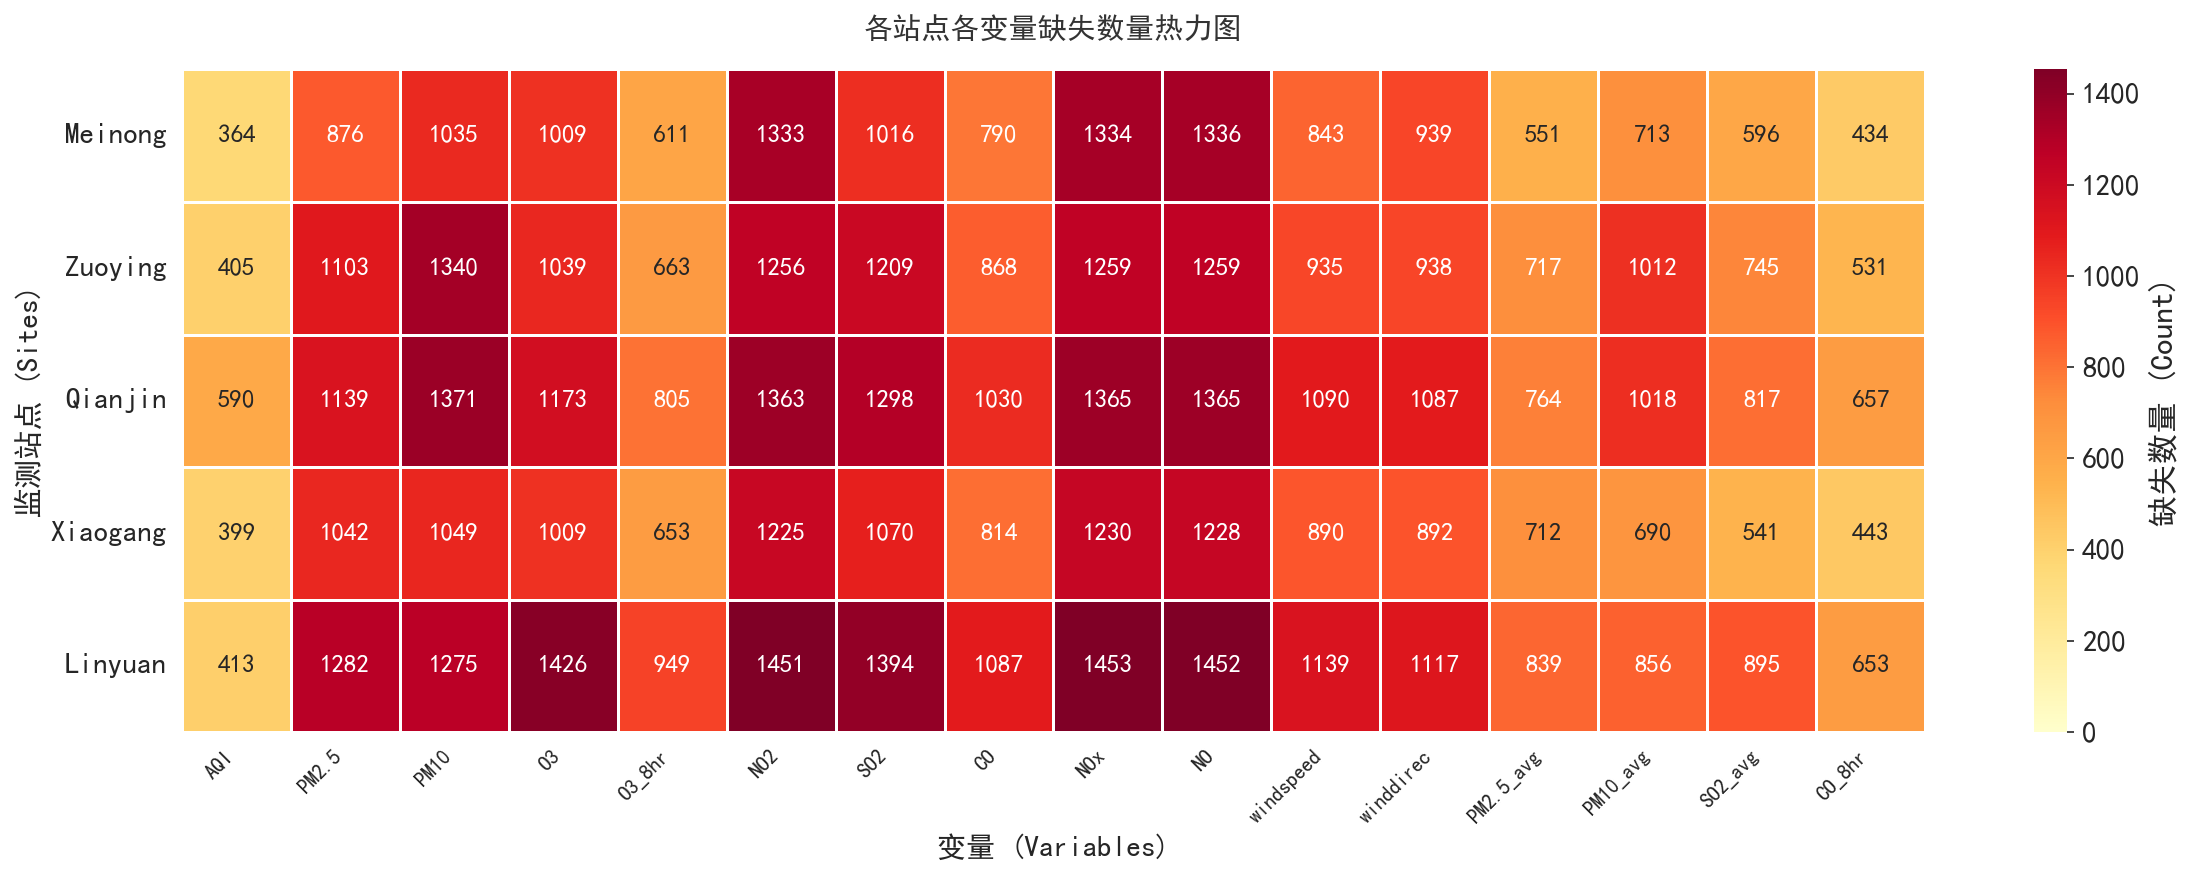


【各站点数据完整性统计】
每站点记录数: 40800
分析变量数: 16
每站点总单元格数: 652800

Meinong     : 完整 640,940 ( 97.90%)  缺失  13,780 ( 2.10%)
Zuoying     : 完整 639,441 ( 97.67%)  缺失  15,279 ( 2.33%)
Qianjin     : 完整 637,788 ( 97.41%)  缺失  16,932 ( 2.59%)
Xiaogang    : 完整 640,833 ( 97.88%)  缺失  13,887 ( 2.12%)
Linyuan     : 完整 637,039 ( 97.30%)  缺失  17,681 ( 2.70%)

堆叠图已保存至: C:/Users/32052/Desktop/小组/site_completeness_stacked.png


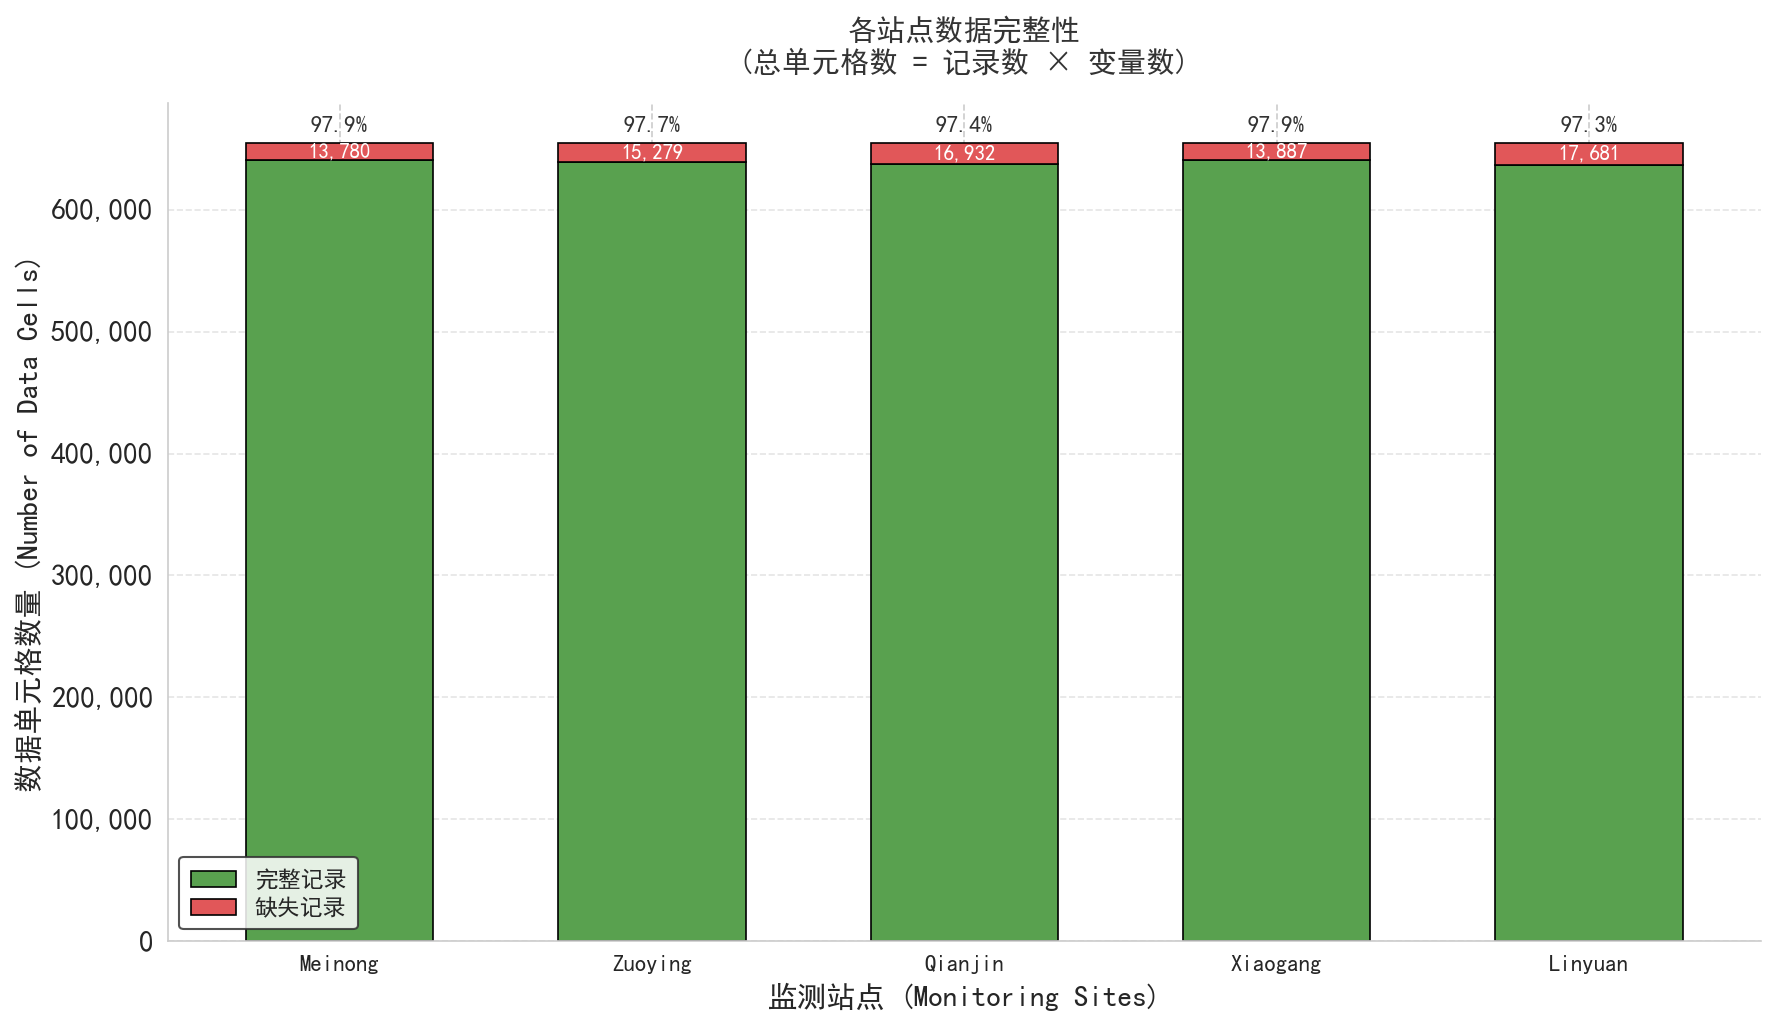


【详细统计报告】

--- 各站点各变量缺失统计 ---

【Meinong】
变量              | 缺失数量         | 缺失比例        
---------------------------------------------
AQI             | 364          | 0.89%
PM2.5           | 876          | 2.14%
PM10            | 1035         | 2.53%
O3              | 1009         | 2.47%
O3_8hr          | 611          | 1.49%
NO2             | 1333         | 3.26%
SO2             | 1016         | 2.48%
CO              | 790          | 1.93%
NOx             | 1334         | 3.26%
NO              | 1336         | 3.26%
windspeed       | 843          | 2.06%
winddirec       | 939          | 2.29%
PM2.5_avg       | 551          | 1.35%
PM10_avg        | 713          | 1.74%
SO2_avg         | 596          | 1.46%
CO_8hr          | 434          | 1.06%
总缺失: 13780

【Zuoying】
变量              | 缺失数量         | 缺失比例        
---------------------------------------------
AQI             | 405          | 0.99%
PM2.5           | 1103         | 2.70%
PM10            | 1340         | 3.27%
O3          

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 风格与配色设置
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 加载补齐后的数据
# ==========================================
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete.csv'
df_filled = pd.read_csv(file_path)
df_filled['date'] = pd.to_datetime(df_filled['date'])

sites_order = ['Meinong', 'Zuoying', 'Qianjin', 'Xiaogang', 'Linyuan']

# 定义要分析的变量（按类别分组）
pollutant_cols = ['AQI', 'PM2.5', 'PM10', 'O3', 'O3_8hr', 'NO2', 'SO2', 'CO', 'NOx', 'NO']
meteorological_cols = ['windspeed', 'winddirec']
avg_cols = ['PM2.5_avg', 'PM10_avg', 'SO2_avg', 'CO_8hr']

# 所有需要分析的列
all_value_cols = pollutant_cols + meteorological_cols + avg_cols

# 筛选数据中实际存在的列
existing_cols = [col for col in all_value_cols if col in df_filled.columns]
print(f"分析的变量数量: {len(existing_cols)}")
print(f"变量列表: {existing_cols}")

# ==========================================
# 3. 统计各站点各变量缺失情况
# ==========================================
def analyze_variable_missing(df, sites, value_cols):
    """
    统计每个站点每个变量的缺失情况
    """
    missing_matrix = []
    missing_pct_matrix = []
    
    for site in sites:
        site_df = df[df['sitename'] == site]
        total_records = len(site_df)
        
        site_missing = []
        site_missing_pct = []
        
        for col in value_cols:
            if col in site_df.columns:
                missing_count = site_df[col].isna().sum()
                missing_pct = (missing_count / total_records) * 100
            else:
                missing_count = total_records
                missing_pct = 100.0
            
            site_missing.append(missing_count)
            site_missing_pct.append(missing_pct)
        
        missing_matrix.append(site_missing)
        missing_pct_matrix.append(site_missing_pct)
    
    # 创建DataFrame
    missing_df = pd.DataFrame(missing_matrix, index=sites, columns=value_cols)
    missing_pct_df = pd.DataFrame(missing_pct_matrix, index=sites, columns=value_cols)
    
    return missing_df, missing_pct_df

missing_count_df, missing_pct_df = analyze_variable_missing(df_filled, sites_order, existing_cols)

# ==========================================
# 4. 绘制图1: 缺失数量热力图
# ==========================================
fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

sns.heatmap(
    missing_count_df, 
    annot=True,           # 显示数值
    fmt='.0f',            # 整数格式
    cmap='YlOrRd',        # 黄-橙-红配色
    ax=ax,
    linewidths=0.5,       # 单元格边框
    linecolor='white',
    cbar_kws={'label': '缺失数量 (Count)'},
    vmin=0,
    square=False,
    annot_kws={'fontsize':12}
)

ax.set_title('各站点各变量缺失数量热力图', fontsize=14, weight='bold', pad=15, color='#333333')
ax.set_xlabel('变量 (Variables)', fontsize=14, weight='bold')
ax.set_ylabel('监测站点 (Sites)', fontsize=14, weight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

plt.tight_layout()
plt.savefig('C:/Users/32052/Desktop/小组/variable_missing_heatmap.png', 
            dpi=300, bbox_inches='tight')
print("\n热力图已保存至: C:/Users/32052/Desktop/小组/variable_missing_heatmap.png")
plt.show()

# ==========================================
# 5. 计算堆叠图数据
# ==========================================
expected_count = 40800  # 每个站点的总时间点数
total_variables = len(existing_cols)  # 变量总数

# 统计每个站点的完整和缺失数据单元格数
stack_data = []
for site in sites_order:
    site_df = df_filled[df_filled['sitename'] == site]
    
    # 计算该站点所有变量的总缺失数
    total_missing = 0
    for col in existing_cols:
        if col in site_df.columns:
            total_missing += site_df[col].isna().sum()
        else:
            total_missing += len(site_df)
    
    # 总单元格数 = 记录数 × 变量数
    total_cells = len(site_df) * total_variables
    total_complete = total_cells - total_missing
    
    stack_data.append({
        'Site': site,
        'Complete': total_complete,
        'Missing': total_missing
    })

plot_data = pd.DataFrame(stack_data)

print("\n" + "="*70)
print("【各站点数据完整性统计】")
print("="*70)
print(f"每站点记录数: {expected_count}")
print(f"分析变量数: {total_variables}")
print(f"每站点总单元格数: {expected_count * total_variables}\n")

for _, row in plot_data.iterrows():
    total = row['Complete'] + row['Missing']
    complete_pct = (row['Complete'] / total) * 100
    missing_pct = (row['Missing'] / total) * 100
    print(f"{row['Site']:<12}: 完整 {int(row['Complete']):>7,} ({complete_pct:>6.2f}%)  "
          f"缺失 {int(row['Missing']):>7,} ({missing_pct:>5.2f}%)")

# ==========================================
# 6. 绘制图2: 各站点总缺失占比堆叠柱状图
# ==========================================
fig, ax = plt.subplots(figsize=(12, 7), dpi=150)

# 绘制堆叠柱状图
plot_data_indexed = plot_data.set_index('Site')[['Complete', 'Missing']]
plot_data_indexed.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=['#59A14F', '#E15759'],  # 绿色=完整，红色=缺失
    edgecolor='black',
    linewidth=0.8,
    width=0.6
)

ax.set_title('各站点数据完整性\n(总单元格数 = 记录数 × 变量数)', 
             fontsize=14, weight='bold', pad=15, color='#333333')
ax.set_xlabel('监测站点 (Monitoring Sites)', fontsize=14, weight='bold')
ax.set_ylabel('数据单元格数量 (Number of Data Cells)', fontsize=14, weight='bold')
ax.tick_params(axis='x', rotation=0, labelsize=11)
# 改进的图例设置
legend = ax.legend(
    ['完整记录', '缺失记录'], 
    loc='best',              # 自动选择最佳位置
    fontsize=11, 
    frameon=True,            # 显示边框
    shadow=False,            # 取消阴影，更简洁
    framealpha=0.85,         # 背景透明度 (0完全透明, 1完全不透明)
    facecolor='white',       # 背景颜色
    edgecolor='#333333',     # 边框颜色
    borderpad=0.5,           # 图例内边距
    labelspacing=0.3         # 图例项之间的间距
)

# 添加网格
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 添加完整率标签
for i, (_, row) in enumerate(plot_data.iterrows()):
    total = row['Complete'] + row['Missing']
    completeness = (row['Complete'] / total) * 100
    missing_pct = (row['Missing'] / total) * 100
    
    # 在柱子顶部标注完整率
    ax.text(i, total + total * 0.01, 
            f'{completeness:.1f}%', 
            ha='center', va='bottom',
            fontsize=11, weight='bold', color='#333333')
    
    # 在缺失部分标注缺失数量（如果缺失较多才标注）
    if row['Missing'] > total * 0.02:  # 缺失超过2%才标注
        ax.text(i, row['Complete'] + row['Missing']/2, 
                f"{int(row['Missing']):,}",
                ha='center', va='center',
                fontsize=10, weight='bold', color='white')

# 设置y轴格式（使用千位分隔符）
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# 移除多余边框
sns.despine()

plt.tight_layout()
plt.savefig('C:/Users/32052/Desktop/小组/site_completeness_stacked.png', 
            dpi=300, bbox_inches='tight')
print("\n堆叠图已保存至: C:/Users/32052/Desktop/小组/site_completeness_stacked.png")
plt.show()

# ==========================================
# 7. 详细统计报告
# ==========================================
print("\n" + "="*70)
print("【详细统计报告】")
print("="*70)

# 各站点统计
print("\n--- 各站点各变量缺失统计 ---")
for site in sites_order:
    site_data = missing_count_df.loc[site]
    site_pct = missing_pct_df.loc[site]
    
    missing_vars = site_data[site_data > 0]
    
    if len(missing_vars) > 0:
        print(f"\n【{site}】")
        print(f"{'变量':<15} | {'缺失数量':<12} | {'缺失比例':<12}")
        print("-" * 45)
        for var in missing_vars.index:
            count = site_data[var]
            pct = site_pct[var]
            print(f"{var:<15} | {int(count):<12} | {pct:.2f}%")
        print(f"总缺失: {int(missing_vars.sum())}")
    else:
        print(f"\n【{site}】: 无缺失值")

# 变量统计
print("\n--- 各变量跨站点缺失统计 ---")
var_total = missing_count_df.sum(axis=0)
var_total_sorted = var_total[var_total > 0].sort_values(ascending=False)

if len(var_total_sorted) > 0:
    print(f"{'变量':<15} | {'总缺失数':<12} | {'平均缺失/站':<15}")
    print("-" * 50)
    for var, total in var_total_sorted.items():
        avg = total / len(sites_order)
        print(f"{var:<15} | {int(total):<12} | {avg:.1f}")
else:
    print("所有变量均无缺失")

# 完全无缺失的变量
complete_vars = var_total[var_total == 0]
if len(complete_vars) > 0:
    print(f"\n完全无缺失的变量 ({len(complete_vars)}个):")
    print(f"  {', '.join(complete_vars.index)}")

print("\n" + "="*70)

In [11]:
import pandas as pd
import numpy as np

# ==========================================
# 1. 加载数据
# ==========================================
# 建议将路径替换为您的实际文件路径
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete.csv'

print(f"正在读取文件: {file_path} ...")
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

# 定义所有可能的特征列 (自动匹配存在的列)
potential_features = [
    'AQI', 'PM2.5', 'PM10', 'O3', 'O3_8hr', 'NO2', 'SO2', 'CO', 'NOx', 'NO',
    'windspeed', 'winddirec', 
    'PM2.5_avg', 'PM10_avg', 'SO2_avg', 'CO_8hr'
]

# 过滤掉文件中不存在的列
features_to_check = [c for c in potential_features if c in df.columns]
sites = df['sitename'].unique()

print(f"检查站点: {sites}")
print(f"检查特征: {features_to_check}")
print("="*80)

# ==========================================
# 2. 检测连续缺失 >= 6小时的逻辑
# ==========================================
found_any_long_gap = False

for site in sites:
    print(f"\n🔵 正在分析站点: 【{site}】")
    
    # 提取该站点数据并重置索引，确保时间连续排序
    site_df = df[df['sitename'] == site].sort_values('date').reset_index(drop=True)
    
    site_has_long_gap = False
    
    for col in features_to_check:
        # 获取缺失值的布尔序列 (True为缺失)
        is_nan = site_df[col].isna()
        
        # 如果整列都没有缺失，直接跳过
        if not is_nan.any():
            continue
        
        # -----------------------------------------------------------
        # 核心技巧：利用 (value != value.shift()).cumsum() 进行分组
        # -----------------------------------------------------------
        # 1. 找出状态变化的位置 (从非空变空，或从空变非空)
        # 2. cumsum() 生成分组ID，使得每一段连续的 NaN 或 非NaN 都有相同的ID
        groups = (is_nan != is_nan.shift()).cumsum()
        
        # 3. 只筛选出 NaN 的那些组
        #    group_sizes: 索引是分组ID，值是该组的长度
        nan_groups = site_df[is_nan].groupby(groups[is_nan])
        
        # 4. 统计每一段缺失的信息
        gaps = nan_groups.agg(
            start_time=('date', 'min'),
            end_time=('date', 'max'),
            count=('date', 'count')  # 计算长度
        )
        
        # 5. 筛选出长度 >= 6 的段
        long_gaps = gaps[gaps['count'] >= 6]
        
        if not long_gaps.empty:
            site_has_long_gap = True
            found_any_long_gap = True
            print(f"  ⚠️ 特征 [{col}] 发现 {len(long_gaps)} 个长缺失段:")
            
            for _, row in long_gaps.iterrows():
                # 格式化打印
                print(f"     • {row['start_time']} ~ {row['end_time']} (连续缺失 {row['count']} 小时)")

    if not site_has_long_gap:
        print("  ✅ 该站点没有发现任何特征存在 6小时及以上 的连续缺失。")

print("\n" + "="*80)
if not found_any_long_gap:
    print("🎉 结果：整个数据集中没有任何特征存在连续 6 小时以上的缺失。")
else:
    print("📋 结果：以上列出的时间段是‘长缺失’，建议使用【历史同期均值】填充。")
    print("   (未列出的短缺失建议使用线性插值)")

正在读取文件: C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete.csv ...


C:\Users\32052\AppData\Local\Temp\ipykernel_15728\3815520977.py:11: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


检查站点: ['Meinong' 'Zuoying' 'Qianjin' 'Xiaogang' 'Linyuan']
检查特征: ['AQI', 'PM2.5', 'PM10', 'O3', 'O3_8hr', 'NO2', 'SO2', 'CO', 'NOx', 'NO', 'windspeed', 'winddirec', 'PM2.5_avg', 'PM10_avg', 'SO2_avg', 'CO_8hr']

🔵 正在分析站点: 【Meinong】
  ⚠️ 特征 [AQI] 发现 16 个长缺失段:
     • 2020-11-16 01:00:00 ~ 2020-11-16 12:00:00 (连续缺失 12 小时)
     • 2020-11-16 14:00:00 ~ 2020-11-17 00:00:00 (连续缺失 11 小时)
     • 2020-11-17 02:00:00 ~ 2020-11-19 13:00:00 (连续缺失 60 小时)
     • 2021-07-19 16:00:00 ~ 2021-07-20 00:00:00 (连续缺失 9 小时)
     • 2021-07-30 11:00:00 ~ 2021-08-01 23:00:00 (连续缺失 61 小时)
     • 2021-08-13 16:00:00 ~ 2021-08-13 22:00:00 (连续缺失 7 小时)
     • 2021-08-14 00:00:00 ~ 2021-08-14 08:00:00 (连续缺失 9 小时)
     • 2021-12-23 15:00:00 ~ 2021-12-24 08:00:00 (连续缺失 18 小时)
     • 2021-12-27 16:00:00 ~ 2021-12-27 23:00:00 (连续缺失 8 小时)
     • 2022-02-07 17:00:00 ~ 2022-02-07 23:00:00 (连续缺失 7 小时)
     • 2022-08-30 00:00:00 ~ 2022-08-30 05:00:00 (连续缺失 6 小时)
     • 2023-05-22 19:00:00 ~ 2023-05-24 17:00:00 (连续缺失 47 小时)
   

C:\Users\32052\AppData\Local\Temp\ipykernel_15728\2960877429.py:18: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, dtype={'pm2.5': object})


发现 'ND' 记录数: 11
绘图时间范围: 2019-12-02 至 2020-05-07
图表已保存至: C:/Users/32052/Desktop/小组/PM25_ND_timeline_focused.png


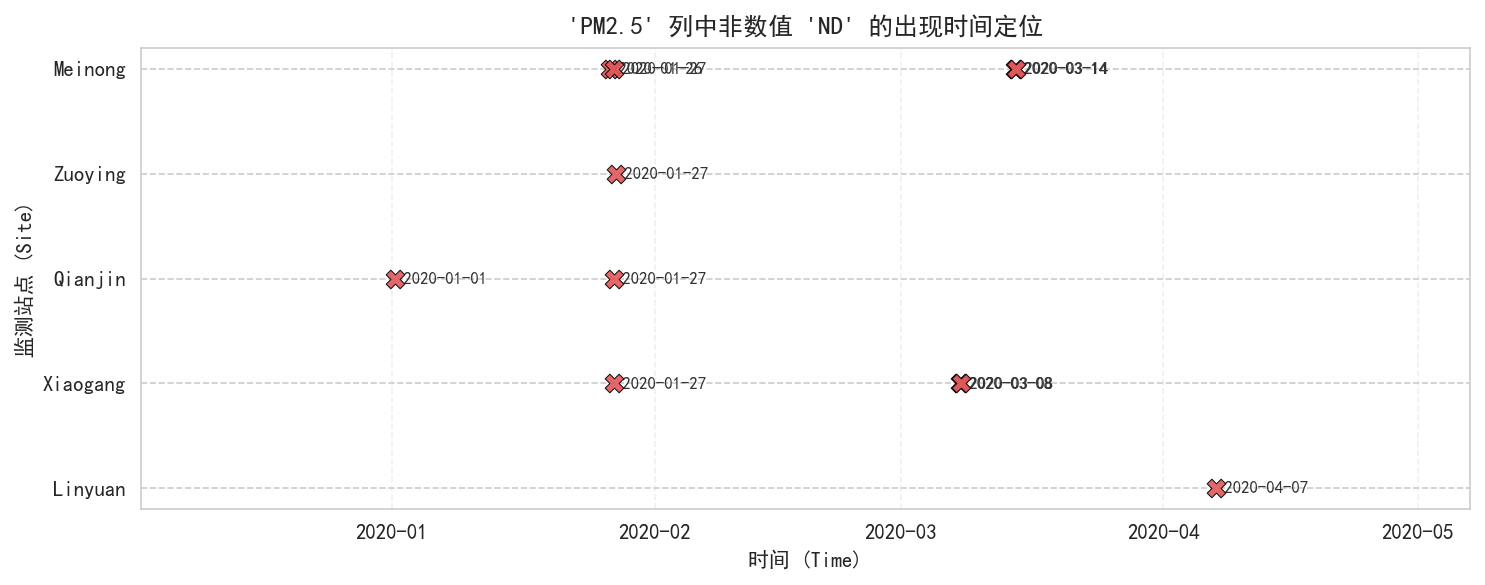

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# ==========================================
# 1. 风格设置
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial'] 
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 2. 加载数据
# ==========================================
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete.csv'
# dtype={'pm2.5': object} 确保ND被读取为字符串
df = pd.read_csv(file_path, dtype={'pm2.5': object}) 
df['date'] = pd.to_datetime(df['date'])
df.columns = [c.lower().strip() for c in df.columns]

# ==========================================
# 3. 提取并筛选数据
# ==========================================
target_col = 'pm2.5'
nd_mask = df[target_col].astype(str).str.strip().str.upper() == 'ND'
nd_data = df[nd_mask].copy()

print(f"发现 'ND' 记录数: {len(nd_data)}")

if len(nd_data) > 0:
    # ==========================================
    # 4. 智能计算时间范围 (Smart Cropping)
    # ==========================================
    # 获取最早和最晚出现ND的时间
    start_nd = nd_data['date'].min()
    end_nd = nd_data['date'].max()
    
    # 增加一点前后余量 (比如前后各加1个月，让图不那么挤)
    plot_start = start_nd - pd.Timedelta(days=30)
    plot_end = end_nd + pd.Timedelta(days=30)
    
    print(f"绘图时间范围: {plot_start.date()} 至 {plot_end.date()}")

    # ==========================================
    # 5. 绘制紧凑型散点图
    # ==========================================
    fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
    
    # 绘制 "ND" 事件点
    sns.scatterplot(
        data=nd_data, 
        x='date', 
        y='sitename', 
        color='#E15759',  # 红色
        s=80,             # 点稍大一点，因为点很少
        marker='X',       # 叉号
        edgecolor='black',
        linewidth=0.5,
        alpha=0.9,
        ax=ax,
        zorder=5
    )
    
    # 设置标题和标签
    ax.set_title(f"'{target_col.upper()}' 列中非数值 'ND' 的出现时间定位", fontsize=12, weight='bold')
    ax.set_xlabel('时间 (Time)', fontsize=10)
    ax.set_ylabel('监测站点 (Site)', fontsize=10)
    
    # 关键步骤：设置X轴范围，只显示有数据的时段
    ax.set_xlim(plot_start, plot_end)
    
    # 优化X轴日期格式 (显示 年-月)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) # 每个月显示一个刻度
    plt.xticks(rotation=0)
    
    # 添加网格以辅助定位
    ax.grid(True, axis='x', linestyle='--', alpha=0.3)

    # 在每个点旁边标注具体日期 (可选，因为点很少，标出来很清晰)
    for idx, row in nd_data.iterrows():
        ax.text(
            row['date'], 
            row['sitename'], 
            f" {row['date'].strftime('%Y-%m-%d')}", 
            fontsize=8, 
            color='#333333',
            va='center'
        )

    plt.tight_layout()
    
    # 保存
    output_img = 'C:/Users/32052/Desktop/小组/PM25_ND_timeline_focused.png'
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"图表已保存至: {output_img}")
    
    plt.show()
else:
    print("未发现 'ND' 数据，无需绘图。")

In [16]:
import pandas as pd
import numpy as np

# ==========================================
# 1. 准备数据
# ==========================================
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete.csv'
print(f"正在读取文件: {file_path}")
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

# 统一列名格式（转小写并去空格，防止大小写不匹配）
df.columns = [c.strip() for c in df.columns]

# 定义需要处理的列 (根据您提供的列表)
target_cols = [
   'AQI', 'SO2', 'CO', 'O3', 'O3_8hr', 'PM10', 'PM2.5', 'NO2', 'NOx', 'NO',
   'windspeed', 'winddirec', 
   'PM2.5_avg', 'PM10_avg', 'SO2_avg', 'CO_8hr'
]

# 筛选出实际存在的列
cols_to_fill = [c for c in target_cols if c in df.columns]

# ==========================================
# 2. 核心函数：严格分级填充策略
# ==========================================
def advanced_imputation_strict(df, cols, limit=6):
    """
    策略：
    1. 计算连续缺失长度。
    2. 长度 <= 6: 线性插值。
    3. 长度 > 6: 线性插值不碰它，全部留给历史同期均值填充。
    """
    df_filled = df.copy()
    
    # 添加辅助时间列
    df_filled['month'] = df_filled['date'].dt.month
    df_filled['day'] = df_filled['date'].dt.day
    df_filled['hour'] = df_filled['date'].dt.hour
    
    for site in df_filled['sitename'].unique():
        print(f"正在处理站点: {site}...")
        site_mask = (df_filled['sitename'] == site)
        
        for col in cols:
            # 获取该站点该列的数据
            series = df_filled.loc[site_mask, col]
            
            # -------------------------------------------------------
            # 第一步：智能线性插值
            # -------------------------------------------------------
            # 1. 标记缺失值
            is_nan = series.isna()
            
            # 2. 计算每一段连续缺失的长度 (Group Size)
            # (利用 cumsum 生成分组ID)
            gap_groups = (is_nan != is_nan.shift()).cumsum()
            # 计算每个组的长度，并映射回原索引
            gap_sizes = series.groupby(gap_groups).transform('size')
            
            # 3. 定义“短缺失”掩码 (是NaN 且 长度<=6)
            mask_short_gap = is_nan & (gap_sizes <= limit)
            
            # 4. 仅对短缺失进行插值
            # 先生成一个全插值的序列
            interp_all = series.interpolate(method='linear', limit_direction='both')
            
            # 将插值结果应用到原始数据，但只应用在“短缺失”的地方
            # 这样“长缺失”依然保持为NaN
            series_filled_step1 = series.copy()
            series_filled_step1[mask_short_gap] = interp_all[mask_short_gap]
            
            # 更新回主表
            df_filled.loc[site_mask, col] = series_filled_step1
            
            # -------------------------------------------------------
            # 第二步：历史同期填充 (处理剩余的长缺失)
            # -------------------------------------------------------
            # 此时剩下的 NaN 都是连续缺失 > 6 的
            remaining_nans = df_filled.loc[site_mask, col].isna()
            
            if remaining_nans.sum() > 0:
                nan_indices = df_filled[site_mask & remaining_nans].index
                
                for idx in nan_indices:
                    row = df_filled.loc[idx]
                    m, d, h = row['month'], row['day'], row['hour']
                    
                    # 查找历史同期 (同站点、同月、同日、同小时)
                    history_values = df_filled.loc[
                        (df_filled['sitename'] == site) & 
                        (df_filled['month'] == m) & 
                        (df_filled['day'] == d) & 
                        (df_filled['hour'] == h) &
                        (df_filled[col].notna()), # 必须是非空值
                        col
                    ]
                    
                    if len(history_values) > 0:
                        df_filled.loc[idx, col] = history_values.mean()
                    else:
                        # 兜底策略：如果同日没数据，用同月同小时均值
                        backup_values = df_filled.loc[
                            (df_filled['sitename'] == site) & 
                            (df_filled['month'] == m) & 
                            (df_filled['hour'] == h) &
                            (df_filled[col].notna()), 
                            col
                        ]
                        if len(backup_values) > 0:
                            df_filled.loc[idx, col] = backup_values.mean()

    # 清理辅助列
    df_filled = df_filled.drop(columns=['month', 'day', 'hour'])
    return df_filled

# ==========================================
# 3. 执行填充
# ==========================================
# limit=6 表示连续缺失6个及以内插值，超过6个则跳过
df_final = advanced_imputation_strict(df, cols_to_fill, limit=6)

# ==========================================
# 4. 验证与保存
# ==========================================
nan_remaining = df_final[cols_to_fill].isna().sum().sum()
print("\n" + "="*50)
print(f"处理后剩余缺失: {nan_remaining}")

if nan_remaining > 0:
    print("状态: ⚠️ 仍有极少量缺失（可能是历史数据不足），执行最终兜底(ffill)...")
    # 最后的保险：向前/向后填充
    df_final[cols_to_fill] = df_final.groupby('sitename')[cols_to_fill].ffill().bfill()
else:
    print("状态: ✅ 所有数值已完美补全")

output_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete1.csv'
df_final.to_csv(output_path, index=False)
print(f"文件已保存至: {output_path}")

正在读取文件: C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete.csv
正在处理站点: Meinong...
正在处理站点: Zuoying...
正在处理站点: Qianjin...
正在处理站点: Xiaogang...
正在处理站点: Linyuan...

处理后剩余缺失: 0
状态: ✅ 所有数值已完美补全
文件已保存至: C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete1.csv


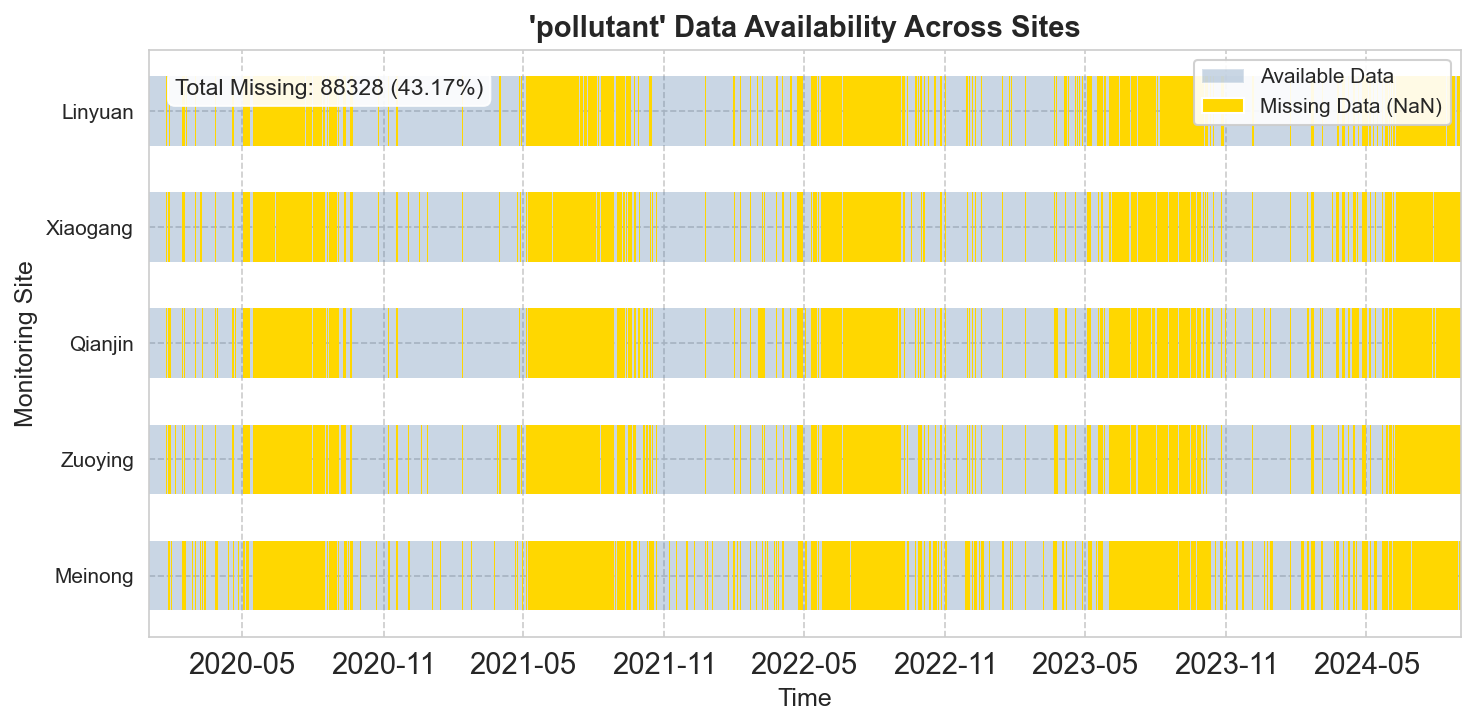

图表已保存至: C:/Users/32052/Desktop/小组/missing_intervals_pollutant_sci.png


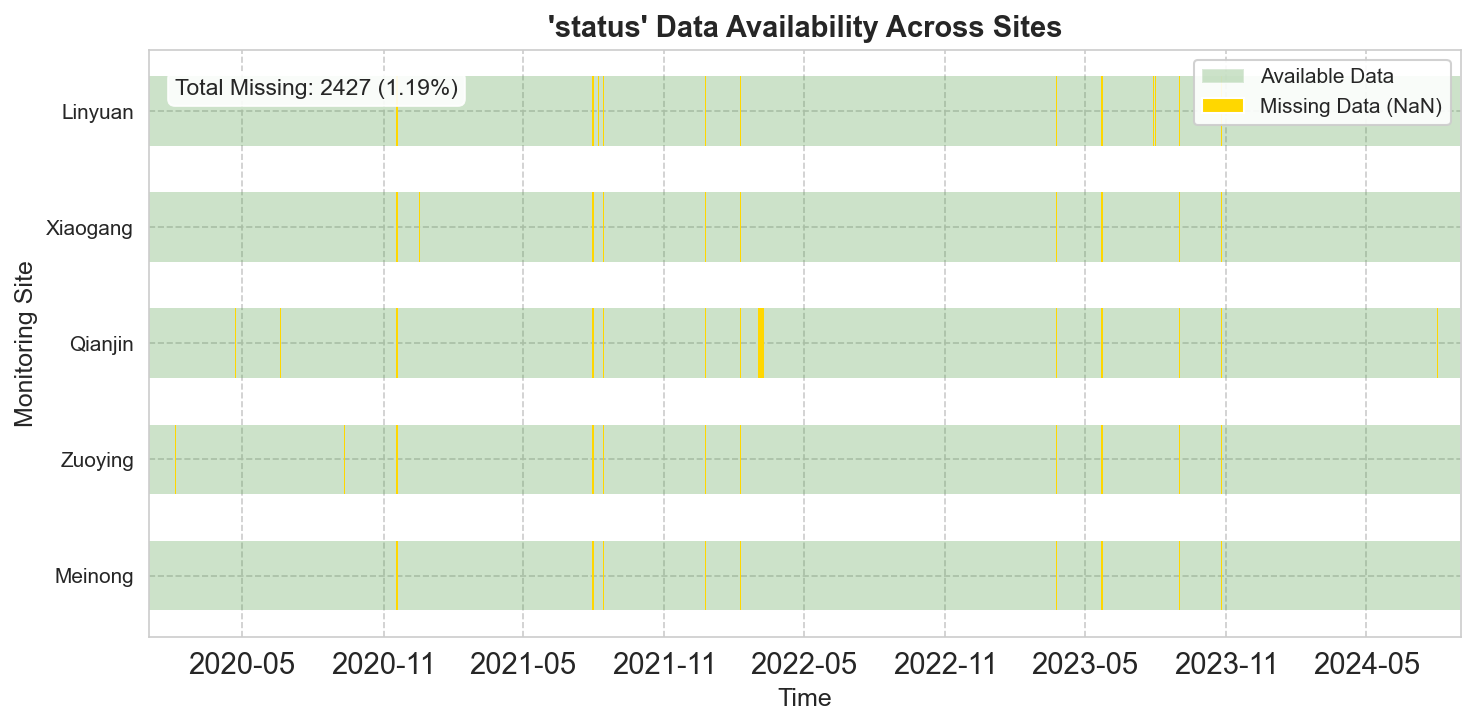

图表已保存至: C:/Users/32052/Desktop/小组/missing_intervals_status_sci.png


In [34]:
#pollutant列中本身就会存在空白的事后，不是每天都被高污染物影响，status要根据pollutant来决定。处理完异常值后再处理这个分类数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# 风格设置
# ==========================================
plt.rcParams['font.sans-serif'] = ['Arial', 'SimHei'] # 适应中文和科学字体
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

# ==========================================
# 加载数据
# ==========================================
# 请注意：我无法访问您的本地文件路径，这里使用提供的路径进行模拟
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete1.csv'
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

# 确保列名存在并定义颜色
cat_cols = ['pollutant', 'status']
cat_cols = [c for c in cat_cols if c in df.columns]
sites_order = list(df['sitename'].unique())

# 定义颜色
colors = ['#4E79A7', '#59A14F'] # 两种不同的主题色
missing_color = '#FFD700'  # 金黄色，突出显示缺失

# ==========================================
# 找出连续缺失区间
# ==========================================
def find_missing_intervals(df, col, site):
    """找出连续缺失的时间区间"""
    site_df = df[df['sitename'] == site].sort_values('date').reset_index(drop=True)
    is_nan = site_df[col].isna()
    
    if not is_nan.any():
        return []
    
    # 分组：利用 cumsum 标记连续缺失的组
    groups = (is_nan != is_nan.shift()).cumsum()
    nan_rows = site_df[is_nan]
    
    intervals = []
    # 遍历每一个缺失组
    for gid in nan_rows.groupby(groups[is_nan]).groups:
        group_data = nan_rows[groups[is_nan] == gid]
        intervals.append({
            'start': group_data['date'].min(),
            'end': group_data['date'].max(),
            'count': len(group_data)
        })
    
    return intervals

# ==========================================
# 独立绘制缺失区间图
# ==========================================

for i, col in enumerate(cat_cols):
    # 创建新的图表
    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
    
    date_min, date_max = df['date'].min(), df['date'].max()
    
    for j, site in enumerate(sites_order):
        # 完整数据背景条 (使用对应的主题色)
        ax.barh(j, (date_max - date_min).days, left=date_min, 
                height=0.6, color=colors[i % len(colors)], alpha=0.3, edgecolor='none')
        
        # 缺失区间（用黄色覆盖）
        intervals = find_missing_intervals(df, col, site)
        for interval in intervals:
            # 宽度计算：天数 + 1/24天（一个小时的宽度）以确保单点缺失也能显示
            width = (interval['end'] - interval['start']).total_seconds() / 86400 + 1/24
            ax.barh(j, width, left=interval['start'], 
                    height=0.6, color=missing_color, edgecolor='none')
    
    # --- 图表美化与设置 ---
    
    # 设置y轴
    ax.set_yticks(range(len(sites_order)))
    ax.set_yticklabels(sites_order, fontsize=10)
    
    # 标题和标签
    ax.set_title(f"'{col}' Data Availability Across Sites", fontsize=14, weight='bold')
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Monitoring Site', fontsize=12)
    
    # X轴格式：限制范围并设置主刻度
    ax.set_xlim(date_min, date_max)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
    # 每6个月一个刻度
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=6)) 
    
    # 图例
    legend_elements = [
        mpatches.Patch(facecolor=colors[i % len(colors)], alpha=0.3, label='Available Data'),
        mpatches.Patch(facecolor=missing_color, label='Missing Data (NaN)')
    ]
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9, fontsize=10)
    
    # 缺失统计（显示在图的左上角）
    missing_count = df[col].isna().sum()
    total_cells = len(df[col])
    ax.text(0.02, 0.95, 
            f"Total Missing: {missing_count} ({missing_count/total_cells*100:.2f}%)",
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    # 保存图表
    save_path = f'C:/Users/32052/Desktop/小组/missing_intervals_{col}_sci.png'
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"图表已保存至: {save_path}")

***异常值***

正在读取文件: C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete1.csv
分析的数值型变量 (16个): ['AQI', 'PM2.5', 'PM10', 'O3', 'O3_8hr', 'NO2', 'SO2', 'CO', 'NOx', 'NO', 'windspeed', 'winddirec', 'PM2.5_avg', 'PM10_avg', 'SO2_avg', 'CO_8hr']

【异常值检测报告 - 物理范围法】

📊 【AQI】
   物理范围: [0, 500]
   实际范围: [-1.00, 203.00]
   低于下限: 277 个, 高于上限: 0 个
   总异常值: 277 个 (0.135%)

📊 【PM2.5】
   物理范围: [0, 500]
   实际范围: [0.00, 359.00]
   低于下限: 0 个, 高于上限: 0 个
   总异常值: 0 个 (0.000%)

📊 【PM10】
   物理范围: [0, 600]
   实际范围: [0.00, 556.00]
   低于下限: 0 个, 高于上限: 0 个
   总异常值: 0 个 (0.000%)

📊 【O3】
   物理范围: [0, 300]
   实际范围: [0.00, 140.80]
   低于下限: 0 个, 高于上限: 0 个
   总异常值: 0 个 (0.000%)

📊 【O3_8hr】
   物理范围: [0, 300]
   实际范围: [0.00, 108.00]
   低于下限: 0 个, 高于上限: 0 个
   总异常值: 0 个 (0.000%)

📊 【NO2】
   物理范围: [0, 200]
   实际范围: [-0.10, 85.50]
   低于下限: 1 个, 高于上限: 0 个
   总异常值: 1 个 (0.000%)

📊 【SO2】
   物理范围: [0, 250]
   实际范围: [-0.60, 117.80]
   低于下限: 26 个, 高于上限: 0 个
   总异常值: 26 个 (0.013%)

📊 【CO】
   物理范围: [0, 50]
   实际范围: [0.00, 3.10]
   低于下限: 0

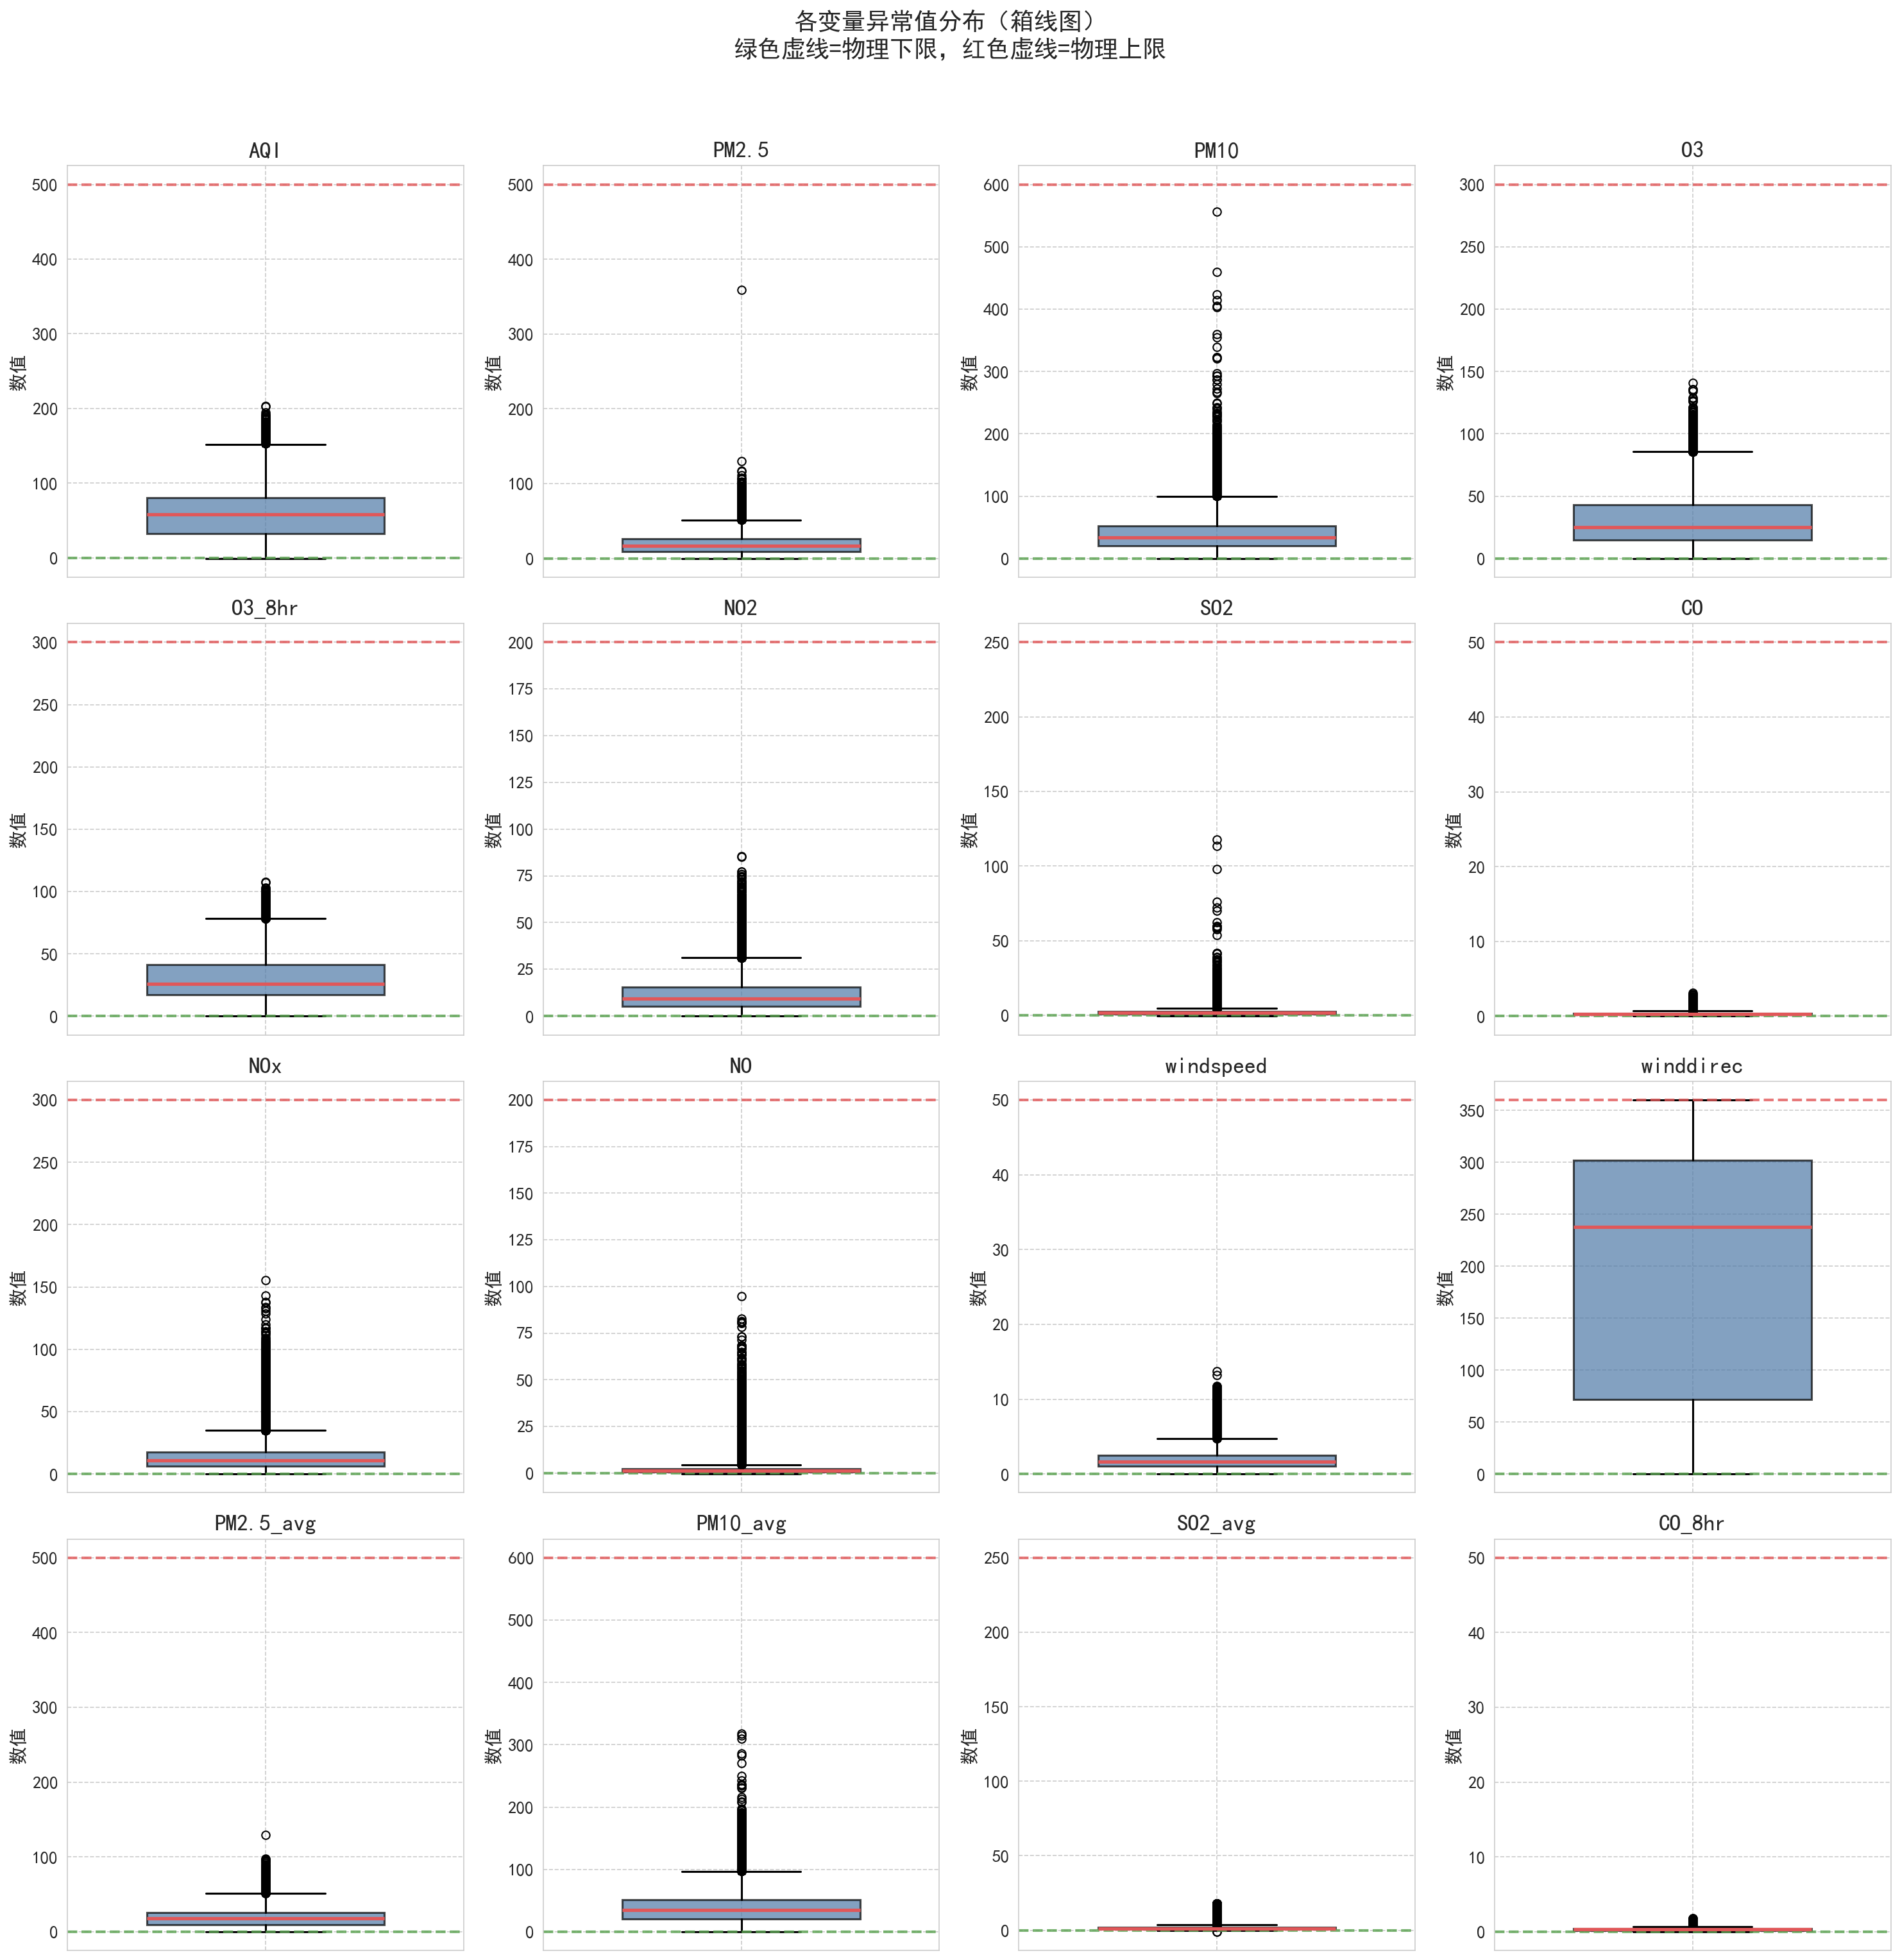

C:\Users\32052\AppData\Local\Temp\ipykernel_15728\3326699796.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(variables, rotation=45, ha='right', fontsize=14)


✅ 异常值柱形图已保存


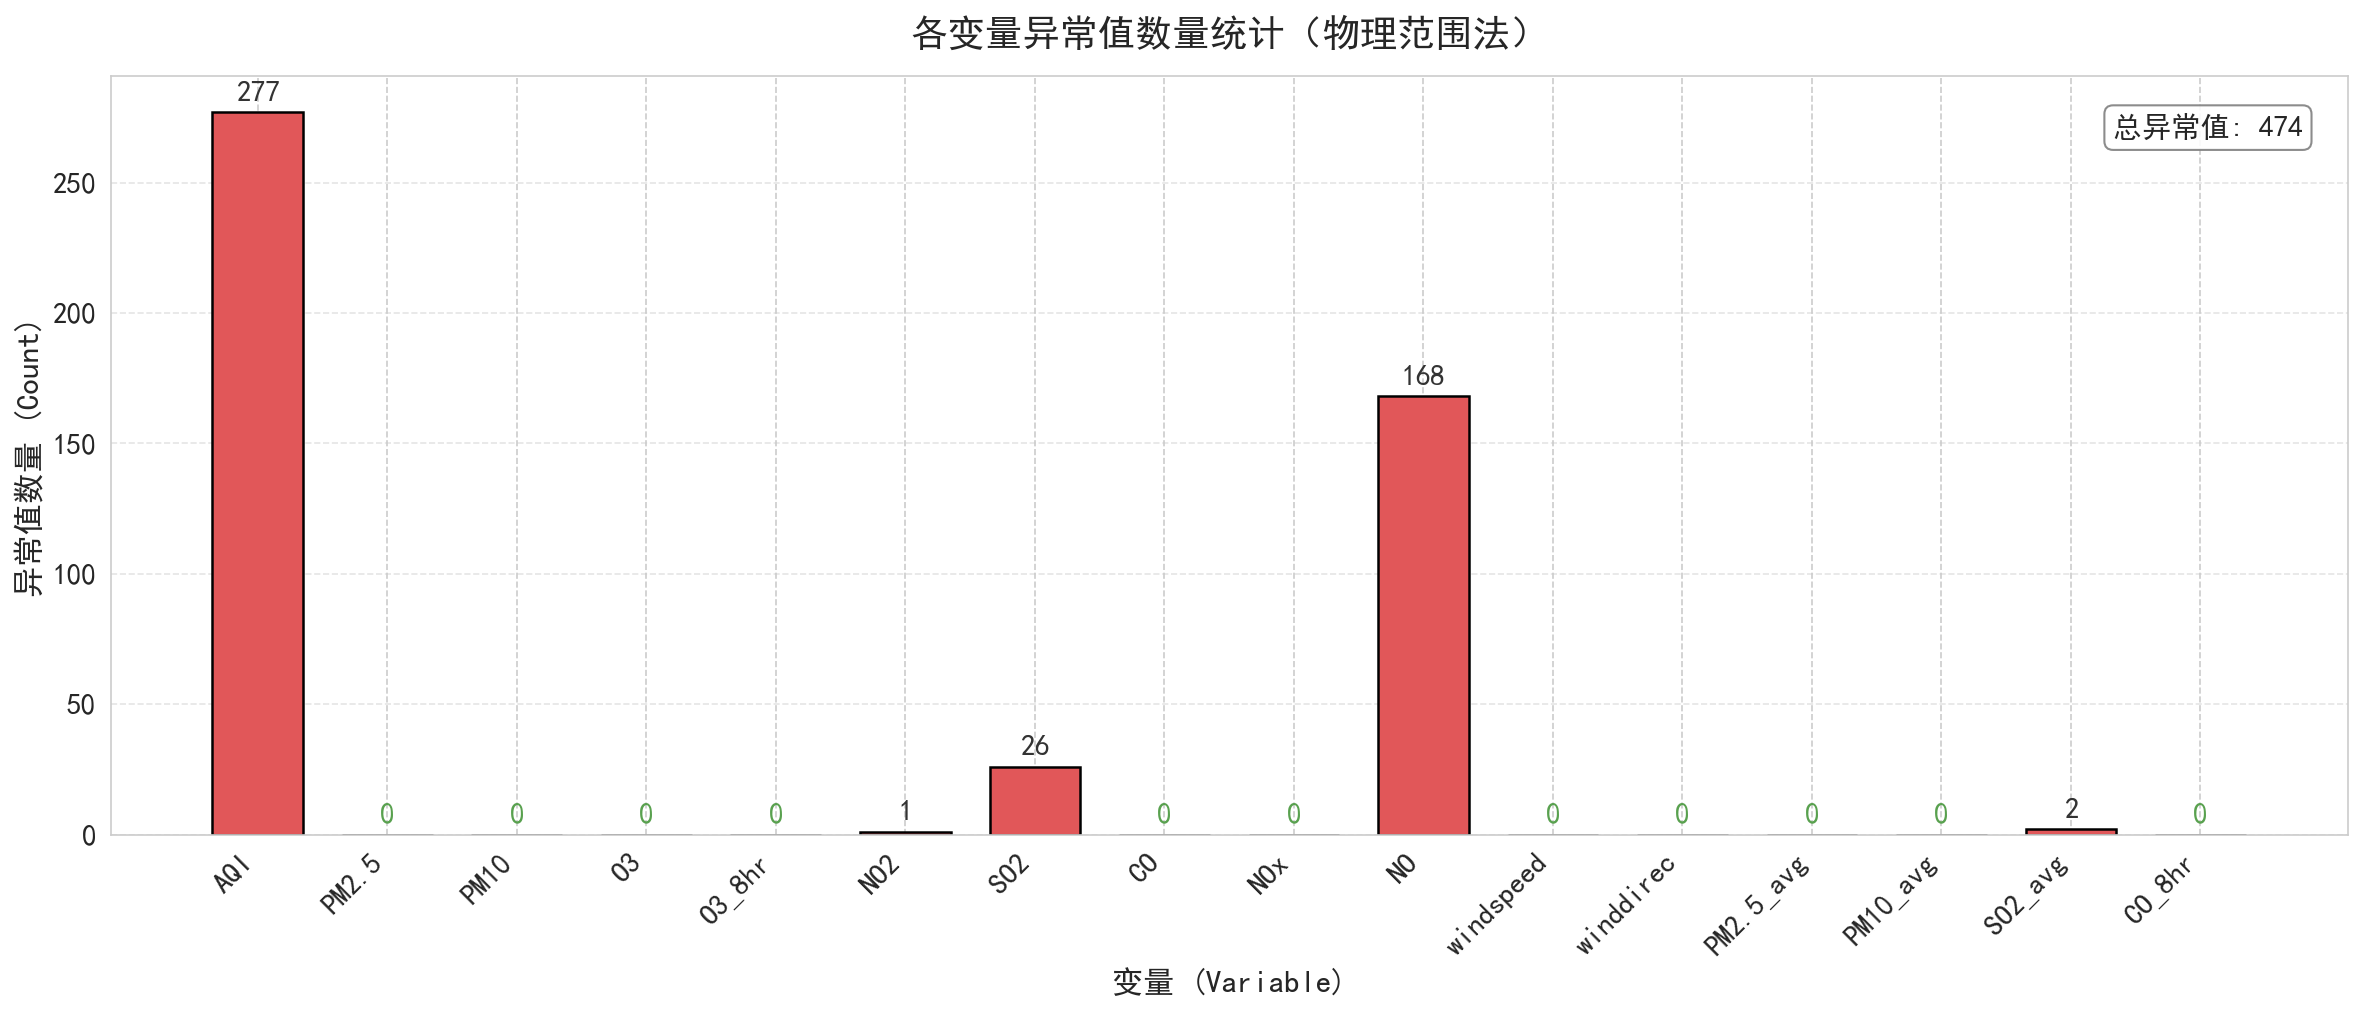


【将异常值替换为NaN】
  AQI: 已将 277 个异常值替换为NaN
  NO2: 已将 1 个异常值替换为NaN
  SO2: 已将 26 个异常值替换为NaN
  NO: 已将 168 个异常值替换为NaN
  SO2_avg: 已将 2 个异常值替换为NaN

替换后总NaN数量: 474

【使用分级填充策略处理异常值】
  正在处理站点: Meinong...
  正在处理站点: Zuoying...
  正在处理站点: Qianjin...
  正在处理站点: Xiaogang...
  正在处理站点: Linyuan...

【处理结果】
填充前NaN总数: 474
填充后NaN总数: 0
✅ 所有数值已完美补全

📁 清洗后数据已保存至: C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete2.csv

【最终统计报告】

变量           | 原始异常值        | 处理后范围                    
-------------------------------------------------------
AQI          | 277          | [    0.00,   203.00]
PM2.5        | 0            | [    0.00,   359.00]
PM10         | 0            | [    0.00,   556.00]
O3           | 0            | [    0.00,   140.80]
O3_8hr       | 0            | [    0.00,   108.00]
NO2          | 1            | [    0.00,    85.50]
SO2          | 26           | [    0.00,   117.80]
CO           | 0            | [    0.00,     3.10]
NOx          | 0            | [    0.00,   155.50]
NO           | 168  

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 风格设置（更大字体）
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.5})
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 15         # 基础字体大小
plt.rcParams['axes.titlesize'] = 16     # 标题字体
plt.rcParams['axes.labelsize'] = 15     # 轴标签字体
plt.rcParams['xtick.labelsize'] = 14    # x轴刻度字体
plt.rcParams['ytick.labelsize'] = 14    # y轴刻度字体

# ==========================================
# 2. 加载数据
# ==========================================
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete1.csv'
print(f"正在读取文件: {file_path}")
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

# 定义变量（修正列名错误）
pollutant_cols = ['AQI', 'PM2.5', 'PM10', 'O3', 'O3_8hr', 'NO2', 'SO2', 'CO', 'NOx', 'NO']
meteorological_cols = ['windspeed', 'winddirec']
avg_cols = ['PM2.5_avg', 'PM10_avg', 'SO2_avg', 'CO_8hr']  # 修正 '[PM10_avg' → 'PM10_avg'

all_numeric_cols = pollutant_cols + meteorological_cols + avg_cols
numeric_cols = [c for c in all_numeric_cols if c in df.columns]

print(f"分析的数值型变量 ({len(numeric_cols)}个): {numeric_cols}")

# ==========================================
# 3. 定义物理合理范围
# ==========================================
physical_bounds = {
    'AQI':       (0, 500),
    'PM2.5':     (0, 500),      # μg/m³
    'PM10':      (0, 600),      # μg/m³
    'O3':        (0, 300),      # ppb
    'O3_8hr':    (0, 300),      # ppb
    'NO2':       (0, 200),      # ppb
    'SO2':       (0, 250),      # ppb
    'CO':        (0, 50),       # ppm
    'NOx':       (0, 300),      # ppb
    'NO':        (0, 200),      # ppb
    'windspeed': (0, 50),       # m/s
    'winddirec': (0, 360),      # 度
    'PM2.5_avg': (0, 500),
    'PM10_avg':  (0, 600),
    'SO2_avg':   (0, 250),
    'CO_8hr':    (0, 50)
}

# ==========================================
# 4. 检测异常值（物理范围法）
# ==========================================
print("\n" + "="*70)
print("【异常值检测报告 - 物理范围法】")
print("="*70)

outlier_counts = {}
outlier_details = {}

for col in numeric_cols:
    series = df[col].dropna()
    
    if col in physical_bounds:
        lower, upper = physical_bounds[col]
        
        # 检测异常值
        mask_lower = series < lower
        mask_upper = series > upper
        
        n_lower = mask_lower.sum()
        n_upper = mask_upper.sum()
        n_total = n_lower + n_upper
        
        outlier_counts[col] = n_total
        outlier_details[col] = {
            'lower_bound': lower,
            'upper_bound': upper,
            'below_lower': n_lower,
            'above_upper': n_upper,
            'total': n_total,
            'min': series.min(),
            'max': series.max(),
            'mean': series.mean()
        }
        
        print(f"\n📊 【{col}】")
        print(f"   物理范围: [{lower}, {upper}]")
        print(f"   实际范围: [{series.min():.2f}, {series.max():.2f}]")
        print(f"   低于下限: {n_lower} 个, 高于上限: {n_upper} 个")
        print(f"   总异常值: {n_total} 个 ({n_total/len(series)*100:.3f}%)")
    else:
        outlier_counts[col] = 0
        print(f"\n📊 【{col}】: 未定义物理范围")

# ==========================================
# 5. 绘制箱线图（大字体版）
# ==========================================
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows), dpi=150)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    
    # 获取数据
    box_data = df[col].dropna()
    
    # 绘制箱线图
    bp = ax.boxplot(box_data, vert=True, patch_artist=True, widths=0.6)
    
    # 设置颜色
    bp['boxes'][0].set_facecolor('#4E79A7')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][0].set_edgecolor('black')
    bp['boxes'][0].set_linewidth(1.5)
    bp['medians'][0].set_color('#E15759')
    bp['medians'][0].set_linewidth(2.5)
    bp['whiskers'][0].set_linewidth(1.5)
    bp['whiskers'][1].set_linewidth(1.5)
    bp['caps'][0].set_linewidth(1.5)
    bp['caps'][1].set_linewidth(1.5)
    
    # 添加物理范围参考线
    if col in physical_bounds:
        phys_lower, phys_upper = physical_bounds[col]
        ax.axhline(y=phys_lower, color='#59A14F', linestyle='--', linewidth=2, alpha=0.8)
        ax.axhline(y=phys_upper, color='#E15759', linestyle='--', linewidth=2, alpha=0.8)
    
    # 标题（包含异常值数量）
    n_outliers = outlier_counts.get(col, 0)
    ax.set_ylabel('数值', fontsize=14, weight='bold')
    ax.set_title(col, fontsize=17, weight='bold')
    ax.tick_params(axis='both', labelsize=13)
    ax.set_xticklabels([])  # 隐藏x轴标签

# 隐藏多余的子图
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('各变量异常值分布（箱线图）\n绿色虚线=物理下限，红色虚线=物理上限', 
             fontsize=18, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:/Users/32052/Desktop/小组/outlier_boxplot.png', dpi=300, bbox_inches='tight')
print("\n✅ 箱线图已保存")
plt.show()

# ==========================================
# 6. 绘制异常值数量柱形图
# ==========================================
fig, ax = plt.subplots(figsize=(16, 7), dpi=150)

# 准备数据
variables = list(outlier_counts.keys())
counts = list(outlier_counts.values())

# 根据数量设置颜色（异常值越多颜色越深）
colors = ['#E15759' if c > 0 else '#59A14F' for c in counts]

# 绘制柱形图
bars = ax.bar(variables, counts, color=colors, edgecolor='black', linewidth=1.2, width=0.7)

# 添加数值标签
for bar, count in zip(bars, counts):
    height = bar.get_height()
    if height > 0:
        ax.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=14, weight='bold', color='#333333')
    else:
        ax.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
                '0',
                ha='center', va='bottom', fontsize=14, weight='bold', color='#59A14F')

ax.set_xlabel('变量 (Variable)', fontsize=15, weight='bold')
ax.set_ylabel('异常值数量 (Count)', fontsize=15, weight='bold')
ax.set_title('各变量异常值数量统计（物理范围法）', fontsize=18, weight='bold', pad=15)
ax.set_xticklabels(variables, rotation=45, ha='right', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# 添加总数标注
total_outliers = sum(counts)
ax.text(0.98, 0.95, f'总异常值: {total_outliers}',
        transform=ax.transAxes, fontsize=14, weight='bold',
        ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()
plt.savefig('C:/Users/32052/Desktop/小组/outlier_barplot.png', dpi=300, bbox_inches='tight')
print("✅ 异常值柱形图已保存")
plt.show()

# ==========================================
# 7. 将异常值替换为NaN
# ==========================================
print("\n" + "="*70)
print("【将异常值替换为NaN】")
print("="*70)

df_with_nan = df.copy()

for col in numeric_cols:
    if col in physical_bounds:
        lower, upper = physical_bounds[col]
        
        # 标记异常值
        mask_outlier = (df_with_nan[col] < lower) | (df_with_nan[col] > upper)
        n_replaced = mask_outlier.sum()
        
        # 替换为NaN
        df_with_nan.loc[mask_outlier, col] = np.nan
        
        if n_replaced > 0:
            print(f"  {col}: 已将 {n_replaced} 个异常值替换为NaN")

print(f"\n替换后总NaN数量: {df_with_nan[numeric_cols].isna().sum().sum()}")

# ==========================================
# 8. 核心函数：严格分级填充策略
# ==========================================
def advanced_imputation_strict(df, cols, limit=6):
    """
    策略：
    1. 计算连续缺失长度。
    2. 长度 <= 6: 线性插值。
    3. 长度 > 6: 线性插值不碰它，全部留给历史同期均值填充。
    """
    df_filled = df.copy()
    
    # 添加辅助时间列
    df_filled['month'] = df_filled['date'].dt.month
    df_filled['day'] = df_filled['date'].dt.day
    df_filled['hour'] = df_filled['date'].dt.hour
    
    for site in df_filled['sitename'].unique():
        print(f"  正在处理站点: {site}...")
        site_mask = (df_filled['sitename'] == site)
        
        for col in cols:
            # 获取该站点该列的数据
            series = df_filled.loc[site_mask, col]
            
            # -------------------------------------------------------
            # 第一步：智能线性插值
            # -------------------------------------------------------
            is_nan = series.isna()
            
            if not is_nan.any():
                continue
            
            # 计算每一段连续缺失的长度
            gap_groups = (is_nan != is_nan.shift()).cumsum()
            gap_sizes = series.groupby(gap_groups).transform('size')
            
            # 定义"短缺失"掩码 (是NaN 且 长度<=6)
            mask_short_gap = is_nan & (gap_sizes <= limit)
            
            # 仅对短缺失进行插值
            if mask_short_gap.any():
                interp_all = series.interpolate(method='linear', limit_direction='both')
                series_filled_step1 = series.copy()
                series_filled_step1[mask_short_gap] = interp_all[mask_short_gap]
                df_filled.loc[site_mask, col] = series_filled_step1
            
            # -------------------------------------------------------
            # 第二步：历史同期填充 (处理剩余的长缺失)
            # -------------------------------------------------------
            remaining_nans = df_filled.loc[site_mask, col].isna()
            
            if remaining_nans.sum() > 0:
                nan_indices = df_filled[site_mask & remaining_nans].index
                
                for idx in nan_indices:
                    row = df_filled.loc[idx]
                    m, d, h = row['month'], row['day'], row['hour']
                    
                    # 查找历史同期
                    history_values = df_filled.loc[
                        (df_filled['sitename'] == site) & 
                        (df_filled['month'] == m) & 
                        (df_filled['day'] == d) & 
                        (df_filled['hour'] == h) &
                        (df_filled[col].notna()),
                        col
                    ]
                    
                    if len(history_values) > 0:
                        df_filled.loc[idx, col] = history_values.mean()
                    else:
                        # 兜底策略：同月同小时均值
                        backup_values = df_filled.loc[
                            (df_filled['sitename'] == site) & 
                            (df_filled['month'] == m) & 
                            (df_filled['hour'] == h) &
                            (df_filled[col].notna()),
                            col
                        ]
                        if len(backup_values) > 0:
                            df_filled.loc[idx, col] = backup_values.mean()

    # 清理辅助列
    df_filled = df_filled.drop(columns=['month', 'day', 'hour'])
    return df_filled

# ==========================================
# 9. 执行填充
# ==========================================
print("\n" + "="*70)
print("【使用分级填充策略处理异常值】")
print("="*70)

df_final = advanced_imputation_strict(df_with_nan, numeric_cols, limit=6)

# ==========================================
# 10. 验证与保存
# ==========================================
nan_remaining = df_final[numeric_cols].isna().sum().sum()

print("\n" + "="*70)
print("【处理结果】")
print("="*70)
print(f"填充前NaN总数: {df_with_nan[numeric_cols].isna().sum().sum()}")
print(f"填充后NaN总数: {nan_remaining}")

if nan_remaining > 0:
    print("\n⚠️ 仍有少量NaN，执行最终兜底填充 (ffill/bfill)...")
    df_final[numeric_cols] = df_final.groupby('sitename')[numeric_cols].ffill().bfill()
    print("✅ 兜底填充完成")
else:
    print("✅ 所有数值已完美补全")

# 保存
output_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete2.csv'
df_final.to_csv(output_path, index=False)
print(f"\n📁 清洗后数据已保存至: {output_path}")

# ==========================================
# 11. 最终统计报告
# ==========================================
print("\n" + "="*70)
print("【最终统计报告】")
print("="*70)

print(f"\n{'变量':<12} | {'原始异常值':<12} | {'处理后范围':<25}")
print("-" * 55)

for col in numeric_cols:
    n_outliers = outlier_counts.get(col, 0)
    final_min = df_final[col].min()
    final_max = df_final[col].max()
    print(f"{col:<12} | {n_outliers:<12} | [{final_min:>8.2f}, {final_max:>8.2f}]")

print("\n" + "="*70)
print("✅ 异常值检测与处理全部完成！")
print("="*70)

In [29]:
import pandas as pd
import numpy as np

# ==========================================
# 1. 加载数据
# ==========================================
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete2.csv'
print(f"正在读取文件: {file_path}")
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

# 查看填充前的缺失情况
print("\n" + "="*60)
print("【填充前缺失情况】")
print("="*60)
print(f"status 缺失: {df['status'].isna().sum()}")
print(f"pollutant 缺失: {df['pollutant'].isna().sum()}")

# ==========================================
# 2. 根据AQI填充status列
# ==========================================
def get_status_from_aqi(aqi):
    """根据AQI值判定空气质量等级"""
    if pd.isna(aqi):
        return np.nan
    elif aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif aqi <= 200:
        return 'Unhealthy'
    else:  # AQI > 200
        return 'Very Unhealthy'

# 只填充status为空的行
mask_status_null = df['status'].isna()
df.loc[mask_status_null, 'status'] = df.loc[mask_status_null, 'AQI'].apply(get_status_from_aqi)

print("\n✅ status 列已根据AQI填充完成")

# ==========================================
# 3. 根据AQI填充pollutant列
# ==========================================
# 当AQI ≤ 50时，空气质量良好，无首要污染物，填充为"Zero Pollution"
mask_pollutant_null = df['pollutant'].isna()
mask_aqi_good = df['AQI'] <= 50

# 同时满足：pollutant为空 且 AQI ≤ 50
mask_fill_zero = mask_pollutant_null & mask_aqi_good
df.loc[mask_fill_zero, 'pollutant'] = 'Zero Pollution'

print(f"✅ pollutant 列已填充 'Zero Pollution': {mask_fill_zero.sum()} 条")

# ==========================================
# 4. 查看填充后的情况
# ==========================================
print("\n" + "="*60)
print("【填充后情况】")
print("="*60)
print(f"status 缺失: {df['status'].isna().sum()}")
print(f"pollutant 缺失: {df['pollutant'].isna().sum()}")

# 查看status分布
print("\n--- status 分布 ---")
print(df['status'].value_counts(dropna=False))

# 查看pollutant分布
print("\n--- pollutant 分布 ---")
print(df['pollutant'].value_counts(dropna=False))

# ==========================================
# 5. 验证填充结果
# ==========================================
print("\n" + "="*60)
print("【验证填充结果】")
print("="*60)

# 验证status填充是否正确
print("\n--- 各status对应的AQI范围 ---")
status_aqi_check = df.groupby('status')['AQI'].agg(['min', 'max', 'count'])
print(status_aqi_check)

# 验证Zero Pollution
zero_pollution = df[df['pollutant'] == 'Zero Pollution']
print(f"\n--- 'Zero Pollution' 的AQI范围 ---")
print(f"数量: {len(zero_pollution)}")
print(f"AQI范围: [{zero_pollution['AQI'].min():.1f}, {zero_pollution['AQI'].max():.1f}]")

# ==========================================
# 6. 保存文件
# ==========================================
output_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete3.csv'
df.to_csv(output_path, index=False)
print(f"\n📁 文件已保存至: {output_path}")

# ==========================================
# 7. 最终统计报告
# ==========================================
print("\n" + "="*60)
print("【最终数据统计报告】")
print("="*60)

print(f"\n总记录数: {len(df)}")
print(f"站点数: {df['sitename'].nunique()}")
print(f"时间范围: {df['date'].min()} ~ {df['date'].max()}")

print("\n--- 各列缺失情况 ---")
missing_summary = df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
if len(missing_summary) > 0:
    print(missing_summary)
else:
    print("✅ 所有列均无缺失值")

print("\n" + "="*60)
print("✅ 数据处理完成！")
print("="*60)

正在读取文件: C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete2.csv

【填充前缺失情况】
status 缺失: 2427
pollutant 缺失: 88328

✅ status 列已根据AQI填充完成
✅ pollutant 列已填充 'Zero Pollution': 87065 条

【填充后情况】
status 缺失: 0
pollutant 缺失: 1263

--- status 分布 ---
status
Moderate                          96394
Good                              87066
Unhealthy for Sensitive Groups    19597
Unhealthy                          1541
Very Unhealthy                        2
Name: count, dtype: int64

--- pollutant 分布 ---
pollutant
PM2.5                     100590
Zero Pollution             87065
Ozone (8hr)                13536
PM10                        1769
NaN                         1263
Nitrogen Dioxide (NO2)       295
Sulfur Dioxide (SO2)          78
Ozone                          4
Name: count, dtype: int64

【验证填充结果】

--- 各status对应的AQI范围 ---
                                       min         max  count
status                                                       
Good                              0.000000  

In [31]:
import pandas as pd
import numpy as np

# ==========================================
# 1. 加载数据
# ==========================================
file_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete3.csv'
print(f"正在读取文件: {file_path}")
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])

# 查看缺失情况
print("\n" + "="*60)
print("【填充前缺失情况】")
print("="*60)
print(f"pollutant 缺失: {df['pollutant'].isna().sum()}")

# ==========================================
# 2. 定义IAQI计算函数（基于台湾/美国EPA标准）
# ==========================================
# IAQI分界点表（污染物浓度 → IAQI）
# 格式：[(浓度下限, 浓度上限, IAQI下限, IAQI上限), ...]

IAQI_BREAKPOINTS = {
    'PM2.5': [  # μg/m³, 24小时平均
        (0, 15.4, 0, 50),
        (15.5, 35.4, 51, 100),
        (35.5, 54.4, 101, 150),
        (54.5, 150.4, 151, 200),
        (150.5, 250.4, 201, 300),
        (250.5, 500.4, 301, 500)
    ],
    'PM10': [  # μg/m³, 24小时平均
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 254, 101, 150),
        (255, 354, 151, 200),
        (355, 424, 201, 300),
        (425, 604, 301, 500)
    ],
    'O3_8hr': [  # ppb, 8小时平均
        (0, 54, 0, 50),
        (55, 70, 51, 100),
        (71, 85, 101, 150),
        (86, 105, 151, 200),
        (106, 200, 201, 300)
    ],
    'O3': [  # ppb, 小时值
        (0, 125, 0, 50),
        (126, 164, 101, 150),
        (165, 204, 151, 200),
        (205, 404, 201, 300),
        (405, 604, 301, 500)
    ],
    'NO2': [  # ppb, 小时值
        (0, 53, 0, 50),
        (54, 100, 51, 100),
        (101, 360, 101, 150),
        (361, 649, 151, 200),
        (650, 1249, 201, 300),
        (1250, 2049, 301, 500)
    ],
    'SO2': [  # ppb, 小时值
        (0, 35, 0, 50),
        (36, 75, 51, 100),
        (76, 185, 101, 150),
        (186, 304, 151, 200),
        (305, 604, 201, 300),
        (605, 1004, 301, 500)
    ]
}

def calculate_iaqi(concentration, breakpoints):
    """
    根据浓度计算IAQI
    """
    if pd.isna(concentration) or concentration < 0:
        return 0
    
    for (c_low, c_high, i_low, i_high) in breakpoints:
        if c_low <= concentration <= c_high:
            # 线性插值计算IAQI
            iaqi = (i_high - i_low) / (c_high - c_low) * (concentration - c_low) + i_low
            return iaqi
    
    # 超出最大范围，返回最大IAQI
    if concentration > breakpoints[-1][1]:
        return 500
    
    return 0

def determine_primary_pollutant(row):
    """
    根据各污染物的IAQI确定首要污染物
    """
    # 定义污染物列名与输出名称的映射
    pollutant_mapping = {
        'PM2.5': 'PM2.5',
        'PM10': 'PM10',
        'O3_8hr': 'Ozone (8hr)',
        'O3': 'Ozone',
        'NO2': 'Nitrogen Dioxide (NO2)',
        'SO2': 'Sulfur Dioxide (SO2)'
    }
    
    # 计算各污染物的IAQI
    iaqi_values = {}
    
    for col, output_name in pollutant_mapping.items():
        if col in row.index and col in IAQI_BREAKPOINTS:
            concentration = row[col]
            iaqi = calculate_iaqi(concentration, IAQI_BREAKPOINTS[col])
            iaqi_values[output_name] = iaqi
    
    # 找出IAQI最大的污染物
    if iaqi_values:
        max_pollutant = max(iaqi_values, key=iaqi_values.get)
        max_iaqi = iaqi_values[max_pollutant]
        
        # 如果最大IAQI很小（比如<10），可能是无污染
        if max_iaqi < 10:
            return 'Zero Pollution'
        
        return max_pollutant
    
    return np.nan

# ==========================================
# 3. 填充缺失的pollutant
# ==========================================
print("\n正在计算首要污染物...")

# 筛选pollutant为空的行
mask_pollutant_null = df['pollutant'].isna()
null_count = mask_pollutant_null.sum()
print(f"需要填充的记录数: {null_count}")

# 对每行计算首要污染物
df.loc[mask_pollutant_null, 'pollutant'] = df.loc[mask_pollutant_null].apply(
    determine_primary_pollutant, axis=1
)

print("✅ pollutant 列填充完成")

# ==========================================
# 4. 验证填充结果
# ==========================================
print("\n" + "="*60)
print("【填充后情况】")
print("="*60)
print(f"pollutant 缺失: {df['pollutant'].isna().sum()}")

print("\n--- pollutant 分布 ---")
print(df['pollutant'].value_counts(dropna=False))

# 查看新填充的首要污染物分布
print("\n--- 本次新填充的首要污染物分布 ---")
filled_pollutants = df.loc[mask_pollutant_null, 'pollutant'].value_counts()
print(filled_pollutants)

# ==========================================
# 5. 详细验证：查看填充结果与各污染物浓度的对应关系
# ==========================================
print("\n" + "="*60)
print("【填充验证：各首要污染物对应的浓度统计】")
print("="*60)

filled_df = df.loc[mask_pollutant_null].copy()

for pol in filled_df['pollutant'].unique():
    if pd.isna(pol):
        continue
    
    subset = filled_df[filled_df['pollutant'] == pol]
    print(f"\n📊 【首要污染物 = {pol}】(共 {len(subset)} 条)")
    
    # 显示各污染物的浓度统计
    cols_to_show = ['PM2.5', 'PM10', 'O3', 'O3_8hr', 'NO2', 'SO2', 'AQI']
    cols_to_show = [c for c in cols_to_show if c in df.columns]
    
    for col in cols_to_show:
        if col in subset.columns:
            mean_val = subset[col].mean()
            min_val = subset[col].min()
            max_val = subset[col].max()
            print(f"   {col:<10}: 均值={mean_val:>7.2f}, 范围=[{min_val:>6.2f}, {max_val:>6.2f}]")

# ==========================================
# 6. 保存文件
# ==========================================
output_path = 'C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv'
df.to_csv(output_path, index=False)
print(f"\n📁 文件已保存至: {output_path}")

# ==========================================
# 7. 最终统计报告
# ==========================================
print("\n" + "="*60)
print("【最终数据统计报告】")
print("="*60)

print(f"\n总记录数: {len(df)}")

print("\n--- pollutant 最终分布 ---")
print(df['pollutant'].value_counts(dropna=False))

print("\n--- status 最终分布 ---")
print(df['status'].value_counts(dropna=False))

# 检查是否还有缺失
missing_summary = df[['pollutant', 'status']].isnull().sum()
if missing_summary.sum() == 0:
    print("\n✅ pollutant 和 status 列均无缺失值！")
else:
    print("\n⚠️ 仍有缺失：")
    print(missing_summary[missing_summary > 0])

print("\n" + "="*60)
print("✅ 数据处理完成！")
print("="*60)

正在读取文件: C:/Users/32052/Desktop/小组/kaohsiung_5sites_time_complete3.csv

【填充前缺失情况】
pollutant 缺失: 1263

正在计算首要污染物...
需要填充的记录数: 1263
✅ pollutant 列填充完成

【填充后情况】
pollutant 缺失: 0

--- pollutant 分布 ---
pollutant
PM2.5                     101735
Zero Pollution             87065
Ozone (8hr)                13633
PM10                        1790
Nitrogen Dioxide (NO2)       295
Sulfur Dioxide (SO2)          78
Ozone                          4
Name: count, dtype: int64

--- 本次新填充的首要污染物分布 ---
pollutant
PM2.5          1145
Ozone (8hr)      97
PM10             21
Name: count, dtype: int64

【填充验证：各首要污染物对应的浓度统计】

📊 【首要污染物 = PM2.5】(共 1145 条)
   PM2.5     : 均值=  27.72, 范围=[ 11.00,  59.00]
   PM10      : 均值=  52.70, 范围=[ 18.75,  95.00]
   O3        : 均值=  32.73, 范围=[  1.85,  91.54]
   O3_8hr    : 均值=  32.76, 范围=[  1.33,  70.65]
   NO2       : 均值=  15.08, 范围=[  3.30,  34.90]
   SO2       : 均值=   2.17, 范围=[  0.20,   9.50]
   AQI       : 均值=  80.32, 范围=[ 50.33, 158.00]

📊 【首要污染物 = Ozone (8hr)】(共 97 条)
   PM2.

***建模“宽表”***

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# 0. 预处理：数据筛选与索引设置
# ---------------------------------------------------------
data=pd.read_csv('你的文件路径.csv')
# 确保时间格式正确并排序
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['sitename', 'date'])

# 选定目标站点和邻居站点
target_site = 'Xiaogang'
neighbor_sites = ['Linyuan', 'Qianjin', 'Zuoying', 'Meinong']

# 分离出小港站的数据（主表）
df_target = data[data['sitename'] == target_site].copy()
df_target = df_target.set_index('date')

# 分离出邻居站点的数据
df_neighbors = data[data['sitename'].isin(neighbor_sites)].copy()

# ---------------------------------------------------------
# 1. 通用特征工程 (Base Feature Engineering)
# ---------------------------------------------------------

# --- A. 邻居协同特征 (Neighbor Co-features) ---
# 计算所有邻居在同一时刻的平均值（精简策略）
# 我们只关心邻居的 PM2.5, AQI 和 风向 是否有输入
neighbor_cols = ['PM2.5', 'AQI', 'winddirec', 'windspeed']

# 按时间聚合计算邻居均值
df_neighbor_mean = df_neighbors.groupby('date')[neighbor_cols].mean()
df_neighbor_mean.columns = [f'Neighbor_Mean_{col}' for col in df_neighbor_mean.columns]

# 将邻居特征合并到主表
df_base = df_target.join(df_neighbor_mean, how='left')

# 填补合并可能产生的微量缺失值（邻居某时刻没数据的情况）
df_base = df_base.fillna(method='ffill').fillna(method='bfill')

# --- B. 时间编码 (Time Encoding) ---
# 从索引提取时间属性
df_base['hour'] = df_base.index.hour
df_base['month'] = df_base.index.month
df_base['dayofweek'] = df_base.index.dayofweek

# 周期性编码
df_base['hour_sin'] = np.sin(2 * np.pi * df_base['hour'] / 24)
df_base['hour_cos'] = np.cos(2 * np.pi * df_base['hour'] / 24)
df_base['month_sin'] = np.sin(2 * np.pi * df_base['month'] / 12)
df_base['month_cos'] = np.cos(2 * np.pi * df_base['month'] / 12)
df_base['day_sin'] = np.sin(2 * np.pi * df_base['dayofweek'] / 7)
df_base['day_cos'] = np.cos(2 * np.pi * df_base['dayofweek'] / 7)

# --- C. 风向向量化 (Wind Vectorization) ---
# 处理本站风向
df_base['wind_rad'] = np.deg2rad(df_base['winddirec'])
df_base['Wind_X'] = df_base['windspeed'] * np.cos(df_base['wind_rad'])
df_base['Wind_Y'] = df_base['windspeed'] * np.sin(df_base['wind_rad'])

# 处理邻居平均风向 (假设 Neighbor_Mean_winddirec 存在)
if 'Neighbor_Mean_winddirec' in df_base.columns:
    df_base['neigh_wind_rad'] = np.deg2rad(df_base['Neighbor_Mean_winddirec'])
    df_base['Neighbor_Wind_X'] = df_base['Neighbor_Mean_windspeed'] * np.cos(df_base['neigh_wind_rad'])
    df_base['Neighbor_Wind_Y'] = df_base['Neighbor_Mean_windspeed'] * np.sin(df_base['neigh_wind_rad'])

# --- D. 清理多余列 ---
# 定义最终的基础特征列表 (不含AQI目标，也不含原始时间列)
# 注意：我们要预测未来的AQI，但当前的AQI可以作为特征
features_to_keep = [
    'PM2.5', 'PM10', 'O3', 'SO2', 'NOx', 'CO', 'AQI', # 本站原始指标
    'Wind_X', 'Wind_Y',                               # 本站风
    'Neighbor_Mean_PM2.5', 'Neighbor_Mean_AQI',       # 邻居指标
    'Neighbor_Wind_X', 'Neighbor_Wind_Y',             # 邻居风
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos' # 时间
]

# 过滤列，确保只保留存在的列
final_cols = [c for c in features_to_keep if c in df_base.columns]
df_processed = df_base[final_cols].copy()

# ---------------------------------------------------------
# 2. 标准化处理 (Normalization)
# ---------------------------------------------------------
# 注意：在实际项目中，Scaler 应该只fit在训练集上，transform到测试集
# 这里为了代码简洁，演示全量归一化 (MinMax 0-1)
scaler = MinMaxScaler()
# 将所有特征归一化
df_scaled = pd.DataFrame(scaler.fit_transform(df_processed), 
                         columns=df_processed.columns, 
                         index=df_processed.index)

print(f"基础数据处理完毕，形状: {df_scaled.shape}")
# 此时 df_scaled 是每个时刻 t 的纯净数据，没有滞后
# ---------------------------------------------------------
# 3. Tree-Based 模型数据准备 (RF / LightGBM)
# ---------------------------------------------------------
df_tree = df_scaled.copy()

# 需要做滞后的特征（通常是污染物和风，时间编码不需要滞后）
cols_to_lag = ['PM2.5', 'AQI', 'O3', 'Wind_X', 'Wind_Y', 'Neighbor_Mean_PM2.5']
# 确保列存在
cols_to_lag = [c for c in cols_to_lag if c in df_tree.columns]

# 指定滞后阶数：t-1, t-6, t-24
lags = [1, 6, 24]

# 生成滞后列
for col in cols_to_lag:
    for lag in lags:
        df_tree[f'{col}_lag_{lag}'] = df_tree[col].shift(lag)

# --- 构建标签 (Label) ---
# 我们要预测的是 t+1 时刻的 AQI
# 所以 Label 是当前 AQI 往上移动一行 (shift -1)
df_tree['Target_AQI'] = df_tree['AQI'].shift(-1)

# --- 清洗 ---
# 因为 shift 产生了空值，必须删除
df_tree = df_tree.dropna()

# 分离 X 和 y
X_tree = df_tree.drop(columns=['Target_AQI'])
y_tree = df_tree['Target_AQI']

print(f"RF/LGBM 输入形状: X={X_tree.shape}, y={y_tree.shape}")
print(f"RF/LGBM 特征列数: {X_tree.shape[1]}")
# 这里你可以直接调用: model.fit(X_tree, y_tree)

***3D张量***

📦 数据集划分: 训练集 torch.Size([32621, 72, 19]), 测试集 torch.Size([8156, 72, 19])

🏋️ 开始训练 Transformer 模型...
Epoch 5/15 | Loss: 0.010986
Epoch 10/15 | Loss: 0.006236
Epoch 15/15 | Loss: 0.004194

🔮 正在预测并还原数据...
反归一化后 - 预测范围: 13.6 ~ 139.0
反归一化后 - 真实范围: 8.0 ~ 155.0

📊 ========== 最终评价指标 ==========
RMSE (均方根误差): 20.9789
MAE  (平均绝对误差): 16.0471
R²   (决定系数)  : 0.4209


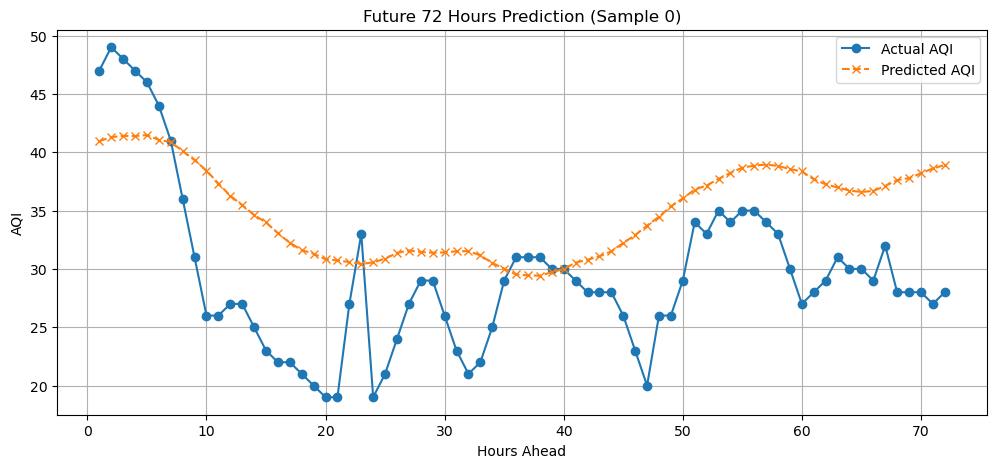

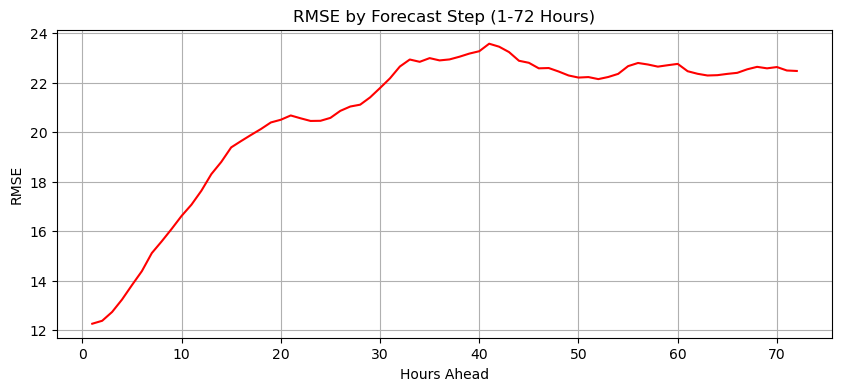

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import math

# 超参数配置
INPUT_WINDOW = 72    # 输入窗口：过去72小时
OUTPUT_WINDOW = 72   # 预测窗口：未来72小时
BATCH_SIZE = 32
EPOCHS = 15          # 训练轮数
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ---------------------------------------------------------
# 0. 预处理：数据筛选与索引设置
# ---------------------------------------------------------
# 确保时间格式正确并排序
data=pd.read_csv('C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv')
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['sitename', 'date'])

# 选定目标站点和邻居站点
target_site = 'Xiaogang'
neighbor_sites = ['Linyuan', 'Qianjin', 'Zuoying', 'Meinong']

# 分离出小港站的数据（主表）
df_target = data[data['sitename'] == target_site].copy()
df_target = df_target.set_index('date')

# 分离出邻居站点的数据
df_neighbors = data[data['sitename'].isin(neighbor_sites)].copy()

# ---------------------------------------------------------
# 1. 通用特征工程 (Base Feature Engineering)
# ---------------------------------------------------------

# --- A. 邻居协同特征 (Neighbor Co-features) ---
# 计算所有邻居在同一时刻的平均值（精简策略）
# 我们只关心邻居的 PM2.5, AQI 和 风向 是否有输入
neighbor_cols = ['PM2.5', 'AQI', 'winddirec', 'windspeed']

# 按时间聚合计算邻居均值
df_neighbor_mean = df_neighbors.groupby('date')[neighbor_cols].mean()
df_neighbor_mean.columns = [f'Neighbor_Mean_{col}' for col in df_neighbor_mean.columns]

# 将邻居特征合并到主表
df_base = df_target.join(df_neighbor_mean, how='left')

# 填补合并可能产生的微量缺失值（邻居某时刻没数据的情况）
df_base = df_base.ffill().bfill()

# --- B. 时间编码 (Time Encoding) ---
# 从索引提取时间属性
df_base['hour'] = df_base.index.hour
df_base['month'] = df_base.index.month
df_base['dayofweek'] = df_base.index.dayofweek

# 周期性编码
df_base['hour_sin'] = np.sin(2 * np.pi * df_base['hour'] / 24)
df_base['hour_cos'] = np.cos(2 * np.pi * df_base['hour'] / 24)
df_base['month_sin'] = np.sin(2 * np.pi * df_base['month'] / 12)
df_base['month_cos'] = np.cos(2 * np.pi * df_base['month'] / 12)
df_base['day_sin'] = np.sin(2 * np.pi * df_base['dayofweek'] / 7)
df_base['day_cos'] = np.cos(2 * np.pi * df_base['dayofweek'] / 7)

# --- C. 风向向量化 (Wind Vectorization) ---
# 处理本站风向
df_base['wind_rad'] = np.deg2rad(df_base['winddirec'])
df_base['Wind_X'] = df_base['windspeed'] * np.cos(df_base['wind_rad'])
df_base['Wind_Y'] = df_base['windspeed'] * np.sin(df_base['wind_rad'])

# 处理邻居平均风向 (假设 Neighbor_Mean_winddirec 存在)
if 'Neighbor_Mean_winddirec' in df_base.columns:
    df_base['neigh_wind_rad'] = np.deg2rad(df_base['Neighbor_Mean_winddirec'])
    df_base['Neighbor_Wind_X'] = df_base['Neighbor_Mean_windspeed'] * np.cos(df_base['neigh_wind_rad'])
    df_base['Neighbor_Wind_Y'] = df_base['Neighbor_Mean_windspeed'] * np.sin(df_base['neigh_wind_rad'])

# --- D. 清理多余列 ---
# 定义最终的基础特征列表 (不含AQI目标，也不含原始时间列)
# 注意：我们要预测未来的AQI，但当前的AQI可以作为特征
features_to_keep = [
    'PM2.5', 'PM10', 'O3', 'SO2', 'NOx', 'CO', 'AQI', # 本站原始指标
    'Wind_X', 'Wind_Y',                               # 本站风
    'Neighbor_Mean_PM2.5', 'Neighbor_Mean_AQI',       # 邻居指标
    'Neighbor_Wind_X', 'Neighbor_Wind_Y',             # 邻居风
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos' # 时间
]

# 过滤列，确保只保留存在的列
final_cols = [c for c in features_to_keep if c in df_base.columns]
df_processed = df_base[final_cols].copy()

# ==========================================
# 2. 数据标准化与序列构建
# ==========================================
scaler = MinMaxScaler()
# fit_transform 返回 numpy array
data_scaled = scaler.fit_transform(df_processed)

def create_multistep_sequences(data_array, target_col_idx, input_len, output_len):
    X, y = [], []
    total_len = len(data_array)
    for i in range(total_len - input_len - output_len + 1):
        X.append(data_array[i : i + input_len]) # 过去72h的所有特征
        y.append(data_array[i + input_len : i + input_len + output_len, target_col_idx]) # 未来72h的AQI
    return np.array(X), np.array(y)

# 找到 AQI 在矩阵中的列索引
aqi_col_idx = df_processed.columns.get_loc('AQI')

# 生成序列
X_all, y_all = create_multistep_sequences(data_scaled, aqi_col_idx, INPUT_WINDOW, OUTPUT_WINDOW)

# 转为 Tensor
X_tensor = torch.FloatTensor(X_all)
y_tensor = torch.FloatTensor(y_all)

# 划分训练/测试集 (80% / 20%)
train_size = int(len(X_tensor) * 0.8)
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"📦 数据集划分: 训练集 {X_train.shape}, 测试集 {X_test.shape}")

# ==========================================
# 3. Transformer 模型定义
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]

class AQITransformer(nn.Module):
    def __init__(self, input_dim, output_len, d_model=64, nhead=4, num_layers=2):
        super(AQITransformer, self).__init__()
        self.input_embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 解码层：把 Encoder 的输出展平，映射到未来72个点
        self.decoder = nn.Sequential(
            nn.Linear(d_model * INPUT_WINDOW, 128),
            nn.ReLU(),
            nn.Linear(128, output_len) 
        )

    def forward(self, x):
        # x: [batch, seq_len, features]
        x = self.input_embedding(x)
        x = x.permute(1, 0, 2) # [seq, batch, d_model] for PE
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2) # [batch, seq, d_model] for Transformer
        
        x = self.transformer_encoder(x)
        x = x.reshape(x.size(0), -1) # Flatten
        output = self.decoder(x)
        return output

# 初始化模型
input_features = X_train.shape[2]
model = AQITransformer(input_dim=input_features, output_len=OUTPUT_WINDOW).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ==========================================
# 4. 模型训练
# ==========================================
print("\n🏋️ 开始训练 Transformer 模型...")
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    avg_loss = train_loss / len(train_loader)
    loss_history.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

# ==========================================
# 5. 预测与反归一化 (核心步骤)
# ==========================================
print("\n🔮 正在预测并还原数据...")
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch)
        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

# 拼接所有批次 (形状: [测试集样本数, 72])
y_pred_scaled = np.concatenate(predictions, axis=0)
y_true_scaled = np.concatenate(actuals, axis=0)

def inverse_transform_aqi(scaled_data, scaler, col_idx, n_features):
    """
    反归一化辅助函数：
    scaled_data: (N, 72)
    scaler: 原始的 MinMaxScaler (训练时 fit 了 n_features 列)
    col_idx: AQI 所在的列索引
    """
    N, T = scaled_data.shape
    flat_data = scaled_data.flatten() # 展平成 1D
    
    # 构建假矩阵 (行数 = N*T, 列数 = n_features)
    dummy = np.zeros((len(flat_data), n_features))
    dummy[:, col_idx] = flat_data # 填入 AQI 列
    
    # 反归一化
    inversed = scaler.inverse_transform(dummy)
    
    # 取出 AQI 列并恢复形状 (N, 72)
    return inversed[:, col_idx].reshape(N, T)

# 执行反归一化
n_feats = df_processed.shape[1]
y_pred_real = inverse_transform_aqi(y_pred_scaled, scaler, aqi_col_idx, n_feats)
y_true_real = inverse_transform_aqi(y_true_scaled, scaler, aqi_col_idx, n_feats)

print(f"反归一化后 - 预测范围: {y_pred_real.min():.1f} ~ {y_pred_real.max():.1f}")
print(f"反归一化后 - 真实范围: {y_true_real.min():.1f} ~ {y_true_real.max():.1f}")

# ==========================================
# 6. 回归评价 (RMSE, MAE, R2)
# ==========================================
# 计算全局指标 (所有样本的所有未来时刻)
mse = mean_squared_error(y_true_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_real, y_pred_real)
r2 = r2_score(y_true_real.flatten(), y_pred_real.flatten())

print("\n📊 ========== 最终评价指标 ==========")
print(f"RMSE (均方根误差): {rmse:.4f}")
print(f"MAE  (平均绝对误差): {mae:.4f}")
print(f"R²   (决定系数)  : {r2:.4f}")
print("===================================")

# ==========================================
# 7. 可视化
# ==========================================
# 图1: 展示某一个样本的未来72小时预测对比
sample_id = 0 # 取测试集第一个样本
if len(y_true_real) > 0:
    plt.figure(figsize=(12, 5))
    steps = range(1, OUTPUT_WINDOW + 1)
    plt.plot(steps, y_true_real[sample_id], label='Actual AQI', marker='o')
    plt.plot(steps, y_pred_real[sample_id], label='Predicted AQI', marker='x', linestyle='--')
    plt.title(f'Future 72 Hours Prediction (Sample {sample_id})')
    plt.xlabel('Hours Ahead')
    plt.ylabel('AQI')
    plt.legend()
    plt.grid(True)
    plt.show()

# 图2: 分时段 RMSE (查看模型随预测步长增加的误差变化)
step_rmse = np.sqrt(np.mean((y_true_real - y_pred_real) ** 2, axis=0))
plt.figure(figsize=(10, 4))
plt.plot(range(1, OUTPUT_WINDOW + 1), step_rmse, color='red')
plt.title('RMSE by Forecast Step (1-72 Hours)')
plt.xlabel('Hours Ahead')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

***24小时对美浓、小港、林园、前金、左营的回归***

📁 Loading data...

📊 Site AQI Distribution Statistics


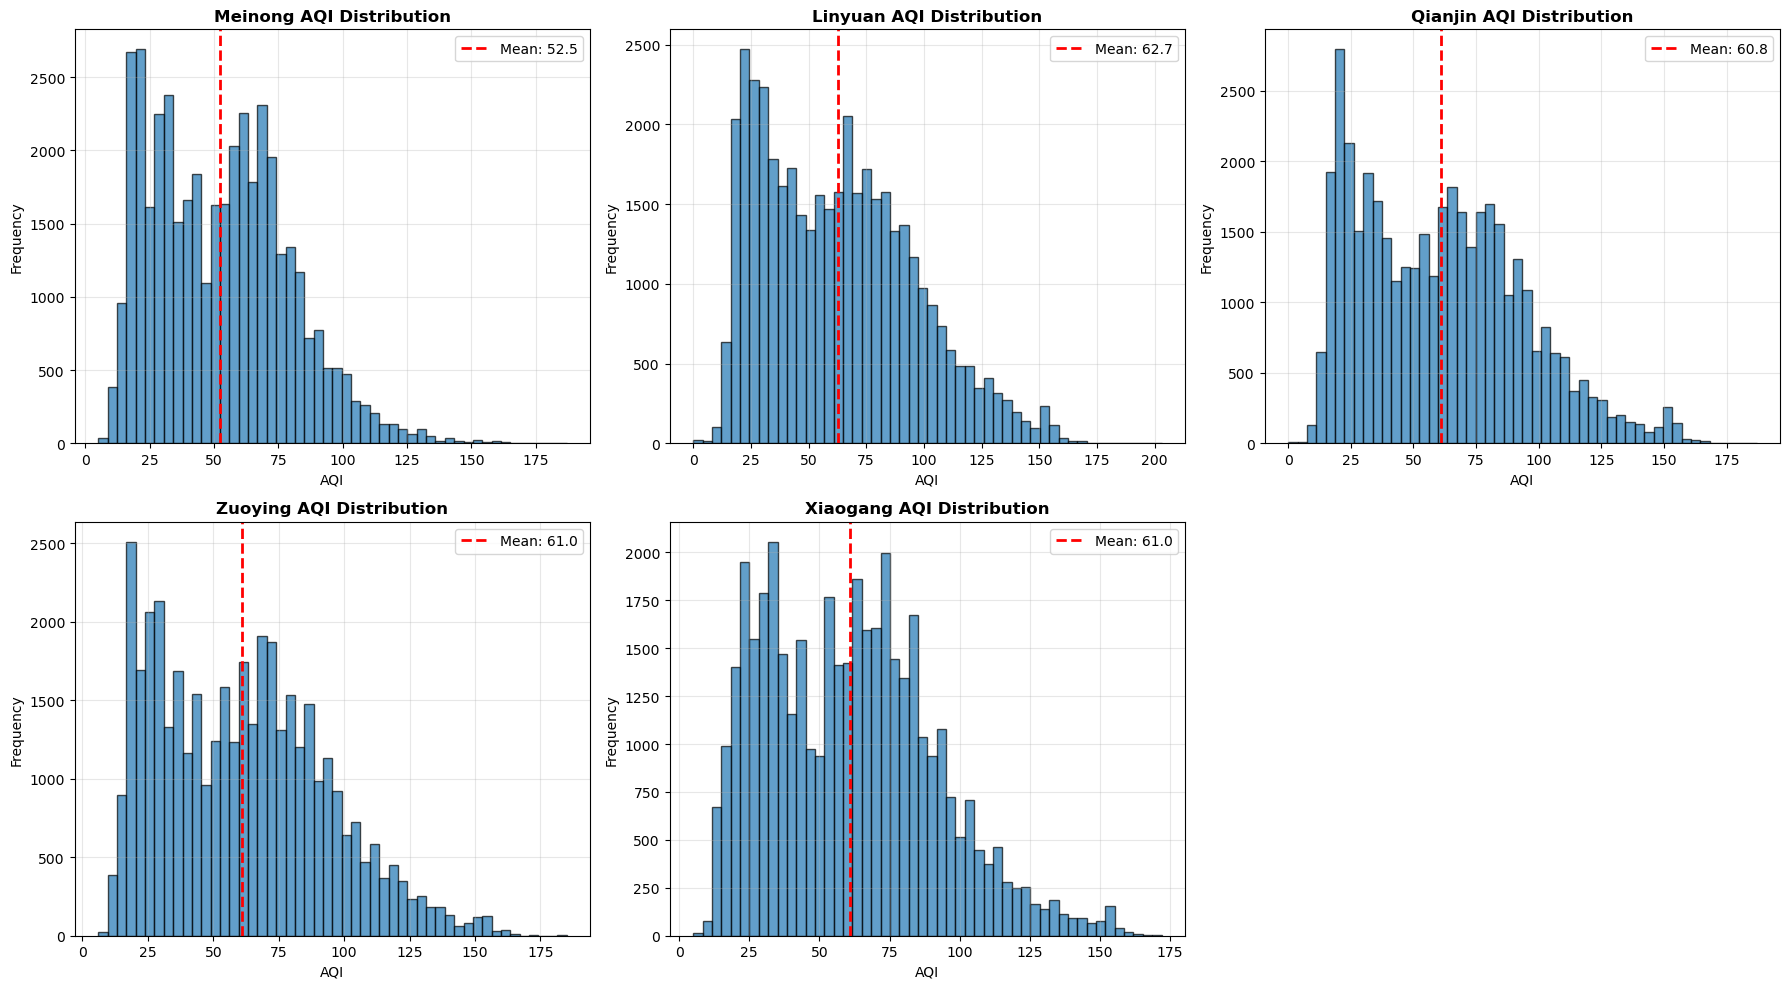

    Site      Mean       Std  Median  Min   Max  Count
 Meinong 52.501851 26.417342    52.0  5.0 187.0  40920
 Linyuan 62.685435 33.014967    60.0  0.0 203.0  40920
 Qianjin 60.838486 32.805285    59.0  0.0 187.0  40920
 Zuoying 60.955309 31.968607    60.0  6.0 185.0  40920
Xiaogang 61.042976 30.158300    60.0  5.0 172.0  40920

📌 Coefficient of Variation (CV = std/mean):
   Meinong: 0.503
   Linyuan: 0.527
   Qianjin: 0.539
   Zuoying: 0.524
   Xiaogang: 0.494

🔗 Inter-site AQI Correlation Analysis


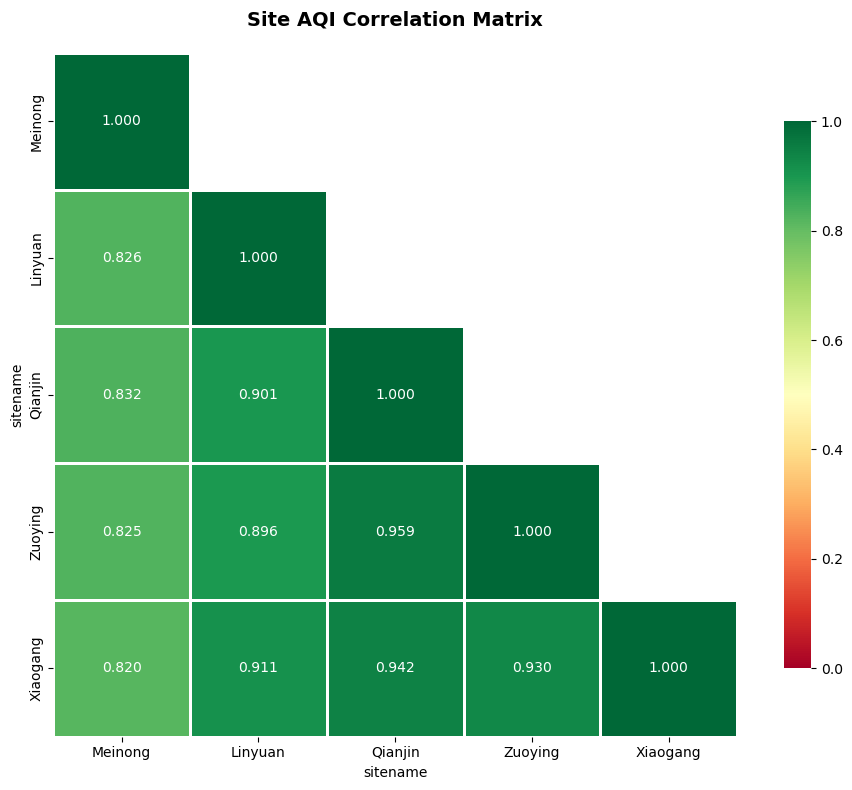


🎯 Pearson Correlation between Meinong and Neighbor Sites:
   Qianjin     : 0.8318  (Strong)
   Linyuan     : 0.8258  (Strong)
   Zuoying     : 0.8250  (Strong)
   Xiaogang    : 0.8200  (Strong)

📈 Time Series Alignment Visualization


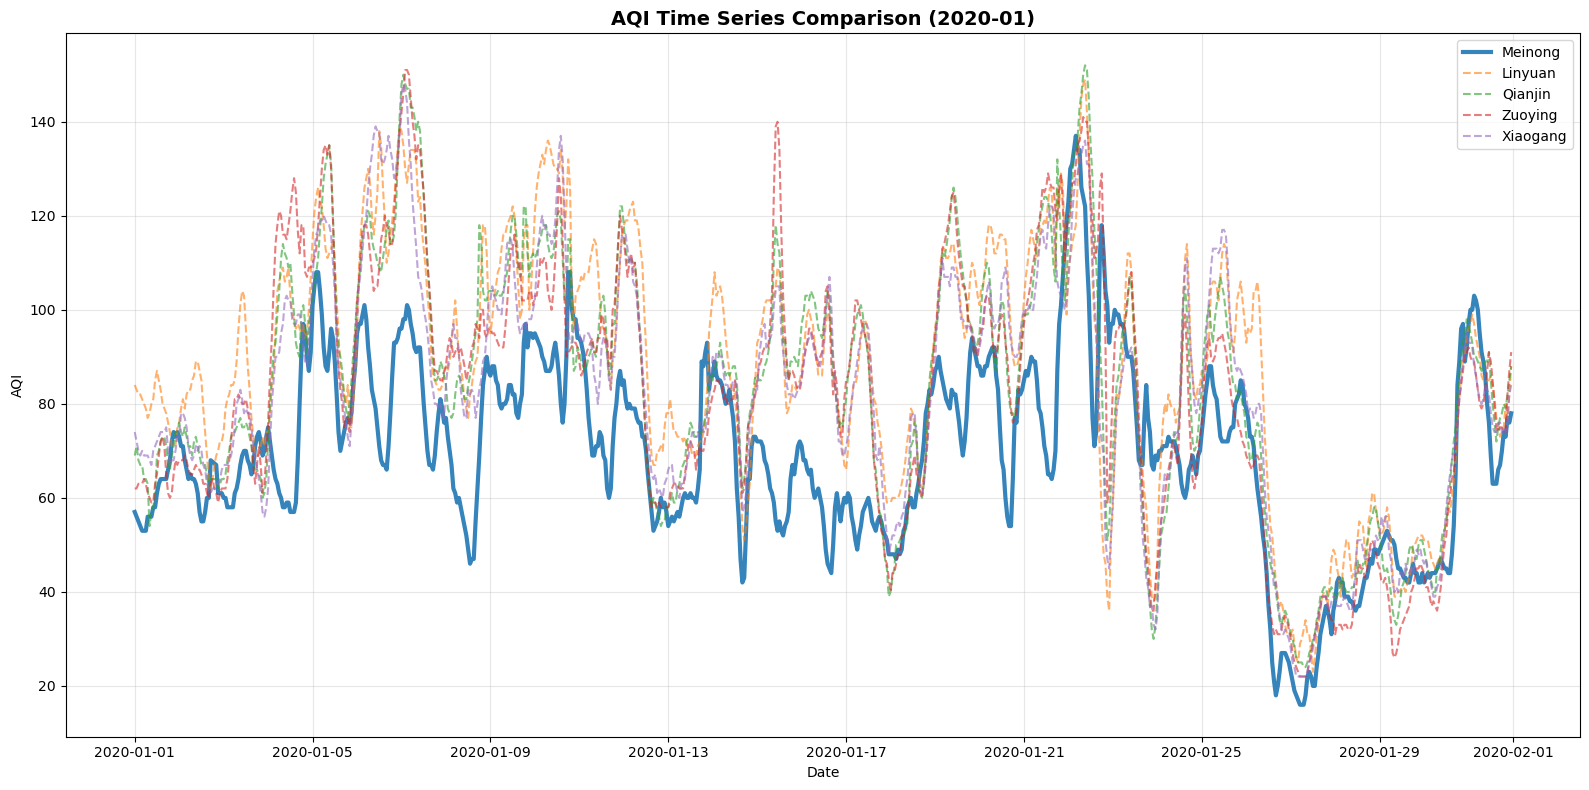


⏱️ Lag Correlation Analysis


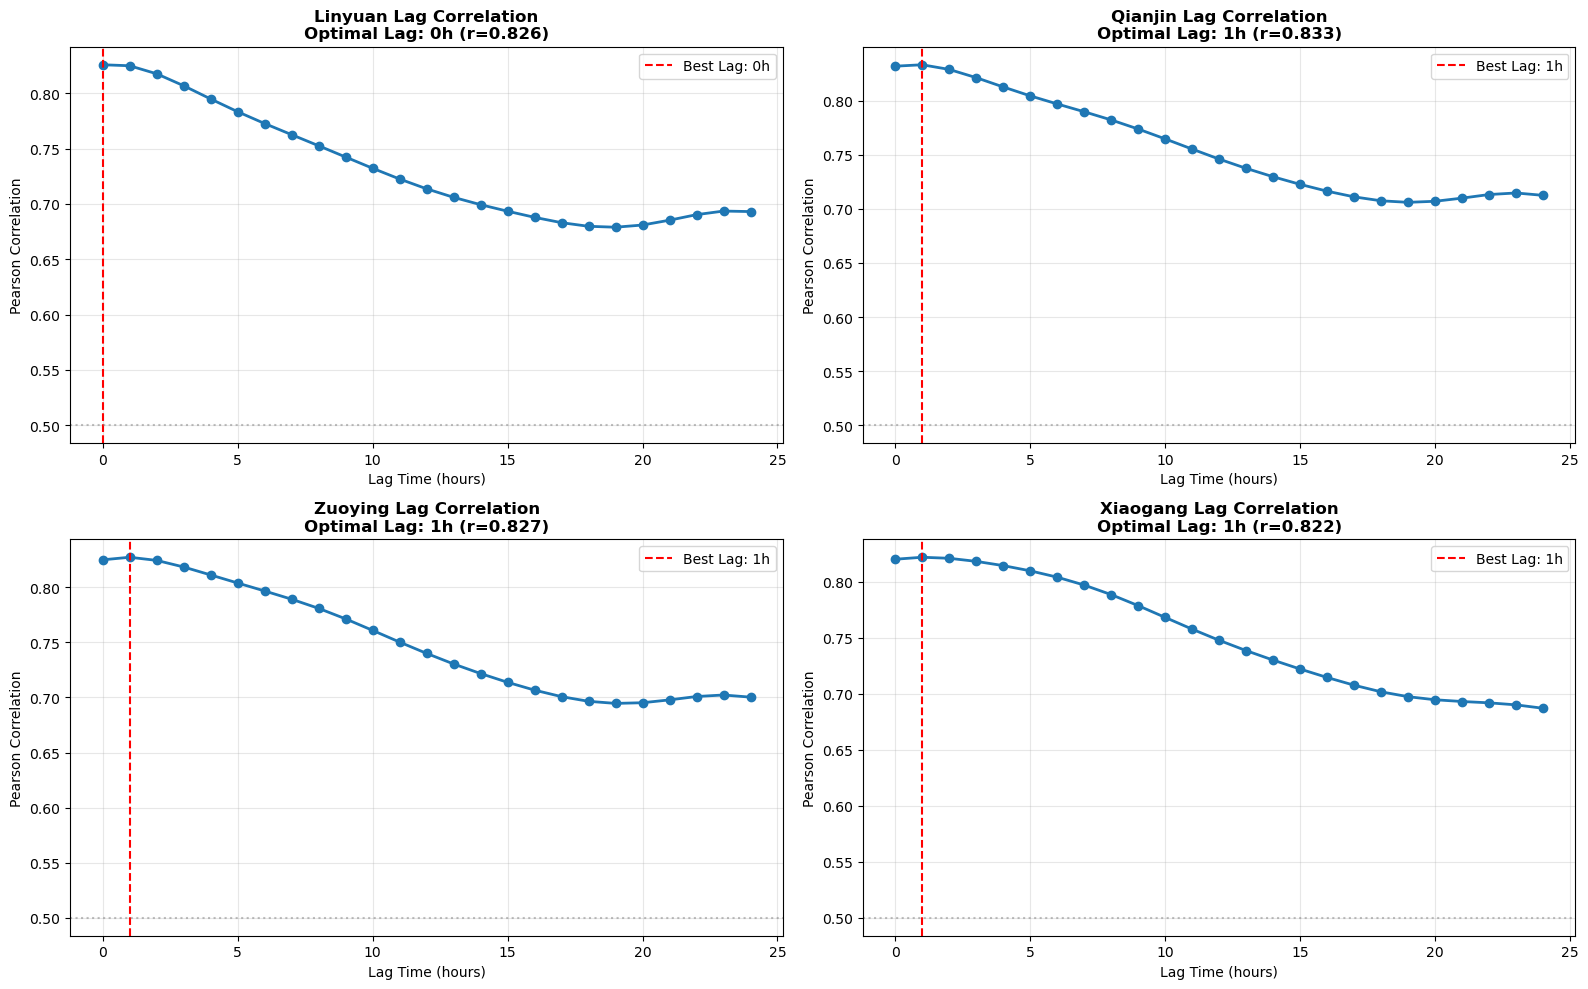


🔍 Lag Correlation Results:
   Linyuan     : Optimal Lag= 0h, Correlation=0.8258
   Qianjin     : Optimal Lag= 1h, Correlation=0.8332
   Zuoying     : Optimal Lag= 1h, Correlation=0.8273
   Xiaogang    : Optimal Lag= 1h, Correlation=0.8218

🎯 Feature Importance Assessment (Mutual Information)
 Feature  MI Score
 Qianjin  0.671373
Xiaogang  0.648978
 Zuoying  0.647851
 Linyuan  0.632419


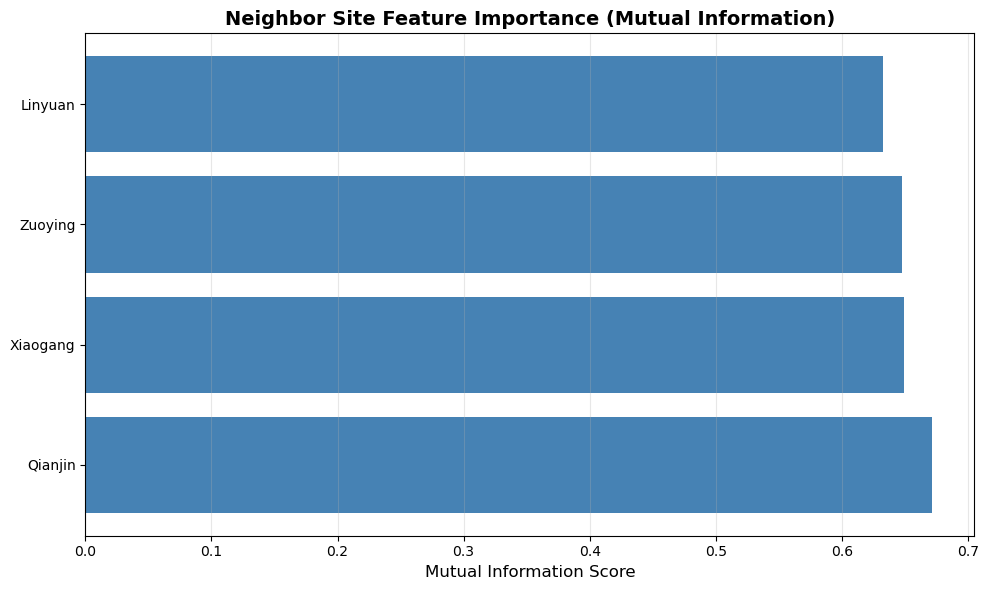


💡 Diagnostic Conclusions and Recommendations

📌 Key Findings:
   1. Average correlation between Meinong and neighbors: 0.826
   2. Number of weakly correlated (<0.5) sites: 0/4
   3. Meinong AQI mean: 52.5
   4. Neighbor sites AQI mean: 61.4

🚨 Problem Assessment:
   ✅ Neighbor features are effective
   💡 Recommendation: Use [Strategy C] - Use all neighbor features

📋 Recommended Neighbor Sites to Retain:
   ✓ Qianjin (r=0.832)
   ✓ Linyuan (r=0.826)
   ✓ Zuoying (r=0.825)
   ✓ Xiaogang (r=0.820)



In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 🔍 Site Correlation and Distribution Diagnostic Tool
# ==========================================

print("📁 Loading data...")
data = pd.read_csv('C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv')
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['sitename', 'date'])

target_site = 'Meinong'
neighbor_sites = ['Linyuan', 'Qianjin', 'Zuoying', 'Xiaogang']
all_sites = [target_site] + neighbor_sites

# ==========================================
# 1. Site AQI Distribution Comparison
# ==========================================
print("\n" + "="*70)
print("📊 Site AQI Distribution Statistics")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

stats_summary = []
for idx, site in enumerate(all_sites):
    site_data = data[data['sitename'] == site]['AQI'].dropna()
    
    # Statistical information
    stats = {
        'Site': site,
        'Mean': site_data.mean(),
        'Std': site_data.std(),
        'Median': site_data.median(),
        'Min': site_data.min(),
        'Max': site_data.max(),
        'Count': len(site_data)
    }
    stats_summary.append(stats)
    
    # Visualization
    axes[idx].hist(site_data, bins=50, alpha=0.7, edgecolor='black')
    axes[idx].axvline(site_data.mean(), color='red', linestyle='--', 
                      linewidth=2, label=f'Mean: {site_data.mean():.1f}')
    # ⭐ Each site has its own subtitle
    axes[idx].set_title(f'{site} AQI Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('AQI')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].axis('off')  # Hide the last subplot
plt.tight_layout()
plt.savefig('site_aqi_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistical table
stats_df = pd.DataFrame(stats_summary)
print(stats_df.to_string(index=False))

# ⭐ Key metric: Coefficient of Variation (CV)
print("\n📌 Coefficient of Variation (CV = std/mean):")
for _, row in stats_df.iterrows():
    cv = row['Std'] / row['Mean']
    print(f"   {row['Site']}: {cv:.3f}")

# ==========================================
# 2. Inter-site AQI Correlation Analysis
# ==========================================
print("\n" + "="*70)
print("🔗 Inter-site AQI Correlation Analysis")
print("="*70)

# Construct wide-format data
pivot_data = data.pivot_table(
    index='date', 
    columns='sitename', 
    values='AQI'
).fillna(method='ffill').fillna(method='bfill')

# Ensure all sites exist
pivot_data = pivot_data[[col for col in all_sites if col in pivot_data.columns]]

# Calculate correlation matrix
corr_matrix = pivot_data.corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.3f', 
            cmap='RdYlGn', 
            center=0.5,
            vmin=0, 
            vmax=1,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8})
plt.title(f'Site AQI Correlation Matrix', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('site_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print correlation between target site and neighbors
print(f"\n🎯 Pearson Correlation between {target_site} and Neighbor Sites:")
target_corr = corr_matrix[target_site].drop(target_site).sort_values(ascending=False)
for site, corr in target_corr.items():
    strength = "Strong" if corr > 0.7 else "Moderate" if corr > 0.5 else "Weak"
    print(f"   {site:12s}: {corr:.4f}  ({strength})")

# ==========================================
# 3. Time Series Alignment Visualization
# ==========================================
print("\n" + "="*70)
print("📈 Time Series Alignment Visualization")
print("="*70)

# Select one month of data for visualization
sample_month = pivot_data.index[0].replace(day=1)
sample_data = pivot_data[
    (pivot_data.index >= sample_month) & 
    (pivot_data.index < sample_month + pd.DateOffset(months=1))
]

plt.figure(figsize=(16, 8))
for site in all_sites:
    if site in sample_data.columns:
        if site == target_site:
            plt.plot(sample_data.index, sample_data[site], 
                    label=site, linewidth=3, alpha=0.9)
        else:
            plt.plot(sample_data.index, sample_data[site], 
                    label=site, linewidth=1.5, alpha=0.6, linestyle='--')

plt.title(f'AQI Time Series Comparison ({sample_month.strftime("%Y-%m")})', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('time_series_alignment.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. Lag Correlation Analysis
# ==========================================
print("\n" + "="*70)
print("⏱️ Lag Correlation Analysis")
print("="*70)

max_lag = 24  # Check lag within 24 hours
lag_results = []

for neighbor in neighbor_sites:
    if neighbor in pivot_data.columns:
        lags = range(0, max_lag + 1)
        correlations = []
        
        for lag in lags:
            if lag == 0:
                corr, _ = pearsonr(
                    pivot_data[target_site].dropna(), 
                    pivot_data[neighbor].dropna()
                )
            else:
                # Neighbor site lagged by 'lag' hours
                shifted = pivot_data[neighbor].shift(lag)
                valid_idx = pivot_data[target_site].notna() & shifted.notna()
                corr, _ = pearsonr(
                    pivot_data[target_site][valid_idx], 
                    shifted[valid_idx]
                )
            correlations.append(corr)
        
        lag_results.append({
            'neighbor': neighbor,
            'correlations': correlations,
            'best_lag': lags[np.argmax(correlations)],
            'best_corr': max(correlations)
        })

# Visualize lag correlation
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, result in enumerate(lag_results):
    axes[idx].plot(range(max_lag + 1), result['correlations'], 
                   marker='o', linewidth=2)
    axes[idx].axvline(result['best_lag'], color='r', linestyle='--', 
                     label=f"Best Lag: {result['best_lag']}h")
    axes[idx].axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    axes[idx].set_title(f"{result['neighbor']} Lag Correlation\n"
                       f"Optimal Lag: {result['best_lag']}h (r={result['best_corr']:.3f})",
                       fontweight='bold')
    axes[idx].set_xlabel('Lag Time (hours)')
    axes[idx].set_ylabel('Pearson Correlation')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lag_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🔍 Lag Correlation Results:")
for result in lag_results:
    print(f"   {result['neighbor']:12s}: "
          f"Optimal Lag={result['best_lag']:2d}h, "
          f"Correlation={result['best_corr']:.4f}")

# ==========================================
# 5. Feature Importance Assessment (Mutual Information)
# ==========================================
from sklearn.feature_selection import mutual_info_regression

print("\n" + "="*70)
print("🎯 Feature Importance Assessment (Mutual Information)")
print("="*70)

# Construct feature matrix
feature_cols = [col for col in pivot_data.columns if col != target_site]
X_mi = pivot_data[feature_cols].values
y_mi = pivot_data[target_site].values

# Calculate mutual information
mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_results = pd.DataFrame({
    'Feature': feature_cols,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print(mi_results.to_string(index=False))

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(mi_results['Feature'], mi_results['MI Score'], color='steelblue')
plt.xlabel('Mutual Information Score', fontsize=12)
plt.title('Neighbor Site Feature Importance (Mutual Information)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_mi.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 6. Diagnostic Conclusions and Recommendations
# ==========================================
print("\n" + "="*70)
print("💡 Diagnostic Conclusions and Recommendations")
print("="*70)

# Calculate average correlation
avg_corr = target_corr.mean()
weak_corr_count = (target_corr < 0.5).sum()

print(f"\n📌 Key Findings:")
print(f"   1. Average correlation between {target_site} and neighbors: {avg_corr:.3f}")
print(f"   2. Number of weakly correlated (<0.5) sites: {weak_corr_count}/{len(neighbor_sites)}")
print(f"   3. {target_site} AQI mean: {stats_df[stats_df['Site']==target_site]['Mean'].values[0]:.1f}")
print(f"   4. Neighbor sites AQI mean: {stats_df[stats_df['Site']!=target_site]['Mean'].mean():.1f}")

print(f"\n🚨 Problem Assessment:")
if avg_corr < 0.5:
    print("   ⚠️  Serious Issue: Neighbor features nearly useless (avg corr < 0.5)")
    print("   💡 Recommendation: Use [Strategy A] - Local features only")
elif avg_corr < 0.7:
    print("   ⚠️  Moderate Issue: Neighbor features limited usefulness")
    print("   💡 Recommendation: Use [Strategy B] - Select high-correlation neighbors")
else:
    print("   ✅ Neighbor features are effective")
    print("   💡 Recommendation: Use [Strategy C] - Use all neighbor features")

# Recommended neighbor sites to retain
recommended_neighbors = target_corr[target_corr > 0.5].index.tolist()
print(f"\n📋 Recommended Neighbor Sites to Retain:")
if recommended_neighbors:
    for site in recommended_neighbors:
        print(f"   ✓ {site} (r={target_corr[site]:.3f})")
else:
    print("   ✗ No recommended sites, suggest using local features only")

print("\n" + "="*70)

🖥️  使用设备: cuda
📋 任务配置: 使用48小时历史预测未来24小时

📁 正在加载数据...

🔧 进行特征工程...
✅ 特征工程完成，最终特征数: 50

📊 序列构建完成:
   样本数量: 40825
   输入形状: (40825, 48, 50)
   输出形状: (40825, 24)

📦 数据集划分:
   训练集: (28577, 48, 50) (70.0%)
   验证集: (6123, 48, 50) (15.0%)
   测试集: (6125, 48, 50) (15.0%)
✅ 数据标准化完成

🤖 模型初始化完成
   输入特征数: 50
   模型参数量: 5,725,592

🏋️  开始训练...
Epoch   1/150 ⭐ | Train: 0.303988 | Val: 0.213134 | LR: 0.000497 | Patience:  0/25
Epoch   2/150  | Train: 0.195544 | Val: 0.243183 | LR: 0.000488 | Patience:  1/25
Epoch   3/150  | Train: 0.127124 | Val: 0.243732 | LR: 0.000473 | Patience:  2/25
Epoch  10/150  | Train: 0.039575 | Val: 0.230418 | LR: 0.000251 | Patience:  9/25
Epoch  20/150  | Train: 0.024711 | Val: 0.229901 | LR: 0.000500 | Patience: 19/25

⚠️  Early Stopping @ Epoch 26

✅ 训练完成！最佳模型: Epoch 1, Val Loss: 0.213134

🔮 测试集评估...

📊 ========== 24小时预测最终评价指标 ==========
RMSE (均方根误差): 13.9311
MAE  (平均绝对误差): 9.7867
R²   (决定系数)    : 0.7152

📌 Baseline (持续性模型):
   Baseline RMSE: 18.5999
   改进幅度: +25.10%

📈 分时段

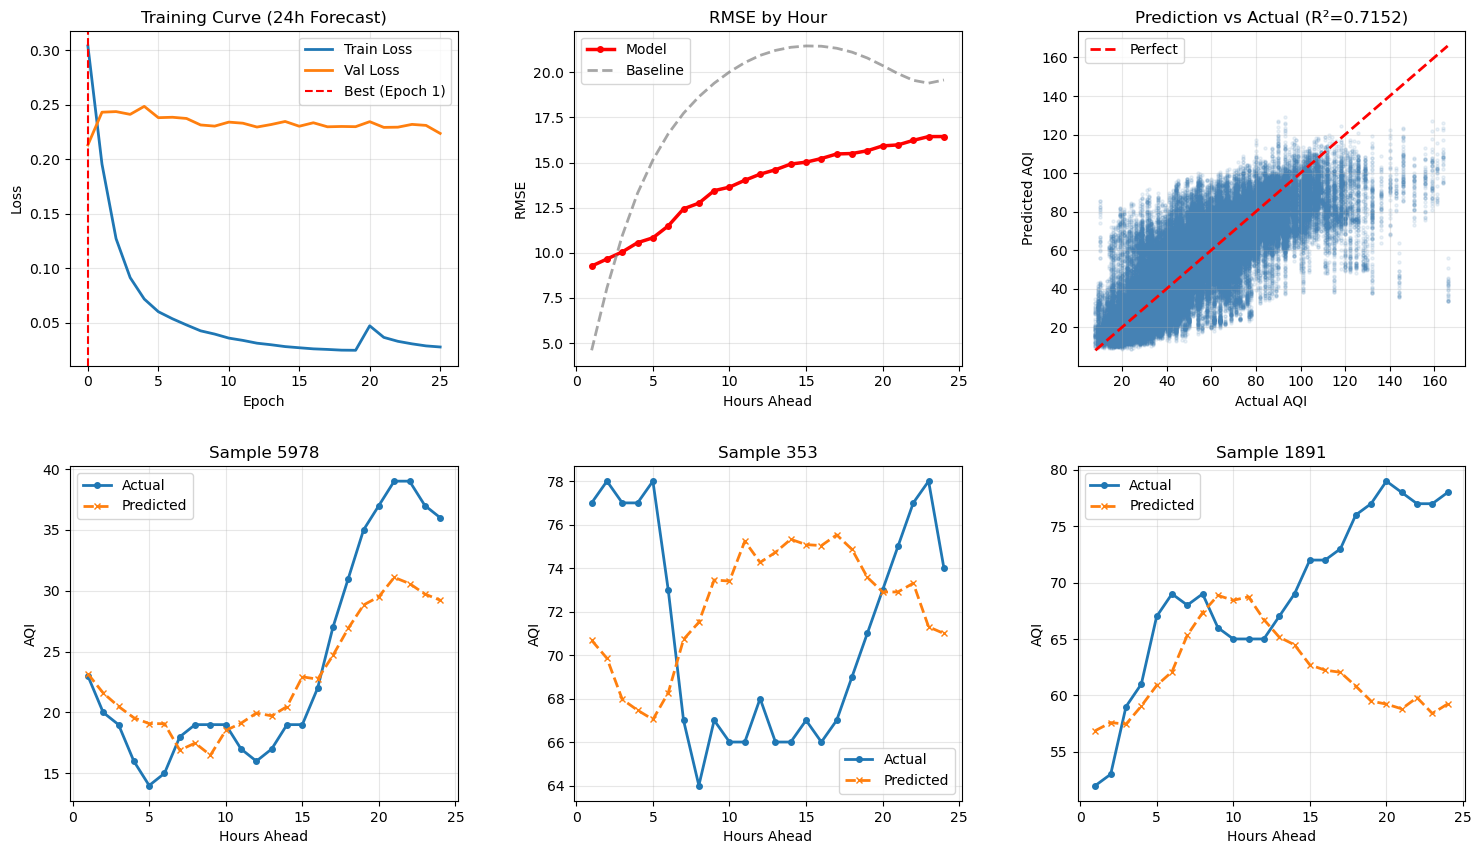


✨ 24小时预测任务完成！


In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# ⭐ 仅修改这两行
# ==========================================
INPUT_WINDOW = 48    # 使用48h历史预测24h（2天预测1天）
OUTPUT_WINDOW = 24   # 预测未来24小时

# 其他超参数
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64
EPOCHS = 150
LEARNING_RATE = 0.0005  # 稍微提高学习率（因为任务更简单）
PATIENCE = 25
WEIGHT_DECAY = 1e-4

D_MODEL = 96
N_HEAD = 6
N_LAYERS = 3
DROPOUT = 0.15

print(f"🖥️  使用设备: {DEVICE}")
print(f"📋 任务配置: 使用{INPUT_WINDOW}小时历史预测未来{OUTPUT_WINDOW}小时")

# ==========================================
# 数据加载（与之前相同）
# ==========================================
print("\n📁 正在加载数据...")
data = pd.read_csv('C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv')
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['sitename', 'date'])

target_site = 'Meinong'
neighbor_sites = ['Linyuan', 'Qianjin', 'Zuoying', 'Xiaogang']

LAG_CONFIG = {
    'Linyuan': 0,
    'Qianjin': 1,
    'Zuoying': 1,
    'Xiaogang': 1
}

df_target = data[data['sitename'] == target_site].copy()
df_target = df_target.set_index('date')
df_neighbors = data[data['sitename'].isin(neighbor_sites)].copy()

# ==========================================
# 特征工程（与之前相同）
# ==========================================
print("\n🔧 进行特征工程...")

df_base = df_target.copy()

for neighbor in neighbor_sites:
    df_neighbor = df_neighbors[df_neighbors['sitename'] == neighbor].copy()
    df_neighbor = df_neighbor.set_index('date')
    
    lag = LAG_CONFIG[neighbor]
    if lag > 0:
        df_neighbor = df_neighbor.shift(lag)
    
    neighbor_features = ['PM2.5', 'AQI', 'winddirec', 'windspeed']
    df_neighbor_selected = df_neighbor[neighbor_features].copy()
    df_neighbor_selected.columns = [f'{neighbor}_{col}' for col in neighbor_features]
    df_base = df_base.join(df_neighbor_selected, how='left')

df_base = df_base.ffill().bfill()

# 时间编码
df_base['hour'] = df_base.index.hour
df_base['month'] = df_base.index.month
df_base['dayofweek'] = df_base.index.dayofweek

df_base['hour_sin'] = np.sin(2 * np.pi * df_base['hour'] / 24)
df_base['hour_cos'] = np.cos(2 * np.pi * df_base['hour'] / 24)
df_base['month_sin'] = np.sin(2 * np.pi * df_base['month'] / 12)
df_base['month_cos'] = np.cos(2 * np.pi * df_base['month'] / 12)
df_base['day_sin'] = np.sin(2 * np.pi * df_base['dayofweek'] / 7)
df_base['day_cos'] = np.cos(2 * np.pi * df_base['dayofweek'] / 7)
df_base['is_weekend'] = (df_base['dayofweek'] >= 5).astype(int)

# 风向向量化
df_base['wind_rad'] = np.deg2rad(df_base['winddirec'])
df_base['Wind_X'] = df_base['windspeed'] * np.cos(df_base['wind_rad'])
df_base['Wind_Y'] = df_base['windspeed'] * np.sin(df_base['wind_rad'])

for neighbor in neighbor_sites:
    wind_dir_col = f'{neighbor}_winddirec'
    wind_speed_col = f'{neighbor}_windspeed'
    if wind_dir_col in df_base.columns:
        df_base[f'{neighbor}_wind_rad'] = np.deg2rad(df_base[wind_dir_col])
        df_base[f'{neighbor}_Wind_X'] = df_base[wind_speed_col] * np.cos(df_base[f'{neighbor}_wind_rad'])
        df_base[f'{neighbor}_Wind_Y'] = df_base[wind_speed_col] * np.sin(df_base[f'{neighbor}_wind_rad'])

# 滞后特征
for lag in [1, 3, 6, 12, 24]:
    df_base[f'AQI_lag_{lag}'] = df_base['AQI'].shift(lag)
    df_base[f'PM25_lag_{lag}'] = df_base['PM2.5'].shift(lag)

# 滚动统计
for window in [6, 12, 24]:
    df_base[f'AQI_roll_mean_{window}'] = df_base['AQI'].rolling(window).mean()
    df_base[f'AQI_roll_std_{window}'] = df_base['AQI'].rolling(window).std()

# 邻居聚合特征
neighbor_aqi_cols = [f'{n}_AQI' for n in neighbor_sites]
df_base['neighbor_AQI_mean'] = df_base[neighbor_aqi_cols].mean(axis=1)
df_base['neighbor_AQI_std'] = df_base[neighbor_aqi_cols].std(axis=1)

df_base = df_base.dropna()

# 特征选择
features_to_keep = [
    'PM2.5', 'PM10', 'O3', 'SO2', 'NOx', 'CO', 'AQI',
    'Wind_X', 'Wind_Y',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend',
    'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_6', 'AQI_lag_12', 'AQI_lag_24',
    'PM25_lag_1', 'PM25_lag_3', 'PM25_lag_6', 'PM25_lag_12', 'PM25_lag_24',
    'AQI_roll_mean_6', 'AQI_roll_mean_12', 'AQI_roll_mean_24',
    'AQI_roll_std_6', 'AQI_roll_std_12', 'AQI_roll_std_24',
    'neighbor_AQI_mean', 'neighbor_AQI_std'
]

for neighbor in neighbor_sites:
    features_to_keep.extend([
        f'{neighbor}_PM2.5',
        f'{neighbor}_AQI',
        f'{neighbor}_Wind_X',
        f'{neighbor}_Wind_Y'
    ])

final_cols = [c for c in features_to_keep if c in df_base.columns]
df_processed = df_base[final_cols].copy()

print(f"✅ 特征工程完成，最终特征数: {len(final_cols)}")

# ==========================================
# 序列构建
# ==========================================
def create_multistep_sequences(data_array, target_col_idx, input_len, output_len):
    X, y = [], []
    total_len = len(data_array)
    for i in range(total_len - input_len - output_len + 1):
        X.append(data_array[i : i + input_len])
        y.append(data_array[i + input_len : i + input_len + output_len, target_col_idx])
    return np.array(X), np.array(y)

aqi_col_idx = df_processed.columns.get_loc('AQI')
data_raw = df_processed.values
X_all_raw, y_all_raw = create_multistep_sequences(data_raw, aqi_col_idx, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"\n📊 序列构建完成:")
print(f"   样本数量: {len(X_all_raw)}")
print(f"   输入形状: {X_all_raw.shape}")
print(f"   输出形状: {y_all_raw.shape}")

# 数据集划分
total_samples = len(X_all_raw)
train_size = int(total_samples * 0.7)
val_size = int(total_samples * 0.15)

X_train_raw = X_all_raw[:train_size]
y_train_raw = y_all_raw[:train_size]
X_val_raw = X_all_raw[train_size:train_size + val_size]
y_val_raw = y_all_raw[train_size:train_size + val_size]
X_test_raw = X_all_raw[train_size + val_size:]
y_test_raw = y_all_raw[train_size + val_size:]

print(f"\n📦 数据集划分:")
print(f"   训练集: {X_train_raw.shape} ({len(X_train_raw)/len(X_all_raw)*100:.1f}%)")
print(f"   验证集: {X_val_raw.shape} ({len(X_val_raw)/len(X_all_raw)*100:.1f}%)")
print(f"   测试集: {X_test_raw.shape} ({len(X_test_raw)/len(X_all_raw)*100:.1f}%)")

# 数据标准化
scaler_X = StandardScaler()
scaler_y = StandardScaler()

n_samples_train, n_timesteps, n_features = X_train_raw.shape
scaler_X.fit(X_train_raw.reshape(-1, n_features))

X_train_scaled = scaler_X.transform(X_train_raw.reshape(-1, n_features)).reshape(X_train_raw.shape)
X_val_scaled = scaler_X.transform(X_val_raw.reshape(-1, n_features)).reshape(X_val_raw.shape)
X_test_scaled = scaler_X.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape)

scaler_y.fit(y_train_raw)
y_train_scaled = scaler_y.transform(y_train_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

X_train = torch.FloatTensor(X_train_scaled)
y_train = torch.FloatTensor(y_train_scaled)
X_val = torch.FloatTensor(X_val_scaled)
y_val = torch.FloatTensor(y_val_scaled)
X_test = torch.FloatTensor(X_test_scaled)
y_test = torch.FloatTensor(y_test_scaled)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print("✅ 数据标准化完成\n")

# ==========================================
# ⭐ 优化的24小时预测模型
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]


class AQI24hTransformer(nn.Module):
    """
    优化的24小时预测Transformer
    """
    def __init__(self, input_dim, output_len, d_model=96, nhead=6, 
                 num_layers=3, dropout=0.15):
        super(AQI24hTransformer, self).__init__()
        
        self.input_embedding = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers
        )
        
        # ⭐ 针对24h输出优化的decoder（更简洁）
        hidden_dim = d_model * INPUT_WINDOW
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            
            nn.Linear(256, output_len)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.dim() > 1:
                if 'weight' in name:
                    nn.init.xavier_uniform_(p, gain=0.8)
                elif 'bias' in name:
                    nn.init.constant_(p, 0)
    
    def forward(self, x):
        batch_size = x.size(0)
        x = self.input_embedding(x)
        x = x.permute(1, 0, 2)
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2)
        x = self.transformer_encoder(x)
        x = x.reshape(batch_size, -1)
        output = self.decoder(x)
        return output


# 初始化模型
input_features = X_train.shape[2]
model = AQI24hTransformer(
    input_dim=input_features,
    output_len=OUTPUT_WINDOW,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=20,
    T_mult=2,
    eta_min=1e-6
)

print(f"🤖 模型初始化完成")
print(f"   输入特征数: {input_features}")
print(f"   模型参数量: {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# 训练循环
# ==========================================
print("\n🏋️  开始训练...")
print("=" * 80)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

for epoch in range(EPOCHS):
    # 训练
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 验证
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_24h.pth')
        patience_counter = 0
        improved = "⭐"
    else:
        patience_counter += 1
        improved = ""
    
    if (epoch + 1) % 10 == 0 or epoch < 3:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} {improved} | "
              f"Train: {avg_train_loss:.6f} | "
              f"Val: {avg_val_loss:.6f} | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter:2d}/{PATIENCE}")
    
    if patience_counter >= PATIENCE:
        print(f"\n⚠️  Early Stopping @ Epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_model_24h.pth'))
print(f"\n✅ 训练完成！最佳模型: Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}")

# ==========================================
# 测试集评估
# ==========================================
print("\n🔮 测试集评估...")
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch)
        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

y_pred_scaled = np.concatenate(predictions, axis=0)
y_true_scaled = np.concatenate(actuals, axis=0)

y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_true_real = scaler_y.inverse_transform(y_true_scaled)

# 评价指标
mse = mean_squared_error(y_true_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_real, y_pred_real)
r2 = r2_score(y_true_real.flatten(), y_pred_real.flatten())

# Baseline
baseline_persist_pred = np.tile(X_test_raw[:, -1, aqi_col_idx:aqi_col_idx+1], (1, OUTPUT_WINDOW))
baseline_persist_rmse = np.sqrt(mean_squared_error(y_true_real, baseline_persist_pred))

print("\n" + "=" * 70)
print("📊 ========== 24小时预测最终评价指标 ==========")
print(f"RMSE (均方根误差): {rmse:.4f}")
print(f"MAE  (平均绝对误差): {mae:.4f}")
print(f"R²   (决定系数)    : {r2:.4f}")
print(f"\n📌 Baseline (持续性模型):")
print(f"   Baseline RMSE: {baseline_persist_rmse:.4f}")
print(f"   改进幅度: {(1-rmse/baseline_persist_rmse)*100:+.2f}%")
print("=" * 70)

# 分时段分析
print("\n📈 分时段RMSE分析:")
step_rmse = np.sqrt(np.mean((y_true_real - y_pred_real) ** 2, axis=0))
step_mae = np.mean(np.abs(y_true_real - y_pred_real), axis=0)

print("小时   RMSE    MAE")
print("-" * 30)
for h in [1, 3, 6, 12, 18, 24]:
    print(f"{h:3d}h  {step_rmse[h-1]:6.2f}  {step_mae[h-1]:6.2f}")

# 分时段评估
horizons = {
    '超短期 (1-6h)': (0, 6),
    '短期 (7-12h)': (6, 12),
    '中期 (13-18h)': (12, 18),
    '长期 (19-24h)': (18, 24)
}

print("\n" + "=" * 70)
print("📋 分时段性能详细报告")
print("=" * 70)

for name, (start, end) in horizons.items():
    y_true_horizon = y_true_real[:, start:end]
    y_pred_horizon = y_pred_real[:, start:end]
    
    rmse_horizon = np.sqrt(mean_squared_error(y_true_horizon, y_pred_horizon))
    mae_horizon = mean_absolute_error(y_true_horizon, y_pred_horizon)
    r2_horizon = r2_score(y_true_horizon.flatten(), y_pred_horizon.flatten())
    
    print(f"\n{name}:")
    print(f"   RMSE: {rmse_horizon:.4f}")
    print(f"   MAE : {mae_horizon:.4f}")
    print(f"   R²  : {r2_horizon:.4f}")

# ==========================================
# 可视化
# ==========================================
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 图4-6: 三个样本预测对比
for i in range(3):
    ax = fig.add_subplot(gs[1, i])
    sample_id = np.random.randint(0, len(y_true_real))
    ax.plot(hours, y_true_real[sample_id], label='Actual', marker='o', markersize=4, linewidth=2)
    ax.plot(hours, y_pred_real[sample_id], label='Predicted', marker='x', markersize=4, linestyle='--', linewidth=2)
    ax.set_xlabel('Hours Ahead')
    ax.set_ylabel('AQI')
    ax.set_title(f'Sample {sample_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.savefig('24h_forecast_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✨ 24小时预测任务完成！")

🖥️  使用设备: cuda
📋 任务配置: 使用48小时历史预测未来24小时

📁 正在加载数据...

🔧 进行特征工程...
✅ 特征工程完成，最终特征数: 50

📊 序列构建完成:
   样本数量: 40825
   输入形状: (40825, 48, 50)
   输出形状: (40825, 24)

📦 数据集划分:
   训练集: (28577, 48, 50) (70.0%)
   验证集: (6123, 48, 50) (15.0%)
   测试集: (6125, 48, 50) (15.0%)
✅ 数据标准化完成

🤖 模型初始化完成
   输入特征数: 50
   模型参数量: 5,725,592

🏋️  开始训练...
Epoch   1/150 ⭐ | Train: 0.277263 | Val: 0.209245 | LR: 0.000497 | Patience:  0/25
Epoch   2/150  | Train: 0.199378 | Val: 0.225031 | LR: 0.000488 | Patience:  1/25
Epoch   3/150  | Train: 0.143543 | Val: 0.256348 | LR: 0.000473 | Patience:  2/25
Epoch  10/150  | Train: 0.040631 | Val: 0.251575 | LR: 0.000251 | Patience:  9/25
Epoch  20/150  | Train: 0.025555 | Val: 0.240688 | LR: 0.000500 | Patience: 19/25

⚠️  Early Stopping @ Epoch 26

✅ 训练完成！最佳模型: Epoch 1, Val Loss: 0.209245

🔮 测试集评估...

📊 ========== 24小时预测最终评价指标 ==========
RMSE (均方根误差): 15.3967
MAE  (平均绝对误差): 11.0297
R²   (决定系数)    : 0.7109

📌 Baseline (持续性模型):
   Baseline RMSE: 17.1568
   改进幅度: +10.26%

📈 分时

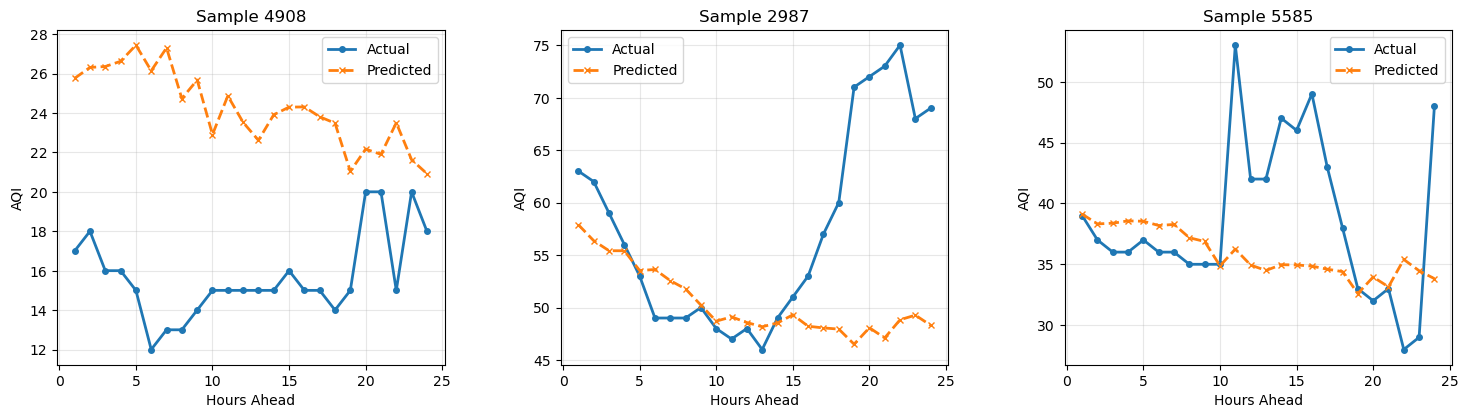


✨ 24小时预测任务完成！


In [28]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# ⭐ 仅修改这两行
# ==========================================
INPUT_WINDOW = 48    # 使用48h历史预测24h（2天预测1天）
OUTPUT_WINDOW = 24   # 预测未来24小时

# 其他超参数
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64
EPOCHS = 150
LEARNING_RATE = 0.0005  # 稍微提高学习率（因为任务更简单）
PATIENCE = 25
WEIGHT_DECAY = 1e-4

D_MODEL = 96
N_HEAD = 6
N_LAYERS = 3
DROPOUT = 0.15

print(f"🖥️  使用设备: {DEVICE}")
print(f"📋 任务配置: 使用{INPUT_WINDOW}小时历史预测未来{OUTPUT_WINDOW}小时")

# ==========================================
# 数据加载（与之前相同）
# ==========================================
print("\n📁 正在加载数据...")
data = pd.read_csv('C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv')
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['sitename', 'date'])

target_site = 'Xiaogang'
neighbor_sites = ['Linyuan', 'Qianjin', 'Zuoying', 'Meinong']

LAG_CONFIG = {
    'Linyuan': 0,
    'Qianjin': 0,
    'Zuoying': 0,
    'Meinong': 0
}

df_target = data[data['sitename'] == target_site].copy()
df_target = df_target.set_index('date')
df_neighbors = data[data['sitename'].isin(neighbor_sites)].copy()

# ==========================================
# 特征工程（与之前相同）
# ==========================================
print("\n🔧 进行特征工程...")

df_base = df_target.copy()

for neighbor in neighbor_sites:
    df_neighbor = df_neighbors[df_neighbors['sitename'] == neighbor].copy()
    df_neighbor = df_neighbor.set_index('date')
    
    lag = LAG_CONFIG[neighbor]
    if lag > 0:
        df_neighbor = df_neighbor.shift(lag)
    
    neighbor_features = ['PM2.5', 'AQI', 'winddirec', 'windspeed']
    df_neighbor_selected = df_neighbor[neighbor_features].copy()
    df_neighbor_selected.columns = [f'{neighbor}_{col}' for col in neighbor_features]
    df_base = df_base.join(df_neighbor_selected, how='left')

df_base = df_base.ffill().bfill()

# 时间编码
df_base['hour'] = df_base.index.hour
df_base['month'] = df_base.index.month
df_base['dayofweek'] = df_base.index.dayofweek

df_base['hour_sin'] = np.sin(2 * np.pi * df_base['hour'] / 24)
df_base['hour_cos'] = np.cos(2 * np.pi * df_base['hour'] / 24)
df_base['month_sin'] = np.sin(2 * np.pi * df_base['month'] / 12)
df_base['month_cos'] = np.cos(2 * np.pi * df_base['month'] / 12)
df_base['day_sin'] = np.sin(2 * np.pi * df_base['dayofweek'] / 7)
df_base['day_cos'] = np.cos(2 * np.pi * df_base['dayofweek'] / 7)
df_base['is_weekend'] = (df_base['dayofweek'] >= 5).astype(int)

# 风向向量化
df_base['wind_rad'] = np.deg2rad(df_base['winddirec'])
df_base['Wind_X'] = df_base['windspeed'] * np.cos(df_base['wind_rad'])
df_base['Wind_Y'] = df_base['windspeed'] * np.sin(df_base['wind_rad'])

for neighbor in neighbor_sites:
    wind_dir_col = f'{neighbor}_winddirec'
    wind_speed_col = f'{neighbor}_windspeed'
    if wind_dir_col in df_base.columns:
        df_base[f'{neighbor}_wind_rad'] = np.deg2rad(df_base[wind_dir_col])
        df_base[f'{neighbor}_Wind_X'] = df_base[wind_speed_col] * np.cos(df_base[f'{neighbor}_wind_rad'])
        df_base[f'{neighbor}_Wind_Y'] = df_base[wind_speed_col] * np.sin(df_base[f'{neighbor}_wind_rad'])

# 滞后特征
for lag in [1, 3, 6, 12, 24]:
    df_base[f'AQI_lag_{lag}'] = df_base['AQI'].shift(lag)
    df_base[f'PM25_lag_{lag}'] = df_base['PM2.5'].shift(lag)

# 滚动统计
for window in [6, 12, 24]:
    df_base[f'AQI_roll_mean_{window}'] = df_base['AQI'].rolling(window).mean()
    df_base[f'AQI_roll_std_{window}'] = df_base['AQI'].rolling(window).std()

# 邻居聚合特征
neighbor_aqi_cols = [f'{n}_AQI' for n in neighbor_sites]
df_base['neighbor_AQI_mean'] = df_base[neighbor_aqi_cols].mean(axis=1)
df_base['neighbor_AQI_std'] = df_base[neighbor_aqi_cols].std(axis=1)

df_base = df_base.dropna()

# 特征选择
features_to_keep = [
    'PM2.5', 'PM10', 'O3', 'SO2', 'NOx', 'CO', 'AQI',
    'Wind_X', 'Wind_Y',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend',
    'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_6', 'AQI_lag_12', 'AQI_lag_24',
    'PM25_lag_1', 'PM25_lag_3', 'PM25_lag_6', 'PM25_lag_12', 'PM25_lag_24',
    'AQI_roll_mean_6', 'AQI_roll_mean_12', 'AQI_roll_mean_24',
    'AQI_roll_std_6', 'AQI_roll_std_12', 'AQI_roll_std_24',
    'neighbor_AQI_mean', 'neighbor_AQI_std'
]

for neighbor in neighbor_sites:
    features_to_keep.extend([
        f'{neighbor}_PM2.5',
        f'{neighbor}_AQI',
        f'{neighbor}_Wind_X',
        f'{neighbor}_Wind_Y'
    ])

final_cols = [c for c in features_to_keep if c in df_base.columns]
df_processed = df_base[final_cols].copy()

print(f"✅ 特征工程完成，最终特征数: {len(final_cols)}")

# ==========================================
# 序列构建
# ==========================================
def create_multistep_sequences(data_array, target_col_idx, input_len, output_len):
    X, y = [], []
    total_len = len(data_array)
    for i in range(total_len - input_len - output_len + 1):
        X.append(data_array[i : i + input_len])
        y.append(data_array[i + input_len : i + input_len + output_len, target_col_idx])
    return np.array(X), np.array(y)

aqi_col_idx = df_processed.columns.get_loc('AQI')
data_raw = df_processed.values
X_all_raw, y_all_raw = create_multistep_sequences(data_raw, aqi_col_idx, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"\n📊 序列构建完成:")
print(f"   样本数量: {len(X_all_raw)}")
print(f"   输入形状: {X_all_raw.shape}")
print(f"   输出形状: {y_all_raw.shape}")

# 数据集划分
total_samples = len(X_all_raw)
train_size = int(total_samples * 0.7)
val_size = int(total_samples * 0.15)

X_train_raw = X_all_raw[:train_size]
y_train_raw = y_all_raw[:train_size]
X_val_raw = X_all_raw[train_size:train_size + val_size]
y_val_raw = y_all_raw[train_size:train_size + val_size]
X_test_raw = X_all_raw[train_size + val_size:]
y_test_raw = y_all_raw[train_size + val_size:]

print(f"\n📦 数据集划分:")
print(f"   训练集: {X_train_raw.shape} ({len(X_train_raw)/len(X_all_raw)*100:.1f}%)")
print(f"   验证集: {X_val_raw.shape} ({len(X_val_raw)/len(X_all_raw)*100:.1f}%)")
print(f"   测试集: {X_test_raw.shape} ({len(X_test_raw)/len(X_all_raw)*100:.1f}%)")

# 数据标准化
scaler_X = StandardScaler()
scaler_y = StandardScaler()

n_samples_train, n_timesteps, n_features = X_train_raw.shape
scaler_X.fit(X_train_raw.reshape(-1, n_features))

X_train_scaled = scaler_X.transform(X_train_raw.reshape(-1, n_features)).reshape(X_train_raw.shape)
X_val_scaled = scaler_X.transform(X_val_raw.reshape(-1, n_features)).reshape(X_val_raw.shape)
X_test_scaled = scaler_X.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape)

scaler_y.fit(y_train_raw)
y_train_scaled = scaler_y.transform(y_train_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

X_train = torch.FloatTensor(X_train_scaled)
y_train = torch.FloatTensor(y_train_scaled)
X_val = torch.FloatTensor(X_val_scaled)
y_val = torch.FloatTensor(y_val_scaled)
X_test = torch.FloatTensor(X_test_scaled)
y_test = torch.FloatTensor(y_test_scaled)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print("✅ 数据标准化完成\n")

# ==========================================
# ⭐ 优化的24小时预测模型
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]


class AQI24hTransformer(nn.Module):
    """
    优化的24小时预测Transformer
    """
    def __init__(self, input_dim, output_len, d_model=96, nhead=6, 
                 num_layers=3, dropout=0.15):
        super(AQI24hTransformer, self).__init__()
        
        self.input_embedding = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers
        )
        
        # ⭐ 针对24h输出优化的decoder（更简洁）
        hidden_dim = d_model * INPUT_WINDOW
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            
            nn.Linear(256, output_len)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.dim() > 1:
                if 'weight' in name:
                    nn.init.xavier_uniform_(p, gain=0.8)
                elif 'bias' in name:
                    nn.init.constant_(p, 0)
    
    def forward(self, x):
        batch_size = x.size(0)
        x = self.input_embedding(x)
        x = x.permute(1, 0, 2)
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2)
        x = self.transformer_encoder(x)
        x = x.reshape(batch_size, -1)
        output = self.decoder(x)
        return output


# 初始化模型
input_features = X_train.shape[2]
model = AQI24hTransformer(
    input_dim=input_features,
    output_len=OUTPUT_WINDOW,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=20,
    T_mult=2,
    eta_min=1e-6
)

print(f"🤖 模型初始化完成")
print(f"   输入特征数: {input_features}")
print(f"   模型参数量: {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# 训练循环
# ==========================================
print("\n🏋️  开始训练...")
print("=" * 80)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

for epoch in range(EPOCHS):
    # 训练
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 验证
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_24h.pth')
        patience_counter = 0
        improved = "⭐"
    else:
        patience_counter += 1
        improved = ""
    
    if (epoch + 1) % 10 == 0 or epoch < 3:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} {improved} | "
              f"Train: {avg_train_loss:.6f} | "
              f"Val: {avg_val_loss:.6f} | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter:2d}/{PATIENCE}")
    
    if patience_counter >= PATIENCE:
        print(f"\n⚠️  Early Stopping @ Epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_model_24h.pth'))
print(f"\n✅ 训练完成！最佳模型: Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}")

# ==========================================
# 测试集评估
# ==========================================
print("\n🔮 测试集评估...")
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch)
        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

y_pred_scaled = np.concatenate(predictions, axis=0)
y_true_scaled = np.concatenate(actuals, axis=0)

y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_true_real = scaler_y.inverse_transform(y_true_scaled)

# 评价指标
mse = mean_squared_error(y_true_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_real, y_pred_real)
r2 = r2_score(y_true_real.flatten(), y_pred_real.flatten())

# Baseline
baseline_persist_pred = np.tile(X_test_raw[:, -1, aqi_col_idx:aqi_col_idx+1], (1, OUTPUT_WINDOW))
baseline_persist_rmse = np.sqrt(mean_squared_error(y_true_real, baseline_persist_pred))

print("\n" + "=" * 70)
print("📊 ========== 24小时预测最终评价指标 ==========")
print(f"RMSE (均方根误差): {rmse:.4f}")
print(f"MAE  (平均绝对误差): {mae:.4f}")
print(f"R²   (决定系数)    : {r2:.4f}")
print(f"\n📌 Baseline (持续性模型):")
print(f"   Baseline RMSE: {baseline_persist_rmse:.4f}")
print(f"   改进幅度: {(1-rmse/baseline_persist_rmse)*100:+.2f}%")
print("=" * 70)

# 分时段分析
print("\n📈 分时段RMSE分析:")
step_rmse = np.sqrt(np.mean((y_true_real - y_pred_real) ** 2, axis=0))
step_mae = np.mean(np.abs(y_true_real - y_pred_real), axis=0)

print("小时   RMSE    MAE")
print("-" * 30)
for h in [1, 3, 6, 12, 18, 24]:
    print(f"{h:3d}h  {step_rmse[h-1]:6.2f}  {step_mae[h-1]:6.2f}")

# 分时段评估
horizons = {
    '超短期 (1-6h)': (0, 6),
    '短期 (7-12h)': (6, 12),
    '中期 (13-18h)': (12, 18),
    '长期 (19-24h)': (18, 24)
}

print("\n" + "=" * 70)
print("📋 分时段性能详细报告")
print("=" * 70)

for name, (start, end) in horizons.items():
    y_true_horizon = y_true_real[:, start:end]
    y_pred_horizon = y_pred_real[:, start:end]
    
    rmse_horizon = np.sqrt(mean_squared_error(y_true_horizon, y_pred_horizon))
    mae_horizon = mean_absolute_error(y_true_horizon, y_pred_horizon)
    r2_horizon = r2_score(y_true_horizon.flatten(), y_pred_horizon.flatten())
    
    print(f"\n{name}:")
    print(f"   RMSE: {rmse_horizon:.4f}")
    print(f"   MAE : {mae_horizon:.4f}")
    print(f"   R²  : {r2_horizon:.4f}")

# ==========================================
# 可视化
# ==========================================
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 图4-6: 三个样本预测对比
for i in range(3):
    ax = fig.add_subplot(gs[1, i])
    sample_id = np.random.randint(0, len(y_true_real))
    ax.plot(hours, y_true_real[sample_id], label='Actual', marker='o', markersize=4, linewidth=2)
    ax.plot(hours, y_pred_real[sample_id], label='Predicted', marker='x', markersize=4, linestyle='--', linewidth=2)
    ax.set_xlabel('Hours Ahead')
    ax.set_ylabel('AQI')
    ax.set_title(f'Sample {sample_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.savefig('24h_forecast_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✨ 24小时预测任务完成！")

🖥️  使用设备: cuda
📋 任务配置: 使用48小时历史预测未来24小时

📁 正在加载数据...

🔧 进行特征工程...
✅ 特征工程完成，最终特征数: 50

📊 序列构建完成:
   样本数量: 40825
   输入形状: (40825, 48, 50)
   输出形状: (40825, 24)

📦 数据集划分:
   训练集: (28577, 48, 50) (70.0%)
   验证集: (6123, 48, 50) (15.0%)
   测试集: (6125, 48, 50) (15.0%)
✅ 数据标准化完成

🤖 模型初始化完成
   输入特征数: 50
   模型参数量: 5,725,592

🏋️  开始训练...
Epoch   1/150 ⭐ | Train: 0.297005 | Val: 0.246785 | LR: 0.000497 | Patience:  0/25
Epoch   2/150 ⭐ | Train: 0.200430 | Val: 0.236684 | LR: 0.000488 | Patience:  0/25
Epoch   3/150  | Train: 0.139814 | Val: 0.249902 | LR: 0.000473 | Patience:  1/25
Epoch  10/150  | Train: 0.041308 | Val: 0.259456 | LR: 0.000251 | Patience:  8/25
Epoch  20/150  | Train: 0.026100 | Val: 0.257320 | LR: 0.000500 | Patience: 18/25

⚠️  Early Stopping @ Epoch 27

✅ 训练完成！最佳模型: Epoch 2, Val Loss: 0.236684

🔮 测试集评估...

📊 ========== 24小时预测最终评价指标 ==========
RMSE (均方根误差): 19.5544
MAE  (平均绝对误差): 13.6700
R²   (决定系数)    : 0.6370

📌 Baseline (持续性模型):
   Baseline RMSE: 21.3254
   改进幅度: +8.30%

📈 分时

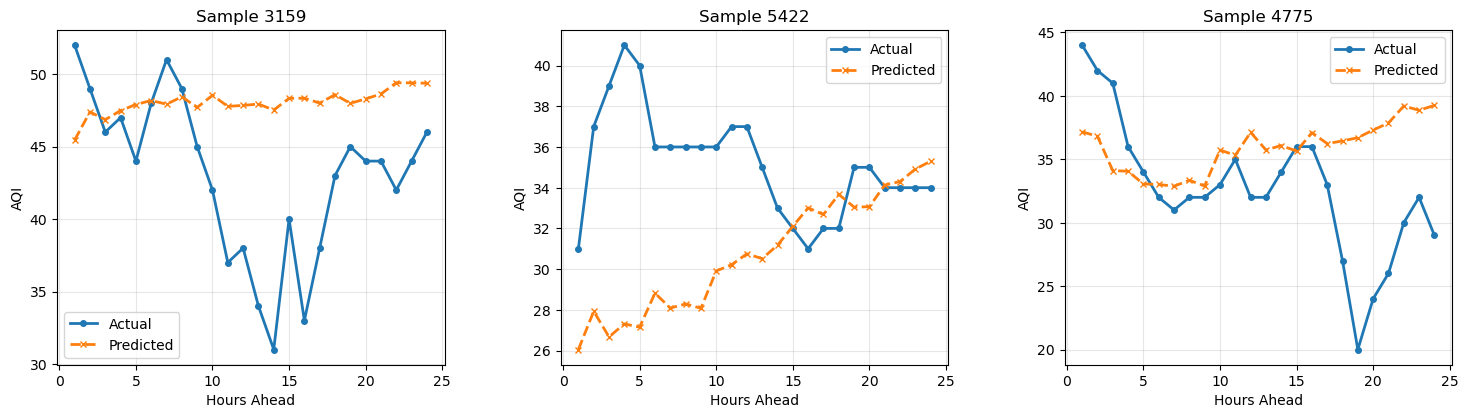


✨ 24小时预测任务完成！


In [29]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# ⭐ 仅修改这两行
# ==========================================
INPUT_WINDOW = 48    # 使用48h历史预测24h（2天预测1天）
OUTPUT_WINDOW = 24   # 预测未来24小时

# 其他超参数
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64
EPOCHS = 150
LEARNING_RATE = 0.0005  # 稍微提高学习率（因为任务更简单）
PATIENCE = 25
WEIGHT_DECAY = 1e-4

D_MODEL = 96
N_HEAD = 6
N_LAYERS = 3
DROPOUT = 0.15

print(f"🖥️  使用设备: {DEVICE}")
print(f"📋 任务配置: 使用{INPUT_WINDOW}小时历史预测未来{OUTPUT_WINDOW}小时")

# ==========================================
# 数据加载（与之前相同）
# ==========================================
print("\n📁 正在加载数据...")
data = pd.read_csv('C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv')
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['sitename', 'date'])

target_site = 'Linyuan'
neighbor_sites = ['Xiaogang', 'Qianjin', 'Zuoying', 'Meinong']

LAG_CONFIG = {
    'Xiaogang': 0,
    'Qianjin': 0,
    'Zuoying': 0,
    'Meinong': 0
}

df_target = data[data['sitename'] == target_site].copy()
df_target = df_target.set_index('date')
df_neighbors = data[data['sitename'].isin(neighbor_sites)].copy()

# ==========================================
# 特征工程（与之前相同）
# ==========================================
print("\n🔧 进行特征工程...")

df_base = df_target.copy()

for neighbor in neighbor_sites:
    df_neighbor = df_neighbors[df_neighbors['sitename'] == neighbor].copy()
    df_neighbor = df_neighbor.set_index('date')
    
    lag = LAG_CONFIG[neighbor]
    if lag > 0:
        df_neighbor = df_neighbor.shift(lag)
    
    neighbor_features = ['PM2.5', 'AQI', 'winddirec', 'windspeed']
    df_neighbor_selected = df_neighbor[neighbor_features].copy()
    df_neighbor_selected.columns = [f'{neighbor}_{col}' for col in neighbor_features]
    df_base = df_base.join(df_neighbor_selected, how='left')

df_base = df_base.ffill().bfill()

# 时间编码
df_base['hour'] = df_base.index.hour
df_base['month'] = df_base.index.month
df_base['dayofweek'] = df_base.index.dayofweek

df_base['hour_sin'] = np.sin(2 * np.pi * df_base['hour'] / 24)
df_base['hour_cos'] = np.cos(2 * np.pi * df_base['hour'] / 24)
df_base['month_sin'] = np.sin(2 * np.pi * df_base['month'] / 12)
df_base['month_cos'] = np.cos(2 * np.pi * df_base['month'] / 12)
df_base['day_sin'] = np.sin(2 * np.pi * df_base['dayofweek'] / 7)
df_base['day_cos'] = np.cos(2 * np.pi * df_base['dayofweek'] / 7)
df_base['is_weekend'] = (df_base['dayofweek'] >= 5).astype(int)

# 风向向量化
df_base['wind_rad'] = np.deg2rad(df_base['winddirec'])
df_base['Wind_X'] = df_base['windspeed'] * np.cos(df_base['wind_rad'])
df_base['Wind_Y'] = df_base['windspeed'] * np.sin(df_base['wind_rad'])

for neighbor in neighbor_sites:
    wind_dir_col = f'{neighbor}_winddirec'
    wind_speed_col = f'{neighbor}_windspeed'
    if wind_dir_col in df_base.columns:
        df_base[f'{neighbor}_wind_rad'] = np.deg2rad(df_base[wind_dir_col])
        df_base[f'{neighbor}_Wind_X'] = df_base[wind_speed_col] * np.cos(df_base[f'{neighbor}_wind_rad'])
        df_base[f'{neighbor}_Wind_Y'] = df_base[wind_speed_col] * np.sin(df_base[f'{neighbor}_wind_rad'])

# 滞后特征
for lag in [1, 3, 6, 12, 24]:
    df_base[f'AQI_lag_{lag}'] = df_base['AQI'].shift(lag)
    df_base[f'PM25_lag_{lag}'] = df_base['PM2.5'].shift(lag)

# 滚动统计
for window in [6, 12, 24]:
    df_base[f'AQI_roll_mean_{window}'] = df_base['AQI'].rolling(window).mean()
    df_base[f'AQI_roll_std_{window}'] = df_base['AQI'].rolling(window).std()

# 邻居聚合特征
neighbor_aqi_cols = [f'{n}_AQI' for n in neighbor_sites]
df_base['neighbor_AQI_mean'] = df_base[neighbor_aqi_cols].mean(axis=1)
df_base['neighbor_AQI_std'] = df_base[neighbor_aqi_cols].std(axis=1)

df_base = df_base.dropna()

# 特征选择
features_to_keep = [
    'PM2.5', 'PM10', 'O3', 'SO2', 'NOx', 'CO', 'AQI',
    'Wind_X', 'Wind_Y',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend',
    'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_6', 'AQI_lag_12', 'AQI_lag_24',
    'PM25_lag_1', 'PM25_lag_3', 'PM25_lag_6', 'PM25_lag_12', 'PM25_lag_24',
    'AQI_roll_mean_6', 'AQI_roll_mean_12', 'AQI_roll_mean_24',
    'AQI_roll_std_6', 'AQI_roll_std_12', 'AQI_roll_std_24',
    'neighbor_AQI_mean', 'neighbor_AQI_std'
]

for neighbor in neighbor_sites:
    features_to_keep.extend([
        f'{neighbor}_PM2.5',
        f'{neighbor}_AQI',
        f'{neighbor}_Wind_X',
        f'{neighbor}_Wind_Y'
    ])

final_cols = [c for c in features_to_keep if c in df_base.columns]
df_processed = df_base[final_cols].copy()

print(f"✅ 特征工程完成，最终特征数: {len(final_cols)}")

# ==========================================
# 序列构建
# ==========================================
def create_multistep_sequences(data_array, target_col_idx, input_len, output_len):
    X, y = [], []
    total_len = len(data_array)
    for i in range(total_len - input_len - output_len + 1):
        X.append(data_array[i : i + input_len])
        y.append(data_array[i + input_len : i + input_len + output_len, target_col_idx])
    return np.array(X), np.array(y)

aqi_col_idx = df_processed.columns.get_loc('AQI')
data_raw = df_processed.values
X_all_raw, y_all_raw = create_multistep_sequences(data_raw, aqi_col_idx, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"\n📊 序列构建完成:")
print(f"   样本数量: {len(X_all_raw)}")
print(f"   输入形状: {X_all_raw.shape}")
print(f"   输出形状: {y_all_raw.shape}")

# 数据集划分
total_samples = len(X_all_raw)
train_size = int(total_samples * 0.7)
val_size = int(total_samples * 0.15)

X_train_raw = X_all_raw[:train_size]
y_train_raw = y_all_raw[:train_size]
X_val_raw = X_all_raw[train_size:train_size + val_size]
y_val_raw = y_all_raw[train_size:train_size + val_size]
X_test_raw = X_all_raw[train_size + val_size:]
y_test_raw = y_all_raw[train_size + val_size:]

print(f"\n📦 数据集划分:")
print(f"   训练集: {X_train_raw.shape} ({len(X_train_raw)/len(X_all_raw)*100:.1f}%)")
print(f"   验证集: {X_val_raw.shape} ({len(X_val_raw)/len(X_all_raw)*100:.1f}%)")
print(f"   测试集: {X_test_raw.shape} ({len(X_test_raw)/len(X_all_raw)*100:.1f}%)")

# 数据标准化
scaler_X = StandardScaler()
scaler_y = StandardScaler()

n_samples_train, n_timesteps, n_features = X_train_raw.shape
scaler_X.fit(X_train_raw.reshape(-1, n_features))

X_train_scaled = scaler_X.transform(X_train_raw.reshape(-1, n_features)).reshape(X_train_raw.shape)
X_val_scaled = scaler_X.transform(X_val_raw.reshape(-1, n_features)).reshape(X_val_raw.shape)
X_test_scaled = scaler_X.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape)

scaler_y.fit(y_train_raw)
y_train_scaled = scaler_y.transform(y_train_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

X_train = torch.FloatTensor(X_train_scaled)
y_train = torch.FloatTensor(y_train_scaled)
X_val = torch.FloatTensor(X_val_scaled)
y_val = torch.FloatTensor(y_val_scaled)
X_test = torch.FloatTensor(X_test_scaled)
y_test = torch.FloatTensor(y_test_scaled)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print("✅ 数据标准化完成\n")

# ==========================================
# ⭐ 优化的24小时预测模型
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]


class AQI24hTransformer(nn.Module):
    """
    优化的24小时预测Transformer
    """
    def __init__(self, input_dim, output_len, d_model=96, nhead=6, 
                 num_layers=3, dropout=0.15):
        super(AQI24hTransformer, self).__init__()
        
        self.input_embedding = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers
        )
        
        # ⭐ 针对24h输出优化的decoder（更简洁）
        hidden_dim = d_model * INPUT_WINDOW
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            
            nn.Linear(256, output_len)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.dim() > 1:
                if 'weight' in name:
                    nn.init.xavier_uniform_(p, gain=0.8)
                elif 'bias' in name:
                    nn.init.constant_(p, 0)
    
    def forward(self, x):
        batch_size = x.size(0)
        x = self.input_embedding(x)
        x = x.permute(1, 0, 2)
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2)
        x = self.transformer_encoder(x)
        x = x.reshape(batch_size, -1)
        output = self.decoder(x)
        return output


# 初始化模型
input_features = X_train.shape[2]
model = AQI24hTransformer(
    input_dim=input_features,
    output_len=OUTPUT_WINDOW,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=20,
    T_mult=2,
    eta_min=1e-6
)

print(f"🤖 模型初始化完成")
print(f"   输入特征数: {input_features}")
print(f"   模型参数量: {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# 训练循环
# ==========================================
print("\n🏋️  开始训练...")
print("=" * 80)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

for epoch in range(EPOCHS):
    # 训练
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 验证
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_24h.pth')
        patience_counter = 0
        improved = "⭐"
    else:
        patience_counter += 1
        improved = ""
    
    if (epoch + 1) % 10 == 0 or epoch < 3:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} {improved} | "
              f"Train: {avg_train_loss:.6f} | "
              f"Val: {avg_val_loss:.6f} | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter:2d}/{PATIENCE}")
    
    if patience_counter >= PATIENCE:
        print(f"\n⚠️  Early Stopping @ Epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_model_24h.pth'))
print(f"\n✅ 训练完成！最佳模型: Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}")

# ==========================================
# 测试集评估
# ==========================================
print("\n🔮 测试集评估...")
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch)
        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

y_pred_scaled = np.concatenate(predictions, axis=0)
y_true_scaled = np.concatenate(actuals, axis=0)

y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_true_real = scaler_y.inverse_transform(y_true_scaled)

# 评价指标
mse = mean_squared_error(y_true_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_real, y_pred_real)
r2 = r2_score(y_true_real.flatten(), y_pred_real.flatten())

# Baseline
baseline_persist_pred = np.tile(X_test_raw[:, -1, aqi_col_idx:aqi_col_idx+1], (1, OUTPUT_WINDOW))
baseline_persist_rmse = np.sqrt(mean_squared_error(y_true_real, baseline_persist_pred))

print("\n" + "=" * 70)
print("📊 ========== 24小时预测最终评价指标 ==========")
print(f"RMSE (均方根误差): {rmse:.4f}")
print(f"MAE  (平均绝对误差): {mae:.4f}")
print(f"R²   (决定系数)    : {r2:.4f}")
print(f"\n📌 Baseline (持续性模型):")
print(f"   Baseline RMSE: {baseline_persist_rmse:.4f}")
print(f"   改进幅度: {(1-rmse/baseline_persist_rmse)*100:+.2f}%")
print("=" * 70)

# 分时段分析
print("\n📈 分时段RMSE分析:")
step_rmse = np.sqrt(np.mean((y_true_real - y_pred_real) ** 2, axis=0))
step_mae = np.mean(np.abs(y_true_real - y_pred_real), axis=0)

print("小时   RMSE    MAE")
print("-" * 30)
for h in [1, 3, 6, 12, 18, 24]:
    print(f"{h:3d}h  {step_rmse[h-1]:6.2f}  {step_mae[h-1]:6.2f}")

# 分时段评估
horizons = {
    '超短期 (1-6h)': (0, 6),
    '短期 (7-12h)': (6, 12),
    '中期 (13-18h)': (12, 18),
    '长期 (19-24h)': (18, 24)
}

print("\n" + "=" * 70)
print("📋 分时段性能详细报告")
print("=" * 70)

for name, (start, end) in horizons.items():
    y_true_horizon = y_true_real[:, start:end]
    y_pred_horizon = y_pred_real[:, start:end]
    
    rmse_horizon = np.sqrt(mean_squared_error(y_true_horizon, y_pred_horizon))
    mae_horizon = mean_absolute_error(y_true_horizon, y_pred_horizon)
    r2_horizon = r2_score(y_true_horizon.flatten(), y_pred_horizon.flatten())
    
    print(f"\n{name}:")
    print(f"   RMSE: {rmse_horizon:.4f}")
    print(f"   MAE : {mae_horizon:.4f}")
    print(f"   R²  : {r2_horizon:.4f}")

# ==========================================
# 可视化
# ==========================================
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 图4-6: 三个样本预测对比
for i in range(3):
    ax = fig.add_subplot(gs[1, i])
    sample_id = np.random.randint(0, len(y_true_real))
    ax.plot(hours, y_true_real[sample_id], label='Actual', marker='o', markersize=4, linewidth=2)
    ax.plot(hours, y_pred_real[sample_id], label='Predicted', marker='x', markersize=4, linestyle='--', linewidth=2)
    ax.set_xlabel('Hours Ahead')
    ax.set_ylabel('AQI')
    ax.set_title(f'Sample {sample_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.savefig('24h_forecast_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✨ 24小时预测任务完成！")

🖥️  使用设备: cuda
📋 任务配置: 使用48小时历史预测未来24小时

📁 正在加载数据...

🔧 进行特征工程...
✅ 特征工程完成，最终特征数: 50

📊 序列构建完成:
   样本数量: 40825
   输入形状: (40825, 48, 50)
   输出形状: (40825, 24)

📦 数据集划分:
   训练集: (28577, 48, 50) (70.0%)
   验证集: (6123, 48, 50) (15.0%)
   测试集: (6125, 48, 50) (15.0%)
✅ 数据标准化完成

🤖 模型初始化完成
   输入特征数: 50
   模型参数量: 5,725,592

🏋️  开始训练...
Epoch   1/150 ⭐ | Train: 0.271614 | Val: 0.197147 | LR: 0.000497 | Patience:  0/25
Epoch   2/150  | Train: 0.188086 | Val: 0.235827 | LR: 0.000488 | Patience:  1/25
Epoch   3/150  | Train: 0.127279 | Val: 0.213708 | LR: 0.000473 | Patience:  2/25
Epoch  10/150  | Train: 0.036041 | Val: 0.238579 | LR: 0.000251 | Patience:  9/25
Epoch  20/150  | Train: 0.022141 | Val: 0.240794 | LR: 0.000500 | Patience: 19/25

⚠️  Early Stopping @ Epoch 26

✅ 训练完成！最佳模型: Epoch 1, Val Loss: 0.197147

🔮 测试集评估...

📊 ========== 24小时预测最终评价指标 ==========
RMSE (均方根误差): 16.9243
MAE  (平均绝对误差): 11.9451
R²   (决定系数)    : 0.6916

📌 Baseline (持续性模型):
   Baseline RMSE: 19.0411
   改进幅度: +11.12%

📈 分时

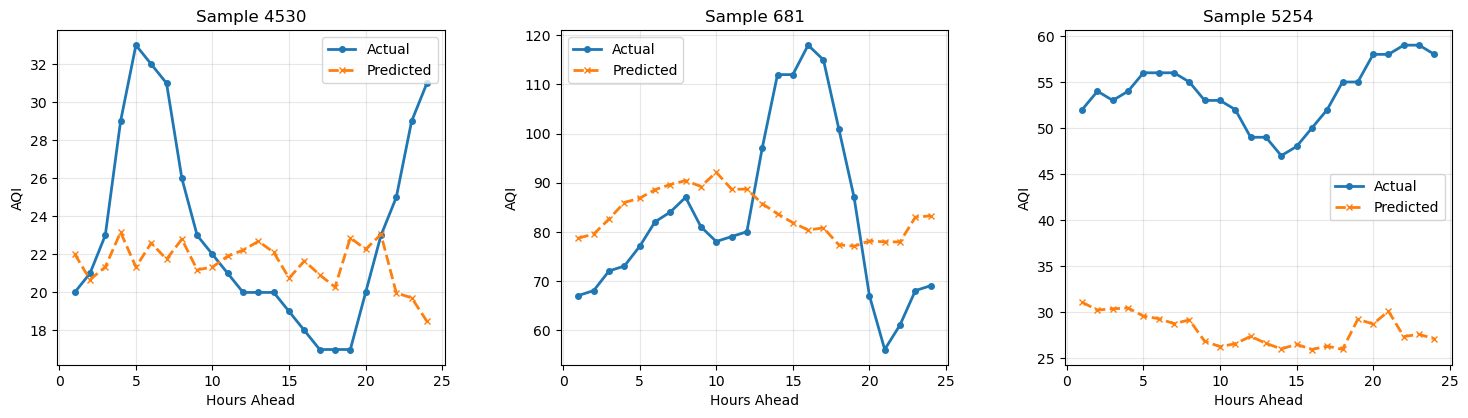


✨ 24小时预测任务完成！


In [31]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# ⭐ 仅修改这两行
# ==========================================
INPUT_WINDOW = 48    # 使用48h历史预测24h（2天预测1天）
OUTPUT_WINDOW = 24   # 预测未来24小时

# 其他超参数
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64
EPOCHS = 150
LEARNING_RATE = 0.0005  # 稍微提高学习率（因为任务更简单）
PATIENCE = 25
WEIGHT_DECAY = 1e-4

D_MODEL = 96
N_HEAD = 6
N_LAYERS = 3
DROPOUT = 0.15

print(f"🖥️  使用设备: {DEVICE}")
print(f"📋 任务配置: 使用{INPUT_WINDOW}小时历史预测未来{OUTPUT_WINDOW}小时")

# ==========================================
# 数据加载（与之前相同）
# ==========================================
print("\n📁 正在加载数据...")
data = pd.read_csv('C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv')
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['sitename', 'date'])

target_site = 'Qianjin'
neighbor_sites = ['Xiaogang', 'Linyuan', 'Zuoying', 'Meinong']

LAG_CONFIG = {
    'Xiaogang': 0,
    'Linyuan': 0,
    'Zuoying': 0,
    'Meinong': 0
}

df_target = data[data['sitename'] == target_site].copy()
df_target = df_target.set_index('date')
df_neighbors = data[data['sitename'].isin(neighbor_sites)].copy()

# ==========================================
# 特征工程（与之前相同）
# ==========================================
print("\n🔧 进行特征工程...")

df_base = df_target.copy()

for neighbor in neighbor_sites:
    df_neighbor = df_neighbors[df_neighbors['sitename'] == neighbor].copy()
    df_neighbor = df_neighbor.set_index('date')
    
    lag = LAG_CONFIG[neighbor]
    if lag > 0:
        df_neighbor = df_neighbor.shift(lag)
    
    neighbor_features = ['PM2.5', 'AQI', 'winddirec', 'windspeed']
    df_neighbor_selected = df_neighbor[neighbor_features].copy()
    df_neighbor_selected.columns = [f'{neighbor}_{col}' for col in neighbor_features]
    df_base = df_base.join(df_neighbor_selected, how='left')

df_base = df_base.ffill().bfill()

# 时间编码
df_base['hour'] = df_base.index.hour
df_base['month'] = df_base.index.month
df_base['dayofweek'] = df_base.index.dayofweek

df_base['hour_sin'] = np.sin(2 * np.pi * df_base['hour'] / 24)
df_base['hour_cos'] = np.cos(2 * np.pi * df_base['hour'] / 24)
df_base['month_sin'] = np.sin(2 * np.pi * df_base['month'] / 12)
df_base['month_cos'] = np.cos(2 * np.pi * df_base['month'] / 12)
df_base['day_sin'] = np.sin(2 * np.pi * df_base['dayofweek'] / 7)
df_base['day_cos'] = np.cos(2 * np.pi * df_base['dayofweek'] / 7)
df_base['is_weekend'] = (df_base['dayofweek'] >= 5).astype(int)

# 风向向量化
df_base['wind_rad'] = np.deg2rad(df_base['winddirec'])
df_base['Wind_X'] = df_base['windspeed'] * np.cos(df_base['wind_rad'])
df_base['Wind_Y'] = df_base['windspeed'] * np.sin(df_base['wind_rad'])

for neighbor in neighbor_sites:
    wind_dir_col = f'{neighbor}_winddirec'
    wind_speed_col = f'{neighbor}_windspeed'
    if wind_dir_col in df_base.columns:
        df_base[f'{neighbor}_wind_rad'] = np.deg2rad(df_base[wind_dir_col])
        df_base[f'{neighbor}_Wind_X'] = df_base[wind_speed_col] * np.cos(df_base[f'{neighbor}_wind_rad'])
        df_base[f'{neighbor}_Wind_Y'] = df_base[wind_speed_col] * np.sin(df_base[f'{neighbor}_wind_rad'])

# 滞后特征
for lag in [1, 3, 6, 12, 24]:
    df_base[f'AQI_lag_{lag}'] = df_base['AQI'].shift(lag)
    df_base[f'PM25_lag_{lag}'] = df_base['PM2.5'].shift(lag)

# 滚动统计
for window in [6, 12, 24]:
    df_base[f'AQI_roll_mean_{window}'] = df_base['AQI'].rolling(window).mean()
    df_base[f'AQI_roll_std_{window}'] = df_base['AQI'].rolling(window).std()

# 邻居聚合特征
neighbor_aqi_cols = [f'{n}_AQI' for n in neighbor_sites]
df_base['neighbor_AQI_mean'] = df_base[neighbor_aqi_cols].mean(axis=1)
df_base['neighbor_AQI_std'] = df_base[neighbor_aqi_cols].std(axis=1)

df_base = df_base.dropna()

# 特征选择
features_to_keep = [
    'PM2.5', 'PM10', 'O3', 'SO2', 'NOx', 'CO', 'AQI',
    'Wind_X', 'Wind_Y',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend',
    'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_6', 'AQI_lag_12', 'AQI_lag_24',
    'PM25_lag_1', 'PM25_lag_3', 'PM25_lag_6', 'PM25_lag_12', 'PM25_lag_24',
    'AQI_roll_mean_6', 'AQI_roll_mean_12', 'AQI_roll_mean_24',
    'AQI_roll_std_6', 'AQI_roll_std_12', 'AQI_roll_std_24',
    'neighbor_AQI_mean', 'neighbor_AQI_std'
]

for neighbor in neighbor_sites:
    features_to_keep.extend([
        f'{neighbor}_PM2.5',
        f'{neighbor}_AQI',
        f'{neighbor}_Wind_X',
        f'{neighbor}_Wind_Y'
    ])

final_cols = [c for c in features_to_keep if c in df_base.columns]
df_processed = df_base[final_cols].copy()

print(f"✅ 特征工程完成，最终特征数: {len(final_cols)}")

# ==========================================
# 序列构建
# ==========================================
def create_multistep_sequences(data_array, target_col_idx, input_len, output_len):
    X, y = [], []
    total_len = len(data_array)
    for i in range(total_len - input_len - output_len + 1):
        X.append(data_array[i : i + input_len])
        y.append(data_array[i + input_len : i + input_len + output_len, target_col_idx])
    return np.array(X), np.array(y)

aqi_col_idx = df_processed.columns.get_loc('AQI')
data_raw = df_processed.values
X_all_raw, y_all_raw = create_multistep_sequences(data_raw, aqi_col_idx, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"\n📊 序列构建完成:")
print(f"   样本数量: {len(X_all_raw)}")
print(f"   输入形状: {X_all_raw.shape}")
print(f"   输出形状: {y_all_raw.shape}")

# 数据集划分
total_samples = len(X_all_raw)
train_size = int(total_samples * 0.7)
val_size = int(total_samples * 0.15)

X_train_raw = X_all_raw[:train_size]
y_train_raw = y_all_raw[:train_size]
X_val_raw = X_all_raw[train_size:train_size + val_size]
y_val_raw = y_all_raw[train_size:train_size + val_size]
X_test_raw = X_all_raw[train_size + val_size:]
y_test_raw = y_all_raw[train_size + val_size:]

print(f"\n📦 数据集划分:")
print(f"   训练集: {X_train_raw.shape} ({len(X_train_raw)/len(X_all_raw)*100:.1f}%)")
print(f"   验证集: {X_val_raw.shape} ({len(X_val_raw)/len(X_all_raw)*100:.1f}%)")
print(f"   测试集: {X_test_raw.shape} ({len(X_test_raw)/len(X_all_raw)*100:.1f}%)")

# 数据标准化
scaler_X = StandardScaler()
scaler_y = StandardScaler()

n_samples_train, n_timesteps, n_features = X_train_raw.shape
scaler_X.fit(X_train_raw.reshape(-1, n_features))

X_train_scaled = scaler_X.transform(X_train_raw.reshape(-1, n_features)).reshape(X_train_raw.shape)
X_val_scaled = scaler_X.transform(X_val_raw.reshape(-1, n_features)).reshape(X_val_raw.shape)
X_test_scaled = scaler_X.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape)

scaler_y.fit(y_train_raw)
y_train_scaled = scaler_y.transform(y_train_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

X_train = torch.FloatTensor(X_train_scaled)
y_train = torch.FloatTensor(y_train_scaled)
X_val = torch.FloatTensor(X_val_scaled)
y_val = torch.FloatTensor(y_val_scaled)
X_test = torch.FloatTensor(X_test_scaled)
y_test = torch.FloatTensor(y_test_scaled)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print("✅ 数据标准化完成\n")

# ==========================================
# ⭐ 优化的24小时预测模型
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]


class AQI24hTransformer(nn.Module):
    """
    优化的24小时预测Transformer
    """
    def __init__(self, input_dim, output_len, d_model=96, nhead=6, 
                 num_layers=3, dropout=0.15):
        super(AQI24hTransformer, self).__init__()
        
        self.input_embedding = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers
        )
        
        # ⭐ 针对24h输出优化的decoder（更简洁）
        hidden_dim = d_model * INPUT_WINDOW
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            
            nn.Linear(256, output_len)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.dim() > 1:
                if 'weight' in name:
                    nn.init.xavier_uniform_(p, gain=0.8)
                elif 'bias' in name:
                    nn.init.constant_(p, 0)
    
    def forward(self, x):
        batch_size = x.size(0)
        x = self.input_embedding(x)
        x = x.permute(1, 0, 2)
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2)
        x = self.transformer_encoder(x)
        x = x.reshape(batch_size, -1)
        output = self.decoder(x)
        return output


# 初始化模型
input_features = X_train.shape[2]
model = AQI24hTransformer(
    input_dim=input_features,
    output_len=OUTPUT_WINDOW,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=20,
    T_mult=2,
    eta_min=1e-6
)

print(f"🤖 模型初始化完成")
print(f"   输入特征数: {input_features}")
print(f"   模型参数量: {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# 训练循环
# ==========================================
print("\n🏋️  开始训练...")
print("=" * 80)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

for epoch in range(EPOCHS):
    # 训练
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 验证
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_24h.pth')
        patience_counter = 0
        improved = "⭐"
    else:
        patience_counter += 1
        improved = ""
    
    if (epoch + 1) % 10 == 0 or epoch < 3:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} {improved} | "
              f"Train: {avg_train_loss:.6f} | "
              f"Val: {avg_val_loss:.6f} | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter:2d}/{PATIENCE}")
    
    if patience_counter >= PATIENCE:
        print(f"\n⚠️  Early Stopping @ Epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_model_24h.pth'))
print(f"\n✅ 训练完成！最佳模型: Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}")

# ==========================================
# 测试集评估
# ==========================================
print("\n🔮 测试集评估...")
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch)
        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

y_pred_scaled = np.concatenate(predictions, axis=0)
y_true_scaled = np.concatenate(actuals, axis=0)

y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_true_real = scaler_y.inverse_transform(y_true_scaled)

# 评价指标
mse = mean_squared_error(y_true_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_real, y_pred_real)
r2 = r2_score(y_true_real.flatten(), y_pred_real.flatten())

# Baseline
baseline_persist_pred = np.tile(X_test_raw[:, -1, aqi_col_idx:aqi_col_idx+1], (1, OUTPUT_WINDOW))
baseline_persist_rmse = np.sqrt(mean_squared_error(y_true_real, baseline_persist_pred))

print("\n" + "=" * 70)
print("📊 ========== 24小时预测最终评价指标 ==========")
print(f"RMSE (均方根误差): {rmse:.4f}")
print(f"MAE  (平均绝对误差): {mae:.4f}")
print(f"R²   (决定系数)    : {r2:.4f}")
print(f"\n📌 Baseline (持续性模型):")
print(f"   Baseline RMSE: {baseline_persist_rmse:.4f}")
print(f"   改进幅度: {(1-rmse/baseline_persist_rmse)*100:+.2f}%")
print("=" * 70)

# 分时段分析
print("\n📈 分时段RMSE分析:")
step_rmse = np.sqrt(np.mean((y_true_real - y_pred_real) ** 2, axis=0))
step_mae = np.mean(np.abs(y_true_real - y_pred_real), axis=0)

print("小时   RMSE    MAE")
print("-" * 30)
for h in [1, 3, 6, 12, 18, 24]:
    print(f"{h:3d}h  {step_rmse[h-1]:6.2f}  {step_mae[h-1]:6.2f}")

# 分时段评估
horizons = {
    '超短期 (1-6h)': (0, 6),
    '短期 (7-12h)': (6, 12),
    '中期 (13-18h)': (12, 18),
    '长期 (19-24h)': (18, 24)
}

print("\n" + "=" * 70)
print("📋 分时段性能详细报告")
print("=" * 70)

for name, (start, end) in horizons.items():
    y_true_horizon = y_true_real[:, start:end]
    y_pred_horizon = y_pred_real[:, start:end]
    
    rmse_horizon = np.sqrt(mean_squared_error(y_true_horizon, y_pred_horizon))
    mae_horizon = mean_absolute_error(y_true_horizon, y_pred_horizon)
    r2_horizon = r2_score(y_true_horizon.flatten(), y_pred_horizon.flatten())
    
    print(f"\n{name}:")
    print(f"   RMSE: {rmse_horizon:.4f}")
    print(f"   MAE : {mae_horizon:.4f}")
    print(f"   R²  : {r2_horizon:.4f}")

# ==========================================
# 可视化
# ==========================================
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 图4-6: 三个样本预测对比
for i in range(3):
    ax = fig.add_subplot(gs[1, i])
    sample_id = np.random.randint(0, len(y_true_real))
    ax.plot(hours, y_true_real[sample_id], label='Actual', marker='o', markersize=4, linewidth=2)
    ax.plot(hours, y_pred_real[sample_id], label='Predicted', marker='x', markersize=4, linestyle='--', linewidth=2)
    ax.set_xlabel('Hours Ahead')
    ax.set_ylabel('AQI')
    ax.set_title(f'Sample {sample_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.savefig('24h_forecast_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✨ 24小时预测任务完成！")

🖥️  使用设备: cuda
📋 任务配置: 使用48小时历史预测未来24小时

📁 正在加载数据...

🔧 进行特征工程...
✅ 特征工程完成，最终特征数: 50

📊 序列构建完成:
   样本数量: 40825
   输入形状: (40825, 48, 50)
   输出形状: (40825, 24)

📦 数据集划分:
   训练集: (28577, 48, 50) (70.0%)
   验证集: (6123, 48, 50) (15.0%)
   测试集: (6125, 48, 50) (15.0%)
✅ 数据标准化完成

🤖 模型初始化完成
   输入特征数: 50
   模型参数量: 5,725,592

🏋️  开始训练...
Epoch   1/150 ⭐ | Train: 0.299648 | Val: 0.195750 | LR: 0.000497 | Patience:  0/25
Epoch   2/150  | Train: 0.203609 | Val: 0.214683 | LR: 0.000488 | Patience:  1/25
Epoch   3/150  | Train: 0.132331 | Val: 0.252074 | LR: 0.000473 | Patience:  2/25
Epoch  10/150  | Train: 0.038295 | Val: 0.239119 | LR: 0.000251 | Patience:  9/25
Epoch  20/150  | Train: 0.024102 | Val: 0.236672 | LR: 0.000500 | Patience: 19/25

⚠️  Early Stopping @ Epoch 26

✅ 训练完成！最佳模型: Epoch 1, Val Loss: 0.195750

🔮 测试集评估...

📊 ========== 24小时预测最终评价指标 ==========
RMSE (均方根误差): 16.7157
MAE  (平均绝对误差): 12.3513
R²   (决定系数)    : 0.7382

📌 Baseline (持续性模型):
   Baseline RMSE: 17.9037
   改进幅度: +6.64%

📈 分时段

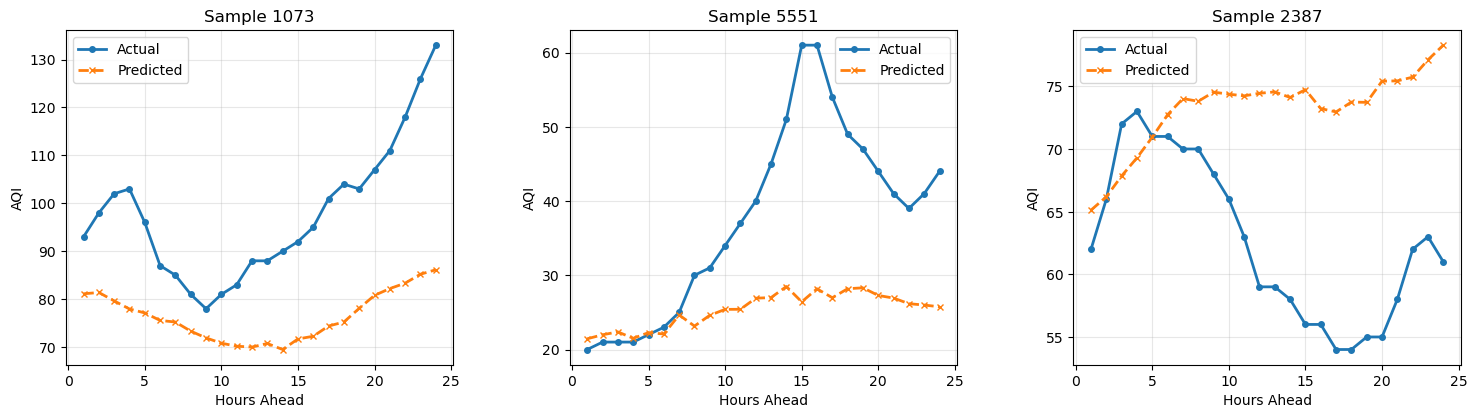


✨ 24小时预测任务完成！


In [32]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# ⭐ 仅修改这两行
# ==========================================
INPUT_WINDOW = 48    # 使用48h历史预测24h（2天预测1天）
OUTPUT_WINDOW = 24   # 预测未来24小时

# 其他超参数
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64
EPOCHS = 150
LEARNING_RATE = 0.0005  # 稍微提高学习率（因为任务更简单）
PATIENCE = 25
WEIGHT_DECAY = 1e-4

D_MODEL = 96
N_HEAD = 6
N_LAYERS = 3
DROPOUT = 0.15

print(f"🖥️  使用设备: {DEVICE}")
print(f"📋 任务配置: 使用{INPUT_WINDOW}小时历史预测未来{OUTPUT_WINDOW}小时")

# ==========================================
# 数据加载（与之前相同）
# ==========================================
print("\n📁 正在加载数据...")
data = pd.read_csv('C:/Users/32052/Desktop/小组/kaohsiung_5sites_final.csv')
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values(['sitename', 'date'])

target_site = 'Zuoying'
neighbor_sites = ['Xiaogang', 'Linyuan', 'Qianjin', 'Meinong']

LAG_CONFIG = {
    'Xiaogang': 0,
    'Linyuan': 0,
    'Qianjin': 0,
    'Meinong': 0
}

df_target = data[data['sitename'] == target_site].copy()
df_target = df_target.set_index('date')
df_neighbors = data[data['sitename'].isin(neighbor_sites)].copy()

# ==========================================
# 特征工程（与之前相同）
# ==========================================
print("\n🔧 进行特征工程...")

df_base = df_target.copy()

for neighbor in neighbor_sites:
    df_neighbor = df_neighbors[df_neighbors['sitename'] == neighbor].copy()
    df_neighbor = df_neighbor.set_index('date')
    
    lag = LAG_CONFIG[neighbor]
    if lag > 0:
        df_neighbor = df_neighbor.shift(lag)
    
    neighbor_features = ['PM2.5', 'AQI', 'winddirec', 'windspeed']
    df_neighbor_selected = df_neighbor[neighbor_features].copy()
    df_neighbor_selected.columns = [f'{neighbor}_{col}' for col in neighbor_features]
    df_base = df_base.join(df_neighbor_selected, how='left')

df_base = df_base.ffill().bfill()

# 时间编码
df_base['hour'] = df_base.index.hour
df_base['month'] = df_base.index.month
df_base['dayofweek'] = df_base.index.dayofweek

df_base['hour_sin'] = np.sin(2 * np.pi * df_base['hour'] / 24)
df_base['hour_cos'] = np.cos(2 * np.pi * df_base['hour'] / 24)
df_base['month_sin'] = np.sin(2 * np.pi * df_base['month'] / 12)
df_base['month_cos'] = np.cos(2 * np.pi * df_base['month'] / 12)
df_base['day_sin'] = np.sin(2 * np.pi * df_base['dayofweek'] / 7)
df_base['day_cos'] = np.cos(2 * np.pi * df_base['dayofweek'] / 7)
df_base['is_weekend'] = (df_base['dayofweek'] >= 5).astype(int)

# 风向向量化
df_base['wind_rad'] = np.deg2rad(df_base['winddirec'])
df_base['Wind_X'] = df_base['windspeed'] * np.cos(df_base['wind_rad'])
df_base['Wind_Y'] = df_base['windspeed'] * np.sin(df_base['wind_rad'])

for neighbor in neighbor_sites:
    wind_dir_col = f'{neighbor}_winddirec'
    wind_speed_col = f'{neighbor}_windspeed'
    if wind_dir_col in df_base.columns:
        df_base[f'{neighbor}_wind_rad'] = np.deg2rad(df_base[wind_dir_col])
        df_base[f'{neighbor}_Wind_X'] = df_base[wind_speed_col] * np.cos(df_base[f'{neighbor}_wind_rad'])
        df_base[f'{neighbor}_Wind_Y'] = df_base[wind_speed_col] * np.sin(df_base[f'{neighbor}_wind_rad'])

# 滞后特征
for lag in [1, 3, 6, 12, 24]:
    df_base[f'AQI_lag_{lag}'] = df_base['AQI'].shift(lag)
    df_base[f'PM25_lag_{lag}'] = df_base['PM2.5'].shift(lag)

# 滚动统计
for window in [6, 12, 24]:
    df_base[f'AQI_roll_mean_{window}'] = df_base['AQI'].rolling(window).mean()
    df_base[f'AQI_roll_std_{window}'] = df_base['AQI'].rolling(window).std()

# 邻居聚合特征
neighbor_aqi_cols = [f'{n}_AQI' for n in neighbor_sites]
df_base['neighbor_AQI_mean'] = df_base[neighbor_aqi_cols].mean(axis=1)
df_base['neighbor_AQI_std'] = df_base[neighbor_aqi_cols].std(axis=1)

df_base = df_base.dropna()

# 特征选择
features_to_keep = [
    'PM2.5', 'PM10', 'O3', 'SO2', 'NOx', 'CO', 'AQI',
    'Wind_X', 'Wind_Y',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'is_weekend',
    'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_6', 'AQI_lag_12', 'AQI_lag_24',
    'PM25_lag_1', 'PM25_lag_3', 'PM25_lag_6', 'PM25_lag_12', 'PM25_lag_24',
    'AQI_roll_mean_6', 'AQI_roll_mean_12', 'AQI_roll_mean_24',
    'AQI_roll_std_6', 'AQI_roll_std_12', 'AQI_roll_std_24',
    'neighbor_AQI_mean', 'neighbor_AQI_std'
]

for neighbor in neighbor_sites:
    features_to_keep.extend([
        f'{neighbor}_PM2.5',
        f'{neighbor}_AQI',
        f'{neighbor}_Wind_X',
        f'{neighbor}_Wind_Y'
    ])

final_cols = [c for c in features_to_keep if c in df_base.columns]
df_processed = df_base[final_cols].copy()

print(f"✅ 特征工程完成，最终特征数: {len(final_cols)}")

# ==========================================
# 序列构建
# ==========================================
def create_multistep_sequences(data_array, target_col_idx, input_len, output_len):
    X, y = [], []
    total_len = len(data_array)
    for i in range(total_len - input_len - output_len + 1):
        X.append(data_array[i : i + input_len])
        y.append(data_array[i + input_len : i + input_len + output_len, target_col_idx])
    return np.array(X), np.array(y)

aqi_col_idx = df_processed.columns.get_loc('AQI')
data_raw = df_processed.values
X_all_raw, y_all_raw = create_multistep_sequences(data_raw, aqi_col_idx, INPUT_WINDOW, OUTPUT_WINDOW)

print(f"\n📊 序列构建完成:")
print(f"   样本数量: {len(X_all_raw)}")
print(f"   输入形状: {X_all_raw.shape}")
print(f"   输出形状: {y_all_raw.shape}")

# 数据集划分
total_samples = len(X_all_raw)
train_size = int(total_samples * 0.7)
val_size = int(total_samples * 0.15)

X_train_raw = X_all_raw[:train_size]
y_train_raw = y_all_raw[:train_size]
X_val_raw = X_all_raw[train_size:train_size + val_size]
y_val_raw = y_all_raw[train_size:train_size + val_size]
X_test_raw = X_all_raw[train_size + val_size:]
y_test_raw = y_all_raw[train_size + val_size:]

print(f"\n📦 数据集划分:")
print(f"   训练集: {X_train_raw.shape} ({len(X_train_raw)/len(X_all_raw)*100:.1f}%)")
print(f"   验证集: {X_val_raw.shape} ({len(X_val_raw)/len(X_all_raw)*100:.1f}%)")
print(f"   测试集: {X_test_raw.shape} ({len(X_test_raw)/len(X_all_raw)*100:.1f}%)")

# 数据标准化
scaler_X = StandardScaler()
scaler_y = StandardScaler()

n_samples_train, n_timesteps, n_features = X_train_raw.shape
scaler_X.fit(X_train_raw.reshape(-1, n_features))

X_train_scaled = scaler_X.transform(X_train_raw.reshape(-1, n_features)).reshape(X_train_raw.shape)
X_val_scaled = scaler_X.transform(X_val_raw.reshape(-1, n_features)).reshape(X_val_raw.shape)
X_test_scaled = scaler_X.transform(X_test_raw.reshape(-1, n_features)).reshape(X_test_raw.shape)

scaler_y.fit(y_train_raw)
y_train_scaled = scaler_y.transform(y_train_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

X_train = torch.FloatTensor(X_train_scaled)
y_train = torch.FloatTensor(y_train_scaled)
X_val = torch.FloatTensor(X_val_scaled)
y_val = torch.FloatTensor(y_val_scaled)
X_test = torch.FloatTensor(X_test_scaled)
y_test = torch.FloatTensor(y_test_scaled)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print("✅ 数据标准化完成\n")

# ==========================================
# ⭐ 优化的24小时预测模型
# ==========================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]


class AQI24hTransformer(nn.Module):
    """
    优化的24小时预测Transformer
    """
    def __init__(self, input_dim, output_len, d_model=96, nhead=6, 
                 num_layers=3, dropout=0.15):
        super(AQI24hTransformer, self).__init__()
        
        self.input_embedding = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers
        )
        
        # ⭐ 针对24h输出优化的decoder（更简洁）
        hidden_dim = d_model * INPUT_WINDOW
        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            
            nn.Linear(256, output_len)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.dim() > 1:
                if 'weight' in name:
                    nn.init.xavier_uniform_(p, gain=0.8)
                elif 'bias' in name:
                    nn.init.constant_(p, 0)
    
    def forward(self, x):
        batch_size = x.size(0)
        x = self.input_embedding(x)
        x = x.permute(1, 0, 2)
        x = self.pos_encoder(x)
        x = x.permute(1, 0, 2)
        x = self.transformer_encoder(x)
        x = x.reshape(batch_size, -1)
        output = self.decoder(x)
        return output


# 初始化模型
input_features = X_train.shape[2]
model = AQI24hTransformer(
    input_dim=input_features,
    output_len=OUTPUT_WINDOW,
    d_model=D_MODEL,
    nhead=N_HEAD,
    num_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=20,
    T_mult=2,
    eta_min=1e-6
)

print(f"🤖 模型初始化完成")
print(f"   输入特征数: {input_features}")
print(f"   模型参数量: {sum(p.numel() for p in model.parameters()):,}")

# ==========================================
# 训练循环
# ==========================================
print("\n🏋️  开始训练...")
print("=" * 80)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

for epoch in range(EPOCHS):
    # 训练
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 验证
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model_24h.pth')
        patience_counter = 0
        improved = "⭐"
    else:
        patience_counter += 1
        improved = ""
    
    if (epoch + 1) % 10 == 0 or epoch < 3:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} {improved} | "
              f"Train: {avg_train_loss:.6f} | "
              f"Val: {avg_val_loss:.6f} | "
              f"LR: {current_lr:.6f} | "
              f"Patience: {patience_counter:2d}/{PATIENCE}")
    
    if patience_counter >= PATIENCE:
        print(f"\n⚠️  Early Stopping @ Epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_model_24h.pth'))
print(f"\n✅ 训练完成！最佳模型: Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}")

# ==========================================
# 测试集评估
# ==========================================
print("\n🔮 测试集评估...")
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        pred = model(X_batch)
        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

y_pred_scaled = np.concatenate(predictions, axis=0)
y_true_scaled = np.concatenate(actuals, axis=0)

y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_true_real = scaler_y.inverse_transform(y_true_scaled)

# 评价指标
mse = mean_squared_error(y_true_real, y_pred_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_real, y_pred_real)
r2 = r2_score(y_true_real.flatten(), y_pred_real.flatten())

# Baseline
baseline_persist_pred = np.tile(X_test_raw[:, -1, aqi_col_idx:aqi_col_idx+1], (1, OUTPUT_WINDOW))
baseline_persist_rmse = np.sqrt(mean_squared_error(y_true_real, baseline_persist_pred))

print("\n" + "=" * 70)
print("📊 ========== 24小时预测最终评价指标 ==========")
print(f"RMSE (均方根误差): {rmse:.4f}")
print(f"MAE  (平均绝对误差): {mae:.4f}")
print(f"R²   (决定系数)    : {r2:.4f}")
print(f"\n📌 Baseline (持续性模型):")
print(f"   Baseline RMSE: {baseline_persist_rmse:.4f}")
print(f"   改进幅度: {(1-rmse/baseline_persist_rmse)*100:+.2f}%")
print("=" * 70)

# 分时段分析
print("\n📈 分时段RMSE分析:")
step_rmse = np.sqrt(np.mean((y_true_real - y_pred_real) ** 2, axis=0))
step_mae = np.mean(np.abs(y_true_real - y_pred_real), axis=0)

print("小时   RMSE    MAE")
print("-" * 30)
for h in [1, 3, 6, 12, 18, 24]:
    print(f"{h:3d}h  {step_rmse[h-1]:6.2f}  {step_mae[h-1]:6.2f}")

# 分时段评估
horizons = {
    '超短期 (1-6h)': (0, 6),
    '短期 (7-12h)': (6, 12),
    '中期 (13-18h)': (12, 18),
    '长期 (19-24h)': (18, 24)
}

print("\n" + "=" * 70)
print("📋 分时段性能详细报告")
print("=" * 70)

for name, (start, end) in horizons.items():
    y_true_horizon = y_true_real[:, start:end]
    y_pred_horizon = y_pred_real[:, start:end]
    
    rmse_horizon = np.sqrt(mean_squared_error(y_true_horizon, y_pred_horizon))
    mae_horizon = mean_absolute_error(y_true_horizon, y_pred_horizon)
    r2_horizon = r2_score(y_true_horizon.flatten(), y_pred_horizon.flatten())
    
    print(f"\n{name}:")
    print(f"   RMSE: {rmse_horizon:.4f}")
    print(f"   MAE : {mae_horizon:.4f}")
    print(f"   R²  : {r2_horizon:.4f}")

# ==========================================
# 可视化
# ==========================================
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 图4-6: 三个样本预测对比
for i in range(3):
    ax = fig.add_subplot(gs[1, i])
    sample_id = np.random.randint(0, len(y_true_real))
    ax.plot(hours, y_true_real[sample_id], label='Actual', marker='o', markersize=4, linewidth=2)
    ax.plot(hours, y_pred_real[sample_id], label='Predicted', marker='x', markersize=4, linestyle='--', linewidth=2)
    ax.set_xlabel('Hours Ahead')
    ax.set_ylabel('AQI')
    ax.set_title(f'Sample {sample_id}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.savefig('24h_forecast_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✨ 24小时预测任务完成！")